In [ ]:
from IPython.core.interactiveshell import InteractiveShell
import time

old_run_cell = InteractiveShell.run_cell

def timing_run_cell(self, raw_cell, *args, **kwargs):
    t0 = time.time()
    result = old_run_cell(self, raw_cell, *args, **kwargs)
    t1 = time.time()
    print(f"Execution time: {t1 - t0:.4f} seconds")
    return result

InteractiveShell.run_cell = timing_run_cell

In [2]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=14"
#os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.chdir('/leonardo/home/userexternal/acosta01/thesis_project_inisideout_model/notebooks')

import jax
print("backend:", jax.default_backend())
print("devices:", jax.devices())

backend: cpu
devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
Execution time: 0.4569 seconds


# Import packages

In [3]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
#import sys
from functools import partial
#import pickle
import itertools
import emcee
import corner
import jax.numpy as jnp
import jax.lax as lax
import jax.scipy as jsp
#import jax.extend
from multiprocessing import Pool
from jax import config
config.update("jax_enable_x64", True)
import pandas as pd
# from decimal import Decimal, getcontext
import scipy.optimize as optimize
from scipy.stats import gaussian_kde
from scipy.optimize import minimize_scalar, minimize
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
# from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.integrate as spint
# from scipy.interpolate import interp1d
# from scipy.integrate import solve_ivp
# from scipy.special import gammainc, gamma
# from scipy.optimize import brentq
# from fractions import Fraction
# import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
# from concurrent.futures import ThreadPoolExecutor
from loky import get_reusable_executor

Execution time: 1.9312 seconds


In [ ]:
print(jax.devices())

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
Execution time: 0.0003 seconds


In [5]:
# ── Data Loading (matching inside-out model approach) ──
BARY = pd.read_csv('../data/baryons1.csv')
TOTAL = pd.read_csv('../data/galaxies_total_sample.csv')
GAS = pd.read_csv('../data/gasses.csv')
STAR = pd.read_csv('../data/stars.csv')

common_names = set(BARY['Name']) & set(GAS['Name']) & set(STAR['Name'])
print(f"BARY: {len(BARY)}, GAS: {len(GAS)}, STAR: {len(STAR)}, common: {len(common_names)}")

b = BARY[BARY['Name'].isin(common_names)][['Name', 'Mass(Msun)', 'e_Mass(Msun)', 'j', 'e_j', 'fgas', 'e_fgas']].copy()
b.columns = ['Name', 'Mbar', 'e_Mbar', 'jbar', 'e_jbar', 'fgas', 'e_fgas']

g = GAS[GAS['Name'].isin(common_names)][['Name', 'Mass', 'e_Mass', 'j', 'e_j']].copy()
g.columns = ['Name', 'Mgas', 'e_Mgas', 'jgas', 'e_jgas']

s = STAR[STAR['Name'].isin(common_names)][['Name', 'Mass', 'e_Mass', 'j', 'e_j']].copy()
s.columns = ['Name', 'Mstar', 'e_Mstar', 'jstar', 'e_jstar']

CONVERGED = b.merge(g, on='Name').merge(s, on='Name')

# Update Mstar and jstar with improved photometry from Pavel+2025 where available
P25 = pd.read_csv('../data/pavel2025_stellar.csv')
p25_in_conv = P25[P25['Name'].isin(CONVERGED['Name'])].set_index('Name')
n_updated = 0
for name, row in p25_in_conv.iterrows():
    mask = CONVERGED['Name'] == name
    CONVERGED.loc[mask, 'Mstar'] = 10**row['logMstar']
    CONVERGED.loc[mask, 'e_Mstar'] = 10**row['logMstar'] * np.log(10) * row['e_logMstar']
    CONVERGED.loc[mask, 'jstar'] = row['jstar']
    CONVERGED.loc[mask, 'e_jstar'] = row['e_jstar']
    n_updated += 1
print(f"Updated stellar properties for {n_updated}/{len(P25)} Pavel+2025 galaxies")


# ── H2 correction (Geesink+2025) and helium correction (×1.4) ──
# gasses.csv contains M_HI only; we now add H2 where available and apply He correction

import re
def _normalize_name(name):
    """NGC0253 -> NGC253, IC 1954 -> IC1954"""
    name = name.strip().replace(' ', '')
    m = re.match(r'^([A-Za-z]+)0*(\d+.*)', name)
    return (m.group(1).upper() + m.group(2)) if m else name.upper()

# Save original HI values (before any correction)
M_HI = CONVERGED['Mgas'].values.astype(float).copy()
e_M_HI = CONVERGED['e_Mgas'].values.astype(float).copy()
j_HI = CONVERGED['jgas'].values.astype(float).copy()
e_j_HI = CONVERGED['e_jgas'].values.astype(float).copy()

# Load Geesink+2025 H2 data and match by normalized name
G25 = pd.read_csv('../data/geesink2025_tableA1.csv')
g25_norm = {_normalize_name(n): i for i, n in enumerate(G25['Name'])}
conv_norm = [_normalize_name(n) for n in CONVERGED['Name']]

M_H2 = np.zeros(len(CONVERGED))
e_M_H2 = np.zeros(len(CONVERGED))
j_H2 = np.zeros(len(CONVERGED))
e_j_H2 = np.zeros(len(CONVERGED))
has_H2 = np.zeros(len(CONVERGED), dtype=bool)

for i, cn in enumerate(conv_norm):
    if cn in g25_norm:
        row = G25.iloc[g25_norm[cn]]
        M_H2[i] = 10**row['log_MH2']
        e_M_H2[i] = M_H2[i] * np.log(10) * row['log_MH2_err']
        j_H2[i] = 10**row['log_jH2']
        e_j_H2[i] = j_H2[i] * np.log(10) * row['log_jH2_err']
        has_H2[i] = True

n_h2 = has_H2.sum()
print(f"Matched {n_h2} galaxies with H2 data from Geesink+2025")

# Gas mass with helium correction:
#   WITH H2:    Mgas = 1.4 * (M_HI + M_H2)
#   WITHOUT H2: Mgas = 1.4 * M_HI  (since M_H2=0)
D = M_HI + M_H2
Mgas_new = 1.4 * D
e_Mgas_new = 1.4 * np.sqrt(e_M_HI**2 + e_M_H2**2)

# Gas angular momentum:
#   WITH H2:    jgas = (M_HI*j_HI + M_H2*j_H2) / (M_HI + M_H2)
#   WITHOUT H2: reduces to j_HI since M_H2=0
jgas_new = (M_HI * j_HI + M_H2 * j_H2) / D

# Error propagation for jgas (mass-weighted average)
# Partial derivatives: d(jgas)/d(M_HI)=(j_HI-jgas)/D, d(jgas)/d(j_HI)=M_HI/D, etc.
e_jgas_new = (1.0 / D) * np.sqrt(
    ((j_HI - jgas_new) * e_M_HI)**2 +
    (M_HI * e_j_HI)**2 +
    ((j_H2 - jgas_new) * e_M_H2)**2 +
    (M_H2 * e_j_H2)**2
)

CONVERGED['Mgas'] = Mgas_new
CONVERGED['e_Mgas'] = e_Mgas_new
CONVERGED['jgas'] = jgas_new
CONVERGED['e_jgas'] = e_jgas_new
print(f"Applied helium correction (x1.4) to all {len(CONVERGED)} galaxies")
print(f"  H2-corrected galaxies: {[CONVERGED.iloc[i]['Name'] for i in range(len(CONVERGED)) if has_H2[i]]}")

# Recompute Mbar, fgas, jbar and their errors for ALL galaxies
Mgas = CONVERGED['Mgas'].values.astype(float)
Mstar = CONVERGED['Mstar'].values.astype(float)
e_Mgas = CONVERGED['e_Mgas'].values.astype(float)
e_Mstar = CONVERGED['e_Mstar'].values.astype(float)
jgas = CONVERGED['jgas'].values.astype(float)
jstar = CONVERGED['jstar'].values.astype(float)
e_jgas = CONVERGED['e_jgas'].values.astype(float)
e_jstar = CONVERGED['e_jstar'].values.astype(float)

Mbar = Mgas + Mstar
e_Mbar = np.sqrt(e_Mgas**2 + e_Mstar**2)

fgas = Mgas / Mbar
# error propagation: fgas = Mgas/(Mgas+Mstar)
e_fgas = np.sqrt((Mstar * e_Mgas)**2 + (Mgas * e_Mstar)**2) / Mbar**2

jbar = (Mgas * jgas + Mstar * jstar) / Mbar
# error propagation for mass-weighted average
e_jbar = (1.0 / Mbar) * np.sqrt(
    (jgas * e_Mgas)**2 + (Mgas * e_jgas)**2 +
    (jstar * e_Mstar)**2 + (Mstar * e_jstar)**2 +
    (jbar * e_Mbar)**2
)

CONVERGED['Mbar'] = Mbar
CONVERGED['e_Mbar'] = e_Mbar
CONVERGED['fgas'] = fgas
CONVERGED['e_fgas'] = e_fgas
CONVERGED['jbar'] = jbar
CONVERGED['e_jbar'] = e_jbar
print("Recomputed Mbar, fgas, jbar and their errors for all (updated) galaxies")

print(f"CONVERGED: {len(CONVERGED)} galaxies")

# ── Create observable arrays from CONVERGED ──
obs_Mbar = np.log10(CONVERGED['Mbar'].values.copy())
obs_Mbar_errors = CONVERGED['e_Mbar'].values.copy()/CONVERGED['Mbar'].values.copy()
obs_Mgas = np.log10(CONVERGED['Mgas'].values.copy())
obs_Mgas_errors = CONVERGED['e_Mgas'].values.copy()/CONVERGED['Mgas'].values.copy()
obs_Mstar = np.log10(CONVERGED['Mstar'].values.copy())
obs_Mstar_errors = CONVERGED['e_Mstar'].values.copy()/CONVERGED['Mstar'].values.copy()
obs_jbar = np.log10(CONVERGED['jbar'].values.copy())
obs_jbar_errors = CONVERGED['e_jbar'].values.copy()/CONVERGED['jbar'].values.copy()
obs_jgas = np.log10(CONVERGED['jgas'].values.copy())
obs_jgas_errors = CONVERGED['e_jgas'].values.copy()/CONVERGED['jgas'].values.copy()
obs_jstar = np.log10(CONVERGED['jstar'].values.copy())
obs_jstar_errors = CONVERGED['e_jstar'].values.copy()/CONVERGED['jstar'].values.copy()
obs_fgas = CONVERGED['fgas'].values.copy()
obs_fgas_errors = CONVERGED['e_fgas'].values.copy()

# ── Load external compilation data ──
pavel_dir = '../data/compilation_AM_others/'

pavel_data = {}
for filename in os.listdir(pavel_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(pavel_dir, filename)
        df = pd.read_csv(filepath)
        df_name = os.path.splitext(filename)[0]
        print(df_name)
        pavel_data[df_name] = df

HIX_data = pavel_data['HIX']

CONVERGED.head()


BARY: 105, GAS: 87, STAR: 130, common: 77
Updated stellar properties for 20/49 Pavel+2025 galaxies
Matched 10 galaxies with H2 data from Geesink+2025
Applied helium correction (x1.4) to all 77 galaxies
  H2-corrected galaxies: ['NGC0253', 'NGC0300', 'NGC1365', 'NGC2903', 'NGC3351', 'NGC3521', 'NGC3627', 'NGC4535', 'NGC4536', 'NGC7793']
Recomputed Mbar, fgas, jbar and their errors for all (updated) galaxies
CONVERGED: 77 galaxies
superspirals
superthin
HIX
Dwarfs


,Name,Mbar,e_Mbar,jbar,e_jbar,fgas,e_fgas,Mgas,e_Mgas,jgas,e_jgas,Mstar,e_Mstar,jstar,e_jstar
0,DDO064,4.178000e+08,2.161041e+08,65.627429,53.786689,0.810914,0.137226,338800000.0,210000000.0,71.3,25.1,7.900000e+07,5.100000e+07,41.30,21.60
1,DDO101,8.914000e+07,9.932060e+07,53.102805,89.845186,0.331389,0.466163,29540000.0,43680000.0,63.6,50.6,5.960000e+07,8.920000e+07,47.90,47.80
2,DDO126,2.281189e+08,4.531276e+07,61.028890,18.774178,0.889887,0.047833,203000000.0,43960000.0,62.5,8.3,2.511886e+07,1.098928e+07,49.14,4.92
3,DDO133,2.942257e+08,1.195139e+08,63.276655,39.366318,0.551957,0.190573,162400000.0,107800000.0,64.8,26.0,1.318257e+08,5.160177e+07,61.40,4.17
4,DDO154,3.824815e+08,5.745740e+07,150.187646,33.296329,0.969981,0.012878,371000000.0,57260000.0,154.0,8.5,1.148154e+07,4.758699e+06,27.00,2.48


Execution time: 0.0499 seconds


In [ ]:
M_times1 = np.arange(0,12.2,0.1)
M_times1_jax = jnp.array(M_times1, dtype=jnp.float64)
log_M_bar_array = np.linspace(8,11.5,50)
dt = 0.1
N = 1.4
A = 0.1625
Rf = 0.45

t_end = float(M_times1[-1])
n_t = M_times1_jax.shape[0]
log_M_bar_array_jax = jnp.array(log_M_bar_array, dtype=jnp.float64)

Execution time: 0.0350 seconds


In [ ]:
def RungeKutta(x, y, dx, dydx):
    # Calculate slopes
    k1 = dx * dydx(x, y)
    k2 = dx * dydx(x + dx / 2., y + k1 / 2.)
    k3 = dx * dydx(x + dx / 2., y + k2 / 2.)
    k4 = dx * dydx(x + dx, y + k3)
    
    # Calculate new x and y
    y_new = y + (1. / 6.) * (k1 + 2 * k2 + 2 * k3 + k4)
    x_new = x + dx
    
    return x_new, y_new

threshold_sigma_SFR = 1.0861925626996982#0.9493446421959616

def Sigma_definer(r, r_acc, t_acc, C):
    """
    Defines the gas surface density 2D array M_sigma(r, t).

    r      : 1D radius array (pc)
    r_acc  : scalar accretion scale length (pc)
    t_acc  : scalar accretion timescale (Gyr)
    C      : normalization constant to reach desired M_bar at t0
    """
    n_r = len(r)
    n_t = len(M_times1)
    M_sigma = np.zeros((n_r, n_t))

    dt_local = M_times1[1] - M_times1[0]
    t_end = M_times1[-1]

    for i, r_value in enumerate(r):
        def dydx(t, S):
            # accretion term - KS consumption term
            acc = (C / (2.0 * np.pi * (r_acc**2))) * np.exp(-t / t_acc) * np.exp(-r_value / r_acc)
            sfr = SFL(S)
            return acc - sfr

        # initial conditions
        t = 0.0
        S = 0.0
        S_row = np.zeros(n_t)
        S_row[0] = S

        # integrate forward in time following M_times1 grid
        for j in range(1, n_t):
            t, S = RungeKutta(t, S, dt_local, dydx)
            S_row[j] = S

        M_sigma[i, :] = S_row

    return M_sigma


def SFL(sigma, sfl_type='kennicutt_modern', Rf = 0.45):
    sigma_arr = np.asarray(sigma, dtype=float)

    # Enforce physical domain: negative gas is set 0
    sigma_pos = np.where(sigma_arr > 0.0, sigma_arr, 0.0)

    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        SFL_val = (1 - Rf) * A * (sigma_pos**N)
    
    elif sfl_type == "elise_steep":
        N = 2.47
        A = 2.13e-5
        SFL_val = (1 - Rf) * A * (sigma_pos**N)

    elif sfl_type == "new_ksl":
        A_ksl = 1.59e-3
        N_ksl = 3.25
        SFL_val = (1 - Rf) * A_ksl * (sigma_pos**N_ksl)
        
    elif sfl_type == "kennicutt_modern":
        A_ksl_mod = 6.68e-2
        N_ksl_mod = 1.54
        return (1.0 - Rf) * A_ksl_mod * (sigma**N_ksl_mod)

    elif sfl_type == "cutoff_ksl":

        with np.errstate(divide='ignore', invalid='ignore'):
            log_sigma = np.where(sigma_pos > 0.0, np.log10(sigma_pos), -np.inf)

        mask = log_sigma < threshold_sigma_SFR

        low_reg  = (1 - Rf) * 1.59e-3 * (sigma_pos**3.25)
        high_reg = (1 - Rf) * 0.1625 * (sigma_pos**1.4)

        SFL_val = np.where(mask, low_reg, high_reg)

    else:
        raise ValueError(f"Unknown sfl_type: {sfl_type}")

    SFL_val = np.where(np.isfinite(SFL_val), SFL_val, 0.0)

    if np.isscalar(sigma):
        return float(SFL_val)
    return SFL_val

def SFL_jax(sigma, sfl_type, R, Mbar, Rf = 0.45):
    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        return (1.0 - Rf) * A * (sigma**N)
    elif sfl_type == "new_ksl":
        A_ksl = 1.59e-3
        N_ksl = 3.25
        return (1.0 - Rf) * A_ksl * (sigma**N_ksl)
    elif sfl_type == "kennicutt_modern":
        A_ksl_mod = 6.68e-2
        N_ksl_mod = 1.54
        return (1.0 - Rf) * A_ksl_mod * (sigma**N_ksl_mod)
    elif sfl_type == "cutoff_ksl":
        # piecewise, same as your cutoff KSL
        log_sigma = jnp.log10(jnp.clip(sigma, a_min=1e-99))  # just to avoid log(0), not a floor on sigma itself
        A1, N1 = 1.59e-3, 3.25
        A2, N2 = 0.1625, 1.4
        cond = log_sigma < threshold_sigma_SFR
        sfl1 = (1.0 - Rf) * A1 * (sigma**N1)
        sfl2 = (1.0 - Rf) * A2 * (sigma**N2)
        return jnp.where(cond, sfl1, sfl2)
    else:
        raise ValueError(f"Unknown sfl_type '{sfl_type}' in SFL_jax")

def v_btfr_def(M_bar, Ag=10**(2.52)):#47
    """Returns the value of the velocity from the baryonic Tully-Fisher relation. The default constant
    value Ag is taken from McGaugh (2012)."""
    return (M_bar/Ag)**(1/3.58)#0.25

def rv_def(M_bar, kpc=True):
    if kpc:
        return 10**3.0651913422858263 * v_btfr_def(M_bar)**(-1.376666240935142)
    else:
        return 10**3.0651913422858263 * v_btfr_def(M_bar)**(-1.376666240935142) * 1000.0
    
def exp_vrot(r, Mbar, kpc=False):
    rv = rv_def(Mbar, kpc=kpc)
    return v_btfr_def(Mbar)*(1-np.exp(-r/rv))

def exp_vrot_jax(r_pc, M_bar):
    rv = rv_def(M_bar, kpc=False)
    return v_btfr_def(M_bar) * (1.0 - jnp.exp(-r_pc / rv))

def analytical_r(x, c, y):
    return x - (c**3 * x) / (c + x)**3 - y
    
def j_maxer(Mbar):
    """Same as your j_maxer, but numpy version for precomputation."""
    return (Mbar**0.73) * 10.0**(-4.25)

def r_btfr_def(M_bar, j_acc, init=1.0):
    """Returns r_acc in kpc (numpy, uses root finding)."""
    rv = rv_def(M_bar, kpc=True)
    yer = j_acc / (2.0 * v_btfr_def(M_bar))
    return optimize.newton(analytical_r, init, args=(rv, yer))

def build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10):
    """
    For each Mbar in log_M_bar_array, build an array of n_j constant r_acc values
    corresponding to j_acc spanning [j_min, j_max].

    Returns: r_acc_grid_pc with shape (n_M, n_j) in pc.
    """
    n_M = len(log_M_bar_array)
    r_acc_grid_pc = np.zeros((n_M, n_j), dtype=float)

    for i, logM in enumerate(log_M_bar_array):
        Mbar = 10.0**logM
        j_max = j_maxer(Mbar)
        j_min = j_max / 10.0
        j_acc_array = np.linspace(j_min, j_max, n_j)

        r_acc_list = []
        for j_acc in j_acc_array:
            r_kpc = r_btfr_def(Mbar, j_acc) # kpc
            r_acc_list.append(1000.0*r_kpc) # pc

        r_acc_grid_pc[i, :] = np.array(r_acc_list, dtype=float)

    return r_acc_grid_pc

def build_r_acc_grid_for_all_M_old_model(log_M_bar_array, n_j=10):
    """
    For each Mbar in log_M_bar_array, build an array of n_j constant r_acc values
    corresponding to j_acc spanning [j_min, j_max].

    Returns: r_acc_grid_pc with shape (n_M, n_j) in pc.
    """
    n_M = len(log_M_bar_array)
    r_acc_grid_pc = np.zeros((n_M, n_j), dtype=float)

    for i, logM in enumerate(log_M_bar_array):
        Mbar = 10.0**logM
        j_max = j_maxer(Mbar)
        j_min = j_max / 10.0
        j_acc_array = np.linspace(j_min, j_max, n_j)

        r_acc_list = []
        for j_acc in j_acc_array:
            r_kpc = r_btfr_def(Mbar, j_acc) # kpc
            r_acc_list.append(1000.0*r_kpc) # pc

        r_acc_grid_pc[i, :] = np.array(r_acc_list, dtype=float)

    return r_acc_grid_pc

Execution time: 0.0081 seconds


In [ ]:
# build once
r_acc_grid_np = build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10)
r_acc_grid_jax = jnp.array(r_acc_grid_np, dtype=jnp.float64)

Execution time: 0.0414 seconds


In [ ]:
def sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc):
    """
    Accretion surface density with constant r_acc (in pc).
    """
    return (C / (2.0 * jnp.pi * r_acc_pc**2.0)) * \
           jnp.exp(-t / t_acc) * jnp.exp(-r_value / r_acc_pc)


def choose_dt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
                        base_dt=0.1, dt_min=1e-3, safety=2.0, Rf=0.45):
    """
    Adaptive dt, same logic as your good model, but with constant r_acc.
    """
    S = jnp.asarray(S)

    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar, Rf=Rf)

    t_sup = jnp.where((S > 0.0) & (Sigma_acc > 0.0), S / Sigma_acc, jnp.inf)
    t_dep = jnp.where((S > 0.0) & (Sigma_sfr > 0.0), S / Sigma_sfr, jnp.inf)

    t_char = jnp.minimum(t_sup, t_dep)
    dt_raw = jnp.minimum(base_dt, t_char / safety)
    dt_raw = jnp.maximum(dt_raw, dt_min)

    dt = jnp.where(S <= 0.0, base_dt, dt_raw)
    return dt


def dydt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=0.45):
    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar, Rf=Rf)
    return Sigma_acc - Sigma_sfr


def RungeKutta_const_jax(t, S, dt, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=0.45):
    k1 = dydt_const_jax(t,            S,             r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=Rf)
    k2 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k1, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=Rf)
    k3 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k2, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=Rf)
    k4 = dydt_const_jax(t + dt,       S + dt*k3,     r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=Rf)

    S_new = S + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)
    t_new = t + dt
    S_new = jnp.maximum(S_new, 0.0)
    return t_new, S_new

@partial(jax.jit, static_argnames=("sfl_type",))
def compute_row_static_racc_jax(r_value, M_bar, C, t_acc, sfl_type, r_acc_pc, Rf=0.45):
    """
    Solve Sigma_gas(t) at one radius r_value for a model with:
      - fixed r_acc (r_acc_pc),
      - given M_bar, C, t_acc,
      - star formation law sfl_type (use "cutoff_ksl").

    Returns: Sigma_gas(t_j) on M_times1_jax grid, shape (n_t,)
    """
    t0 = 0.0
    S0 = 0.0
    row0 = jnp.zeros(n_t, dtype=jnp.float64).at[0].set(S0)
    save_idx0 = 1

    state0 = (t0, S0, save_idx0, row0)

    def cond_fun(state):
        t, S, save_idx, row = state
        return jnp.logical_and(t < t_end, save_idx < n_t)

    def body_fun(state):
        t, S, save_idx, row = state

        dt_loc = choose_dt_const_jax(
            t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
            base_dt=0.1, dt_min=1e-3, safety=2.0, Rf=Rf
        )

        t_new, S_new = RungeKutta_const_jax(
            t, S, dt_loc, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc, Rf=Rf
        )

        carry = (t, S, t_new, S_new, save_idx, row)

        def save_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            t_grid = M_times1_jax[idx]
            denom = jnp.maximum(t_n - t_old, 1e-12)
            theta = (t_grid - t_old) / denom
            S_grid = S_old + theta * (S_n - S_old)
            row_i = row_i.at[idx].set(S_grid)
            return (t_n, S_n, t_n, S_n, idx + 1, row_i)

        def nosave_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            return (t_n, S_n, t_n, S_n, idx, row_i)

        cond_save = jnp.logical_and(
            save_idx < n_t,
            t_new >= M_times1_jax[save_idx]
        )

        t2, S2, _t2, _S2, save_idx2, row2 = lax.cond(
            cond_save, save_branch, nosave_branch, carry
        )
        return (t2, S2, save_idx2, row2)

    t_f, S_f, save_idx_f, row_f = lax.while_loop(cond_fun, body_fun, state0)

    # Fill remainder with last value if we stopped early
    def fill_rest(row):
        last_val = row[save_idx_f - 1]
        idxs = jnp.arange(n_t)
        mask = idxs >= save_idx_f
        return jnp.where(mask, last_val, row)

    row_f = lax.cond(save_idx_f < n_t, fill_rest, lambda x: x, row_f)
    return row_f

@partial(jax.jit, static_argnames=("sfl_type",))
def Sigma_definer_static_racc_jax(r_pc, t_acc, M_bar, C, sfl_type, r_acc_array_pc, Rf=0.45):
    """
    JAX equivalent of Sigma_definer for the 'bad' model:
    - r_acc_array_pc: (n_racc,) constant accretion radii in pc
    Returns:
      SD_gas of shape (n_racc, n_r, n_t)
    """
    r_pc = jnp.asarray(r_pc, dtype=jnp.float64)

    def Sigma_for_one_racc(r_acc_pc):
        def solve_at_radius(r_value):
            return compute_row_static_racc_jax(r_value, M_bar, C, t_acc,
                                               sfl_type, r_acc_pc, Rf=Rf)
        # Sigma_gas(R, t) for this r_acc
        return jax.vmap(solve_at_radius)(r_pc)  # (n_r, n_t)

    SD_gas = jax.vmap(Sigma_for_one_racc)(r_acc_array_pc)  # (n_racc, n_r, n_t)
    return SD_gas

# M_bar-dependent omega functions (for MCMC fitting)

@jax.jit
def omega_Mdep(logM, a, b):
    """
    M_bar-dependent accretion rate omega.

    omega(Mbar) [Gyr^-1] = a * log10(Mbar / 10^10 Msun) + b
                        = a * (logM - 10) + b

    Parameters:
    -----------
    logM : float or array
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]

    Returns:
    --------
    omega : float or array
        Accretion rate [Gyr^-1]
    """
    return a * (logM - 10.0) + b

@jax.jit
def tacc_Mdep(logM, a, b, omega_eps=1e-4):
    """
    M_bar-dependent accretion timescale t_acc = 1/omega.

    Handles omega ~ 0 by clamping to omega_eps.

    Parameters:
    -----------
    logM : float or array
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    omega_eps : float
        Minimum |omega| to avoid division by zero

    Returns:
    --------
    t_acc : float or array
        Accretion timescale [Gyr]
    """
    omega = omega_Mdep(logM, a, b)
    # Clamp omega away from zero
    # omega_safe = jnp.where(jnp.abs(omega) < omega_eps,
    #                        jnp.sign(omega + 1e-30) * omega_eps,
    #                        omega)
    return 1.0 / omega#omega_safe


Execution time: 0.0069 seconds


In [ ]:
def Full_final_definer(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="old_ksl"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    j_max = (Mbar**0.73)*10**(-4.25)
    j_min = j_max/10
    j_acc_array = np.linspace(j_min, j_max, 10)
    
    r_acc_array = np.zeros(len(j_acc_array))
    for i in range(len(j_acc_array)):
        r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas
    
def Full_final_definer_old_model(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="elise_steep"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    # j_max = (Mbar**0.73)*10**(-4.25)
    # j_min = j_max/10
    # j_acc_array = np.linspace(j_min, j_max, 10)
    
    # r_acc_array = np.zeros(len(j_acc_array))
    # for i in range(len(j_acc_array)):
    #     r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    
    r_acc = 10**(0.385*(np.log10(Mbar)-10)+0.281)*1000  # in pc
    r_acc_array = np.linspace(r_acc/2, r_acc*2, 10)
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    v_rot = (M_bar/47)**0.25
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = v_rot*np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas

def process_mbar(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer(10**M, t_acc, *args)

def process_mbar_old_model(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer_old_model(10**M, t_acc, *args)

def simpson_uniform_jax(y, dx, axis=0):
    """
    Simpson integration with uniform spacing dx in JAX.
    Handles both even and odd number of samples like scipy.integrate.simpson:
      - if N points => N-1 intervals
      - if (N-1) is odd (N even): Simpson on first N-1 points, trapezoid for last interval.
    """
    y = jnp.asarray(y)
    # move integration axis to 0 for convenience
    y = jnp.moveaxis(y, axis, 0)

    N = y.shape[0]

    # if N < 2, integral is zero
    if N < 2:
        return jnp.zeros_like(y[0])

    def simpson_all(y_local):
        w = jnp.ones(N)
        w = w.at[1:N-1:2].set(4.0)
        w = w.at[2:N-1:2].set(2.0)
        return dx / 3.0 * jnp.tensordot(w, y_local, axes=(0, 0))

    def simpson_plus_trap(y_local):
        # use Simpson on first N-1 points, trap on last interval
        Nsim = N - 1
        y_s = y_local[:Nsim] # Simpson part
        w = jnp.ones(Nsim)
        w = w.at[1:Nsim-1:2].set(4.0)
        w = w.at[2:Nsim-1:2].set(2.0)
        simp = dx / 3.0 * jnp.tensordot(w, y_s, axes=(0, 0))
        trap = dx * 0.5 * (y_local[-2] + y_local[-1])
        return simp + trap

    result = jax.lax.cond(
        (N % 2 == 1),
        simpson_all,
        simpson_plus_trap,
        y
    )

    return jnp.moveaxis(result, 0, axis)

@partial(jax.jit, static_argnames=("star_formation_law", "at_t0"))
def full_from_sigma_jax(SD_gas, Mbar, r_pc, dt, star_formation_law, at_t0=True):
    """
    SD_gas: (n_tacc, n_r, n_t)  Σ_gas in Msun/pc^2
    r_pc:   (n_r,) radii in pc
    dt:     scalar time step between entries in M_times1 (Gyr)
    Mbar:   scalar baryonic mass (Msun)

    Returns same outputs as your Full_final_definer (with /1000 for j).
    """
    SD_gas = jnp.asarray(SD_gas)
    r_pc = jnp.asarray(r_pc)
    dr = r_pc[1] - r_pc[0]

    n_tacc, n_r, n_t = SD_gas.shape

    r_col = r_pc[:, None]
    r2_col = r_col**2

    # if star_formation_law != "cutoff_ksl":
    #     raise ValueError("full_from_sigma_jax currently implemented only for 'cutoff_ksl'.")

    # broadcast R just to satisfy the signature; it’s ignored for cutoff_ksl
    R_broad = r_col[None, :, :] # (1, n_r, 1) -> broadcasts to SD_gas
    Sigma_sfr = SFL_jax(SD_gas, star_formation_law, R_broad, Mbar)  # (n_tacc, n_r, n_t)

    integrand_gas = r_col[None, :, :]*SD_gas
    integrand_sfr = r_col[None, :, :]*Sigma_sfr

    def integrate_radius(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    M_gas = jax.vmap(integrate_radius)(integrand_gas)  
    M_sfr = jax.vmap(integrate_radius)(integrand_sfr)  

    M_star = dt*jnp.cumsum(M_sfr, axis=-1)           
    M_bar_tot = M_star + M_gas

    f_gas_global = M_gas / M_bar_tot                   

    v_rot = exp_vrot_jax(r_pc, Mbar)[:, None]
    integrand_gas_j = r2_col[None,:,:]*SD_gas*v_rot[None, :, :]
    integrand_sfr_j = r2_col[None,:,:]*Sigma_sfr*v_rot[None, :, :]

    def integrate_radius_j(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    nom_gas  = jax.vmap(integrate_radius_j)(integrand_gas_j)
    nom_sfr  = jax.vmap(integrate_radius_j)(integrand_sfr_j)
    nom_star = dt * jnp.cumsum(nom_sfr, axis=-1)
    nom_bar  = nom_star + nom_gas

    j_bar  = nom_bar / jnp.where(M_bar_tot > 0, M_bar_tot, jnp.inf)
    j_gas  = nom_gas/ jnp.where(M_gas > 0, M_gas, jnp.inf)
    j_star = nom_star / jnp.where(M_star > 0, M_star, jnp.inf)

    if at_t0:
        f_gas_array  = f_gas_global[:, -1]
        j_bar_array  = j_bar[:, -1]/1000.0
        j_gas_array  = j_gas[:, -1]/1000.0
        j_star_array = j_star[:, -1]/1000.0
        M_star_t0    = M_star[:, -1]
        M_gas_t0     = M_gas[:, -1]
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        return (f_gas_global,
                j_bar  / 1000.0,
                j_gas  / 1000.0,
                j_star / 1000.0,
                M_star,
                M_gas)

def C_def_jax(M_bar, t_acc, t0=12.0):
    """
    JAX-friendly version of C_def.
    """
    t_acc = jnp.asarray(t_acc, dtype=jnp.float64)

    pos = t_acc > 0.0
    neg = t_acc < 0.0
    infmask = jnp.isinf(t_acc)

    # positive t_acc
    C_pos = M_bar / (t_acc * (1.0 - jnp.exp(-t0 / t_acc)))

    # negative t_acc
    abs_t = jnp.abs(t_acc)
    C_neg = M_bar / (abs_t * (jnp.exp(t0 / abs_t) - 1.0))

    # infinite t_acc
    C_inf = M_bar / t0

    C = jnp.where(pos, C_pos, C_neg)
    C = jnp.where(infmask, C_inf, C)

    return C

@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def Full_final_definer_bad_jax(Mbar,
                               t_acc,
                               star_formation_law,
                               r_acc_array_for_M_pc,
                               res=120,
                               Rmax=100.1,
                               at_t0=True):
    """
    JAX 'bad' model for a single Mbar and single t_acc:
    - Mbar: scalar Msun
    - t_acc: scalar Gyr
    - r_acc_array_for_M_pc: (n_racc,) in pc (constant in time)
    - star_formation_law: e.g. 'cutoff_ksl'
    Returns:
      f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
      each of shape (n_racc,)
    """
    # radius grid in pc
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)

    # normalization for this t_acc
    C_val = C_def_jax(Mbar, t_acc)  # scalar

    # Σ_gas(r, t) for each r_acc
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc,
        t_acc,
        Mbar,
        C_val,
        star_formation_law,
        r_acc_array_for_M_pc
    )  # (n_racc, n_r, n_t)

    # post-process: full_from_sigma_jax expects (n_batch, n_r, n_t)
    return full_from_sigma_jax(
        SD_gas,
        Mbar,
        r_pc,
        dt,
        star_formation_law,
        at_t0=at_t0,
    )
    
@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def run_all_masses_bad_jax(Mbar_grid,
                           t_acc_array,
                           r_acc_grid_pc,
                           star_formation_law="cutoff_ksl",
                           res=120,
                           Rmax=100.1,
                           at_t0=True):
    """
    JAX driver for the 'bad' model:
      Mbar_grid : (n_M,)
      t_acc_array : (n_tacc,)
      r_acc_grid_pc : (n_M, n_racc)
    Returns:
      f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all
      each of shape (n_M, n_tacc, n_racc)
    """

    def per_mass(Mbar, r_acc_row):
        # for this mass, vmap over t_acc
        def per_tacc(t_acc):
            return Full_final_definer_bad_jax(
                Mbar,
                t_acc,
                star_formation_law,
                r_acc_row,
                res=res,
                Rmax=Rmax,
                at_t0=at_t0,
            )
        # each is (n_racc,)
        f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt = \
            jax.vmap(per_tacc)(t_acc_array)  # (n_tacc, n_racc)
        return f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt

    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all = \
        jax.vmap(per_mass)(Mbar_grid, r_acc_grid_pc)
    # shapes: (n_M, n_tacc, n_racc)

    return f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all

def modelled_j_bar2(f_gas_array, j_bar_array, f_gas_value, kind=1):
    """
    The function takes as input the arrays for f_gas and j_bar (possibly already interpolated), 
    together with a wanted value of f_gas for which to slice out the 1D array. 
    
    ------------
    Inputs:
    - f_gas_array = interpolated 2D array of f_gas
    - j_bar_array = interpolated 2D array of j_bar
    - f_gas_value = value of f_gas for which to slice the f_gas/j_bar arrays
    - kind = Inerpolation type (default is 1 - linear)
    
    The function does the following
    - Creates a list 'index_array', which has the indexes of constant f_gas_value chosen as elements.
    - Then, it iteratively takes from the j_bar_array the values corresponding to the indexes from index_array
    - Finally it interpolates the indexed j_bar_array through the M_bar_array, to get a plottable linear function.
    
    Returns:
    - indexed_M_array_lin = A simple linspace with the initial and final values of the original log_M_bar_array
    """
    indexed_j_array = []
    index_array = []
    true_list = []
    
    for i in range(len(log_M_bar_array)):
        if f_gas_value>np.min(f_gas_array[i]) and f_gas_value<np.max(f_gas_array[i]):
            index_array.append(np.argwhere(f_gas_array[i] == min(f_gas_array[i], key=lambda x:abs(x-f_gas_value))))
            true_list.append(1)
        else:
            index_array.append(0)
            true_list.append(0)
    
    j = 0
    while (j<len(log_M_bar_array)):
        if (true_list[j]==1):
            indexed_j_array.append(j_bar_array[j][index_array[j]])
        j += 1
    
    if len(indexed_j_array)>kind:
        index = np.argwhere(np.array(true_list) == 1)
        indexed_M_array = log_M_bar_array[index]
        indexed_M_array_lin = np.linspace(indexed_M_array[0], indexed_M_array[-1], 1000)
        interpolation = spl.InterpolatedUnivariateSpline(indexed_M_array.reshape(len(indexed_M_array),), indexed_j_array, k=kind)
        interpolated_j_array = interpolation(indexed_M_array_lin).reshape(len(indexed_M_array_lin),)
    else:
        indexed_M_array_lin = []
        interpolated_j_array = []
    
    return indexed_M_array_lin, interpolated_j_array

Execution time: 0.0174 seconds


In [ ]:
# Model with M_bar-dependent omega (non-inside-out growth)

@partial(jax.jit, static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def Full_final_definer_Mdep_omega_jax(logM, a, b, 
                                       r_acc_array_pc,
                                       star_formation_law,
                                       res=120, Rmax=100.1, at_t0=True):
    """
    JAX model for a single galaxy with M_bar-dependent omega.
    
    This is a non-inside-out growth model where:
    - omega(Mbar) = a * (logM - 10) + b  [Gyr^-1]
    - t_acc = 1/omega
    - r_acc is constant in time (derived from j_acc)
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun) for this galaxy
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    r_acc_array_pc : array (n_j,)
        Array of accretion radii in pc (from j_acc grid)
    star_formation_law : str
        Star formation law to use (default "cutoff_ksl")
    res : float
        Radial resolution in pc
    Rmax : float
        Maximum radius in kpc
    at_t0 : bool
        If True, return values at t=12 Gyr only
        
    Returns:
    --------
    f_gas_array : array (n_j,)
        Gas fractions for each j_acc
    j_bar_array : array (n_j,)
        Baryonic specific angular momentum [kpc km/s]
    j_gas_array : array (n_j,)
        Gas specific angular momentum [kpc km/s]
    j_star_array : array (n_j,)
        Stellar specific angular momentum [kpc km/s]
    M_star_t0 : array (n_j,)
        Stellar mass at t0
    M_gas_t0 : array (n_j,)
        Gas mass at t0
    """
    # Compute t_acc from M_bar-dependent omega
    t_acc = tacc_Mdep(logM, a, b)
    Mbar = 10.0**logM
    
    # Radius grid in pc
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)
    
    # Normalization constant
    C_val = C_def_jax(Mbar, t_acc)
    
    # Compute Sigma_gas(r, t) for each r_acc
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc, t_acc, Mbar, C_val, star_formation_law, r_acc_array_pc
    )  # (n_j, n_r, n_t)
    
    # Post-process to get f_gas, j_bar, etc.
    return full_from_sigma_jax(
        SD_gas, Mbar, r_pc, dt, star_formation_law, at_t0=at_t0
    )


def build_r_acc_for_single_M(logM, n_j=10):
    """
    Build r_acc array for a single galaxy mass.
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun)
    n_j : int
        Number of j_acc values to sample
        
    Returns:
    --------
    r_acc_pc : array (n_j,)
        Accretion radii in pc
    j_acc_array : array (n_j,)
        Corresponding j_acc values [kpc km/s]
    """
    Mbar = 10.0**logM
    j_max = j_maxer(Mbar)
    j_min = j_max / 10.0
    j_acc_array = np.linspace(j_min, j_max, n_j)
    
    r_acc_pc = np.zeros(n_j)
    for i, j_acc in enumerate(j_acc_array):
        r_kpc = r_btfr_def(Mbar, j_acc)
        r_acc_pc[i] = 1000.0 * r_kpc
    
    return r_acc_pc, j_acc_array


def run_single_galaxy_Mdep_omega_jax(logM, a, b, sfl_type, n_j=10):
    """
    Run model for a single galaxy with M_bar-dependent omega.
    
    This is a convenience wrapper that builds r_acc and runs the model.
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    n_j : int
        Number of j_acc values to sample
    star_formation_law : str
        Star formation law to use
        
    Returns:
    --------
    f_gas : array (n_j,)
        Gas fractions
    j_bar : array (n_j,)
        Baryonic specific angular momentum [kpc km/s]
    j_acc_array : array (n_j,)
        j_acc values used [kpc km/s]
    """
    # Build r_acc grid for this mass
    r_acc_pc, j_acc_array = build_r_acc_for_single_M(logM, n_j)
    r_acc_jax = jnp.array(r_acc_pc, dtype=jnp.float64)
    
    # Run model
    f_gas, j_bar, j_gas, j_star, Ms, Mg = Full_final_definer_Mdep_omega_jax(
        logM, a, b, r_acc_jax, star_formation_law=sfl_type
    )
    
    return np.array(f_gas), np.array(j_bar), j_acc_array


@partial(jax.jit, static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def run_all_masses_Mdep_omega_jax(log_M_array, a, b, r_acc_grid_pc,
                                   star_formation_law="cutoff_ksl",
                                   res=120, Rmax=100.1, at_t0=True):
    """
    Run model for multiple masses with M_bar-dependent omega.
    
    Parameters:
    -----------
    log_M_array : array (n_M,)
        log10(Mbar / Msun) for each galaxy
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    r_acc_grid_pc : array (n_M, n_j)
        Pre-computed r_acc values for each mass
    star_formation_law : str
        Star formation law to use
        
    Returns:
    --------
    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all
        Each of shape (n_M, n_j)
    """
    def per_mass(logM, r_acc_row):
        return Full_final_definer_Mdep_omega_jax(
            logM, a, b, r_acc_row,
            star_formation_law=star_formation_law,
            res=res, Rmax=Rmax, at_t0=at_t0
        )
    
    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all = \
        jax.vmap(per_mass)(log_M_array, r_acc_grid_pc)
    
    return f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all


def run_single_galaxy_from_jbar(logM, j_bar_obs, a, b,
                                 sfl_type):
    """
    Run model for a single galaxy using observed j_bar to determine j_acc.
    
    In the non-inside-out model with constant j_acc, the analytical result is:
        j_bar = j_acc
    
    So we set j_acc = j_bar_obs, run the model once, and return all observables.
    
    Parameters:
    -----------
    logM : float
        log10(Mbar / Msun)
    j_bar_obs : float
        Observed j_bar [kpc km/s] (used as j_acc)
    a : float
        Slope of omega vs logM [Gyr^-1 per dex]
    b : float
        omega at Mbar = 10^10 Msun [Gyr^-1]
    sfl_type : str
        Star formation law to use
        
    Returns:
    --------
    f_gas_model, j_bar_model, j_gas_model, j_star_model, M_star_model, M_gas_model : float
        Model observables at t=12 Gyr
    """
    Mbar = 10.0**logM
    
    # Set j_acc = j_bar_obs (from analytical derivation)
    j_acc = j_bar_obs
    
    # Convert j_acc to r_acc
    try:
        r_acc_kpc = r_btfr_def(Mbar, j_acc)
        r_acc_pc = 1000.0 * r_acc_kpc
    except:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    
    # Run model with single r_acc (need array for JAX function)
    r_acc_array = jnp.array([r_acc_pc], dtype=jnp.float64)
    
    f_gas, j_bar, j_gas, j_star, M_star, M_gas = Full_final_definer_Mdep_omega_jax(
        logM, a, b, r_acc_array, star_formation_law=sfl_type
    )
    
    # Extract scalar values
    f_gas_model = float(np.array(f_gas)[0])
    j_bar_model = float(np.array(j_bar)[0])
    j_gas_model = float(np.array(j_gas)[0])
    j_star_model = float(np.array(j_star)[0])
    M_star_model = float(np.array(M_star)[0])
    M_gas_model = float(np.array(M_gas)[0])
    
    return f_gas_model, j_bar_model, j_gas_model, j_star_model, M_star_model, M_gas_model


Execution time: 0.0049 seconds


In [ ]:
# MCMC for M_bar-dependent omega model (4-OBSERVABLE VERSION)
# 
# Uses analytical j_bar = j_acc relation:
# 1. For each observed galaxy (logM, j_bar_obs):
#    - Set j_acc = j_bar_obs (from analytical derivation)
#    - Run model ONCE to get (M_gas, M_star, j_gas, j_star)_model
#    - Compare to observed (M_gas, M_star, j_gas, j_star) using Gaussian likelihood

def logL_4obs_single_galaxy(logM_obs, j_bar_obs,
                             Mgas_obs, sigma_Mgas,
                             Mstar_obs, sigma_Mstar,
                             jgas_obs, sigma_jgas,
                             jstar_obs, sigma_jstar,
                             a, b, sfl_type):
    """
    Log-likelihood for a single galaxy using 4 direct observables:
    M_gas, M_star, j_gas, j_star.
    """
    # Run model with j_acc = j_bar_obs
    f_gas_model, j_bar_model, j_gas_model, j_star_model, M_star_model, M_gas_model = run_single_galaxy_from_jbar(logM_obs, j_bar_obs, a, b, sfl_type=sfl_type)
    
    if np.isnan(f_gas_model) or not np.isfinite(f_gas_model):
        return -1e6
    if f_gas_model <= 0 or f_gas_model >= 1:
        return -1e6
    
    # Chi-squared on 4 observables
    chi2  = ((M_gas_model  - Mgas_obs)  / max(sigma_Mgas,  1e-6))**2
    chi2 += ((M_star_model - Mstar_obs) / max(sigma_Mstar, 1e-6))**2
    chi2 += ((j_gas_model - jgas_obs)  / max(sigma_jgas,  1e-6))**2
    chi2 += ((j_star_model - jstar_obs) / max(sigma_jstar, 1e-6))**2
    
    return -0.5 * chi2


def logL_4obs_all_galaxies(a, b, logM_obs_array, j_bar_obs_array,
                            Mgas_obs_array, sigma_Mgas_array,
                            Mstar_obs_array, sigma_Mstar_array,
                            jgas_obs_array, sigma_jgas_array,
                            jstar_obs_array, sigma_jstar_array,
                            sfl_type):
    """
    Total log-likelihood for all galaxies using 4 direct observables.
    """
    logL_total = 0.0
    n_gal = len(logM_obs_array)
    
    for i in range(n_gal):
        logL_i = logL_4obs_single_galaxy(
            logM_obs_array[i], j_bar_obs_array[i],
            Mgas_obs_array[i],  sigma_Mgas_array[i],
            Mstar_obs_array[i], sigma_Mstar_array[i],
            jgas_obs_array[i],  sigma_jgas_array[i],
            jstar_obs_array[i], sigma_jstar_array[i],
            a, b, sfl_type=sfl_type
        )
        logL_total += logL_i
    
    return logL_total


# =============================================================================
# Prior and posterior for MCMC
# =============================================================================

def log_prior_Mdep_omega(theta, a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0):
    """Flat (uniform) prior on a and b."""
    a, b = theta
    if a_min < a < a_max and b_min < b < b_max:
        return 0.0
    return -np.inf


def log_posterior_Mdep_omega(theta, logM_obs_array, j_bar_obs_array,
                              Mgas_obs_array, sigma_Mgas_array,
                              Mstar_obs_array, sigma_Mstar_array,
                              jgas_obs_array, sigma_jgas_array,
                              jstar_obs_array, sigma_jstar_array,
                              sfl_type,
                              a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0):
    """Log-posterior = log-prior + log-likelihood (4-observable version)."""
    lp = log_prior_Mdep_omega(theta, a_min, a_max, b_min, b_max)
    if not np.isfinite(lp):
        return -np.inf
    
    a, b = theta
    ll = logL_4obs_all_galaxies(
        a, b, logM_obs_array, j_bar_obs_array,
        Mgas_obs_array, sigma_Mgas_array,
        Mstar_obs_array, sigma_Mstar_array,
        jgas_obs_array, sigma_jgas_array,
        jstar_obs_array, sigma_jstar_array,
        sfl_type=sfl_type
    )
    
    return lp + ll

def init_worker():
    """Initialize JAX configuration in each worker process."""
    os.environ['JAX_ENABLE_X64'] = '1'
    jax.config.update("jax_enable_x64", True)

def run_mcmc_Mdep_omega(logM_obs_array, j_bar_obs_array,
                         Mgas_obs_array, sigma_Mgas_array,
                         Mstar_obs_array, sigma_Mstar_array,
                         jgas_obs_array, sigma_jgas_array,
                         jstar_obs_array, sigma_jstar_array,
                         sfl_type, n_walkers=4, n_steps=200,
                         a_init=1.5, b_init=1.5,
                         a_min=-1.5, a_max=2.5, b_min=-1.5, b_max=3.0,
                         filename='../outputs/mcmc_chains/chain_mcmc_noninsideout.h5',
                         fresh_start=True,
                         nsteps_is_total=False,
                         max_workers=12,
                         progress=True):
    """
    Run MCMC to fit the M_bar-dependent omega model (4-observable version).
    
    Supports saving to HDF5 file and resuming from previous runs.
    """
    n_dim = 2
    
    # Set up HDF5 backend
    backend = emcee.backends.HDFBackend(filename)
    
    if fresh_start:
        backend.reset(n_walkers, n_dim)
        
        # Initialize walkers around initial guess
        pos = np.array([a_init, b_init]) + 0.1 * np.random.randn(n_walkers, n_dim)
        
        # Ensure initial positions are within prior bounds
        pos[:, 0] = np.clip(pos[:, 0], a_min + 0.01, a_max - 0.01)
        pos[:, 1] = np.clip(pos[:, 1], b_min + 0.01, b_max - 0.01)
        
        steps_to_run = n_steps
        print(f"Starting fresh MCMC with {n_walkers} walkers, {steps_to_run} steps")
        print(f"Saving to: {filename}")
    else:
        current_steps = backend.iteration
        if current_steps == 0:
            raise ValueError("No previous run found. Use fresh_start=True")
        
        pos = backend.get_last_sample()
        
        if nsteps_is_total:
            steps_to_run = n_steps - current_steps
            if steps_to_run <= 0:
                print(f"Chain already has {current_steps} steps, which meets/exceeds target of {n_steps}.")
                print("No additional steps to run.")
                # Return sampler with existing backend
                # moves = [(emcee.moves.DEMove(), 0.8),
                #          (emcee.moves.DESnookerMove(), 0.2)]
                executor = get_reusable_executor(max_workers=max_workers, initializer=init_worker)
                sampler = emcee.EnsembleSampler(
                    n_walkers, n_dim, log_posterior_Mdep_omega,
                    args=(logM_obs_array, j_bar_obs_array,
                          Mgas_obs_array, sigma_Mgas_array,
                          Mstar_obs_array, sigma_Mstar_array,
                          jgas_obs_array, sigma_jgas_array,
                          jstar_obs_array, sigma_jstar_array,
                          sfl_type, a_min, a_max, b_min, b_max),
                    pool=executor, backend=backend
                )
                return sampler
        else:
            steps_to_run = n_steps
        
        print(f"Resuming from step {current_steps}, running {steps_to_run} more steps")
        print(f"Target: {current_steps + steps_to_run} total steps")
    
    # Set up parallel executor
    executor = get_reusable_executor(max_workers=max_workers, initializer=init_worker)
    # moves = [(emcee.moves.DEMove(), 0.8),
    #          (emcee.moves.DESnookerMove(), 0.2)]
    
    # Create sampler with backend
    sampler = emcee.EnsembleSampler(
        n_walkers, n_dim, log_posterior_Mdep_omega,
        args=(logM_obs_array, j_bar_obs_array,
              Mgas_obs_array, sigma_Mgas_array,
              Mstar_obs_array, sigma_Mstar_array,
              jgas_obs_array, sigma_jgas_array,
              jstar_obs_array, sigma_jstar_array,
              sfl_type, a_min, a_max, b_min, b_max),
        pool=executor, backend=backend
    )
    
    # Run MCMC
    sampler.run_mcmc(pos, steps_to_run, progress=progress)
    
    print(f"Done! Total steps: {backend.iteration}")
    
    return sampler


def analyze_mcmc_Mdep_omega(sampler, burn_in=100, labels=['a', 'b']):
    """
    Analyze MCMC results and print summary.
    
    Parameters:
    -----------
    sampler : emcee.EnsembleSampler
        The MCMC sampler
    burn_in : int
        Number of steps to discard as burn-in
    labels : list
        Parameter labels
        
    Returns:
    --------
    flat_samples : array (n_samples, 2)
        Flattened samples after burn-in
    """
    # Get samples
    try:
        tau = sampler.get_autocorr_time()
        thin = int(0.5 * np.mean(tau))
    except:
        thin = 1
    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    
    print("MCMC Results for M_bar-dependent omega model")
    
    for i, label in enumerate(labels):
        mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        print(f"{label} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")
    
    return flat_samples


def plot_corner_Mdep_omega(flat_samples, labels=['a', 'b'], 
                           title="M_bar-dependent omega MCMC"):
    """
    Plot corner plot of MCMC results.
    
    Shows:
    - Red solid line: mode (maximum of distribution)
    - Red dashed lines: 1-sigma bounds (16th and 84th percentiles)
    - Blue solid line: median
    
    Requires corner package: pip install corner
    """
    
    try:
        n_dim = flat_samples.shape[1]
        
        # Compute statistics for each parameter
        modes = []
        medians = []
        percentiles_16 = []
        percentiles_84 = []
        
        for i in range(n_dim):
            samples_i = flat_samples[:, i]
            
            # Compute percentiles
            p16, p50, p84 = np.percentile(samples_i, [16, 50, 84])
            medians.append(p50)
            percentiles_16.append(p16)
            percentiles_84.append(p84)
            
            # Find mode using KDE
            kde = gaussian_kde(samples_i)
            x_grid = np.linspace(samples_i.min(), samples_i.max(), 1000)
            kde_values = kde(x_grid)
            mode_idx = np.argmax(kde_values)
            modes.append(x_grid[mode_idx])
        
        # Create corner plot without truths (we'll add our own lines)
        fig = corner.corner(
            flat_samples, labels=labels, 
            levels=(1.-np.exp(-0.5), 1.-np.exp(-2.0)),
            show_titles=True,
            truths=medians,
            truth_color='blue',
            title_kwargs={"fontsize": 12},
            smooth=1.5,
        )
        
        # Get the axes - corner creates a grid of n_dim x n_dim axes
        axes = np.array(fig.axes).reshape((n_dim, n_dim))
        
        # Add lines to the diagonal (1D histogram) axes
        for i in range(n_dim):
            ax = axes[i, i]
            
            # Red solid line at mode
            ax.axvline(modes[i], color='red', linestyle='-', linewidth=1.5, label='Mode')
            
            # Red dashed lines at 1-sigma bounds
            ax.axvline(percentiles_16[i], color='red', linestyle='--', linewidth=1.2)
            ax.axvline(percentiles_84[i], color='red', linestyle='--', linewidth=1.2)
            
            # Blue solid line at median
            ax.axvline(medians[i], color='blue', linestyle='-', linewidth=1.5, label='Median')
        
        # Add lines to the 2D contour plots (off-diagonal)
        # for i in range(n_dim):
        #     for j in range(i):
        #         ax = axes[i, j]
                
        #         # Vertical lines for parameter j (x-axis)
        #         ax.axvline(modes[j], color='red', linestyle='-', linewidth=1.2, alpha=0.7)
        #         ax.axvline(percentiles_16[j], color='red', linestyle='--', linewidth=1.0, alpha=0.5)
        #         ax.axvline(percentiles_84[j], color='red', linestyle='--', linewidth=1.0, alpha=0.5)
        #         ax.axvline(medians[j], color='blue', linestyle='-', linewidth=1.2, alpha=0.7)
                
        #         # Horizontal lines for parameter i (y-axis)
        #         ax.axhline(modes[i], color='red', linestyle='-', linewidth=1.2, alpha=0.7)
        #         ax.axhline(percentiles_16[i], color='red', linestyle='--', linewidth=1.0, alpha=0.5)
        #         ax.axhline(percentiles_84[i], color='red', linestyle='--', linewidth=1.0, alpha=0.5)
        #         ax.axhline(medians[i], color='blue', linestyle='-', linewidth=1.2, alpha=0.7)
        
        fig.suptitle(title, fontsize=14, y=1.02)
        
        # Print statistics
        print("\nCorner plot statistics:")
        for i, label in enumerate(labels):
            print(f"  {label}: mode = {modes[i]:.4f}, median = {medians[i]:.4f}, "
                  f"1-sigma = [{percentiles_16[i]:.4f}, {percentiles_84[i]:.4f}]")
        
        return fig
    except ImportError:
        print("corner package not installed. Install with: pip install corner")
        return None


Execution time: 0.0094 seconds


# MCMC Fitting for M_bar-dependent omega model

This section fits the model parameters `a` and `b` in:

$$\omega_{\rm acc}(M_{\rm bar}) = a \cdot \log_{10}\left(\frac{M_{\rm bar}}{10^{10} M_\odot}\right) + b$$

Where:
- `a` = slope of omega vs log mass [Gyr$^{-1}$ per dex]
- `b` = omega at $M_{\rm bar} = 10^{10} M_\odot$ [Gyr$^{-1}$]

The accretion timescale is then $t_{\rm acc} = 1/\omega$.

In [ ]:
print(f"CONVERGED: {len(CONVERGED)}, HIX: {len(HIX_data)}")

mass_bins_err = np.arange(8, 12, 0.5)
logM_conv = np.log10(CONVERGED['Mbar'].values.astype(float))

def _median_per_bin(arr, logMs, bins):
    out = np.full(len(bins)-1, np.nan)
    for i in range(len(bins)-1):
        m = (logMs >= bins[i]) & (logMs < bins[i+1])
        if m.sum() > 0:
            out[i] = np.nanmedian(arr[m])
    valid = np.where(~np.isnan(out))[0]
    centers = 0.5*(bins[:-1]+bins[1:])
    for i in range(len(out)):
        if np.isnan(out[i]) and len(valid) > 0:
            nearest = valid[np.argmin(np.abs(centers[valid] - centers[i]))]
            out[i] = out[nearest]
    return out

def _assign_err(logM_arr, medians, bins):
    out = np.zeros(len(logM_arr))
    for i, lm in enumerate(logM_arr):
        idx = int(np.clip(np.searchsorted(bins, lm, side='right') - 1, 0, len(medians)-1))
        out[i] = medians[idx]
    return out

e_jbar_med  = _median_per_bin(CONVERGED['e_jbar'].values.astype(float),  logM_conv, mass_bins_err)
e_Mgas_med  = _median_per_bin(CONVERGED['e_Mgas'].values.astype(float),  logM_conv, mass_bins_err)
e_Mstar_med = _median_per_bin(CONVERGED['e_Mstar'].values.astype(float), logM_conv, mass_bins_err)
e_jgas_med  = _median_per_bin(CONVERGED['e_jgas'].values.astype(float),  logM_conv, mass_bins_err)
e_jstar_med = _median_per_bin(CONVERGED['e_jstar'].values.astype(float), logM_conv, mass_bins_err)
e_fgas_med  = _median_per_bin(CONVERGED['e_fgas'].values.astype(float),  logM_conv, mass_bins_err)

hix_logMbar = HIX_data['logMbar'].to_numpy(float)
hix_Mbar  = 10**hix_logMbar
hix_Mgas  = 10**HIX_data['logMgas'].to_numpy(float)
hix_Mstar = 10**HIX_data['logMstar'].to_numpy(float)
hix_jbar  = 10**HIX_data['logjbar'].to_numpy(float)
hix_jgas  = HIX_data['jgas'].to_numpy(float)
hix_jstar = HIX_data['jstar'].to_numpy(float)
hix_fgas  = HIX_data['fgas'].to_numpy(float)

hix_e_jbar  = _assign_err(hix_logMbar, e_jbar_med,  mass_bins_err)
hix_e_Mgas  = _assign_err(hix_logMbar, e_Mgas_med,  mass_bins_err)
hix_e_Mstar = _assign_err(hix_logMbar, e_Mstar_med, mass_bins_err)
hix_e_jgas  = _assign_err(hix_logMbar, e_jgas_med,  mass_bins_err)
hix_e_jstar = _assign_err(hix_logMbar, e_jstar_med, mass_bins_err)
hix_e_fgas  = _assign_err(hix_logMbar, e_fgas_med,  mass_bins_err)

logM_obs_mcmc     = np.concatenate([logM_conv,                                       hix_logMbar])
jbar_obs_mcmc     = np.concatenate([CONVERGED['jbar'].values.astype(float),          hix_jbar])
jbar_errors_mcmc  = np.concatenate([CONVERGED['e_jbar'].values.astype(float),        hix_e_jbar])
Mgas_obs_mcmc     = np.concatenate([CONVERGED['Mgas'].values.astype(float),          hix_Mgas])
Mgas_errors_mcmc  = np.concatenate([CONVERGED['e_Mgas'].values.astype(float),        hix_e_Mgas])
Mstar_obs_mcmc    = np.concatenate([CONVERGED['Mstar'].values.astype(float),         hix_Mstar])
Mstar_errors_mcmc = np.concatenate([CONVERGED['e_Mstar'].values.astype(float),       hix_e_Mstar])
jgas_obs_mcmc     = np.concatenate([CONVERGED['jgas'].values.astype(float),          hix_jgas])
jgas_errors_mcmc  = np.concatenate([CONVERGED['e_jgas'].values.astype(float),        hix_e_jgas])
jstar_obs_mcmc    = np.concatenate([CONVERGED['jstar'].values.astype(float),         hix_jstar])
jstar_errors_mcmc = np.concatenate([CONVERGED['e_jstar'].values.astype(float),       hix_e_jstar])
fgas_obs_mcmc     = np.concatenate([CONVERGED['fgas'].values.astype(float),          hix_fgas])
fgas_errors_mcmc  = np.concatenate([CONVERGED['e_fgas'].values.astype(float),        hix_e_fgas])

valid_mask = (np.isfinite(logM_obs_mcmc) &
              np.isfinite(jbar_obs_mcmc) &
              np.isfinite(Mgas_obs_mcmc) & np.isfinite(Mstar_obs_mcmc) &
              np.isfinite(jgas_obs_mcmc) & np.isfinite(jstar_obs_mcmc) &
              (fgas_obs_mcmc > 0) & (fgas_obs_mcmc < 1) &
              (jbar_obs_mcmc > 0))

logM_obs_mcmc     = logM_obs_mcmc[valid_mask]
jbar_obs_mcmc     = jbar_obs_mcmc[valid_mask]
jbar_errors_mcmc  = jbar_errors_mcmc[valid_mask]
Mgas_obs_mcmc     = Mgas_obs_mcmc[valid_mask]
Mgas_errors_mcmc  = Mgas_errors_mcmc[valid_mask]
Mstar_obs_mcmc    = Mstar_obs_mcmc[valid_mask]
Mstar_errors_mcmc = Mstar_errors_mcmc[valid_mask]
jgas_obs_mcmc     = jgas_obs_mcmc[valid_mask]
jgas_errors_mcmc  = jgas_errors_mcmc[valid_mask]
jstar_obs_mcmc    = jstar_obs_mcmc[valid_mask]
jstar_errors_mcmc = jstar_errors_mcmc[valid_mask]
fgas_obs_mcmc     = fgas_obs_mcmc[valid_mask]
fgas_errors_mcmc  = fgas_errors_mcmc[valid_mask]

print(f"After filtering: {len(logM_obs_mcmc)} galaxies for MCMC")
print(f"Mass range: [{logM_obs_mcmc.min():.2f}, {logM_obs_mcmc.max():.2f}]")


CONVERGED: 77, HIX: 12
After filtering: 89 galaxies for MCMC
Mass range: [7.95, 11.35]
Execution time: 0.0082 seconds


In [14]:
# Test the 4-observable approach before running MCMC

test_logM = 10.0
test_a = 0.1
test_b = 0.2
test_j_bar_obs = 500.0  # kpc km/s

print("Testing the 4-observable approach...")
print(f"  logM = {test_logM}")
print(f"  j_bar_obs = {test_j_bar_obs} kpc km/s (used as j_acc)")
print(f"  omega = {omega_Mdep(test_logM, test_a, test_b):.4f} Gyr^-1")
print(f"  t_acc = {tacc_Mdep(test_logM, test_a, test_b):.2f} Gyr")

# Test run_single_galaxy_from_jbar (now returns 6 values)
f_gas_mod, j_bar_mod, j_gas_mod, j_star_mod, M_star_mod, M_gas_mod = run_single_galaxy_from_jbar(
    test_logM, test_j_bar_obs, test_a, test_b, sfl_type="cutoff_ksl"
)

print(f"\nModel output:")
print(f"  f_gas  = {f_gas_mod:.3f}")
print(f"  j_bar  = {j_bar_mod:.1f} kpc km/s  (should be ~ {test_j_bar_obs})")
print(f"  M_gas  = {M_gas_mod:.3e} Msun")
print(f"  M_star = {M_star_mod:.3e} Msun")
print(f"  j_gas  = {j_gas_mod:.1f} kpc km/s")
print(f"  j_star = {j_star_mod:.1f} kpc km/s")

# Test 4-observable likelihood for a single galaxy
logL_test = logL_4obs_single_galaxy(
    test_logM, test_j_bar_obs,
    Mgas_obs=M_gas_mod*1.1, sigma_Mgas=M_gas_mod*0.1,
    Mstar_obs=M_star_mod*0.9, sigma_Mstar=M_star_mod*0.1,
    jgas_obs=j_gas_mod*1.05, sigma_jgas=j_gas_mod*0.1,
    jstar_obs=j_star_mod*0.95, sigma_jstar=j_star_mod*0.1,
    a=test_a, b=test_b, sfl_type="cutoff_ksl"
)
print(f"\nLikelihood test (with ~10% offset from model):")
print(f"  log(L) = {logL_test:.2f}")


Testing the 4-observable approach...
  logM = 10.0
  j_bar_obs = 500.0 kpc km/s (used as j_acc)


  omega = 0.2000 Gyr^-1
  t_acc = 5.00 Gyr

Model output:
  f_gas  = 0.297
  j_bar  = 499.9 kpc km/s  (should be ~ 500.0)
  M_gas  = 2.985e+09 Msun
  M_star = 7.050e+09 Msun
  j_gas  = 829.3 kpc km/s
  j_star = 360.4 kpc km/s

Likelihood test (with ~10% offset from model):
  log(L) = -1.25
Execution time: 0.6577 seconds


In [15]:
# Run MCMC for M_bar-dependent omega model (4-OBSERVABLE VERSION)
# Uses j_bar = j_acc analytical relation, only 1 model run per galaxy
# Compares M_gas, M_star, j_gas, j_star to observations
# Chain is saved to HDF5 file for resumption

# MCMC settings
n_walkers = 14
n_steps = 200

# Initial guess
a_init = 1.5
b_init = 1.5

starformationlaw = "cutoff_ksl"

# Run MCMC (set fresh_start=False to continue from previous run)
sampler_Mdep_omega = run_mcmc_Mdep_omega(
    logM_obs_mcmc, jbar_obs_mcmc,
    Mgas_obs_mcmc,  Mgas_errors_mcmc,
    Mstar_obs_mcmc, Mstar_errors_mcmc,
    jgas_obs_mcmc,  jgas_errors_mcmc,
    jstar_obs_mcmc, jstar_errors_mcmc,
    sfl_type=starformationlaw,
    n_walkers=n_walkers, n_steps=n_steps,
    a_init=a_init, b_init=b_init,
    a_min=-1.5, a_max=7.0,
    b_min=-1.5, b_max=5.0,
    fresh_start=True,
    max_workers=14,
    progress=True
)


Starting fresh MCMC with 14 walkers, 200 steps
Saving to: ../outputs/mcmc_chains/chain_mcmc_noninsideout.h5


100%|██████████| 200/200 [12:58<00:00,  3.89s/it]

Done! Total steps: 200
⏱ 13m 4.5s
Execution time: 784.5185 seconds


In [15]:
starformationlaw = "cutoff_ksl"
backend = emcee.backends.HDFBackend('../outputs/mcmc_chains/chain_mcmc_noninsideout.h5')
n_walkers = 14
n_steps = 200

Execution time: 0.0004 seconds


In [16]:
# Analyze MCMC results

burn_in = 75
flat_samples_Mdep_omega = analyze_mcmc_Mdep_omega(backend, burn_in=burn_in)

a_median = np.median(flat_samples_Mdep_omega[:, 0])
b_median = np.median(flat_samples_Mdep_omega[:, 1])

print(f"\nBest-fit parameters:")
print(f"  a = {a_median:.4f} Gyr^-1 / dex")
print(f"  b = {b_median:.4f} Gyr^-1")

MCMC Results for M_bar-dependent omega model
a = 0.9572 (+0.1059, -0.0787)
b = 0.2339 (+0.0465, -0.0375)

Best-fit parameters:
  a = 0.9572 Gyr^-1 / dex
  b = 0.2339 Gyr^-1
Execution time: 0.0078 seconds


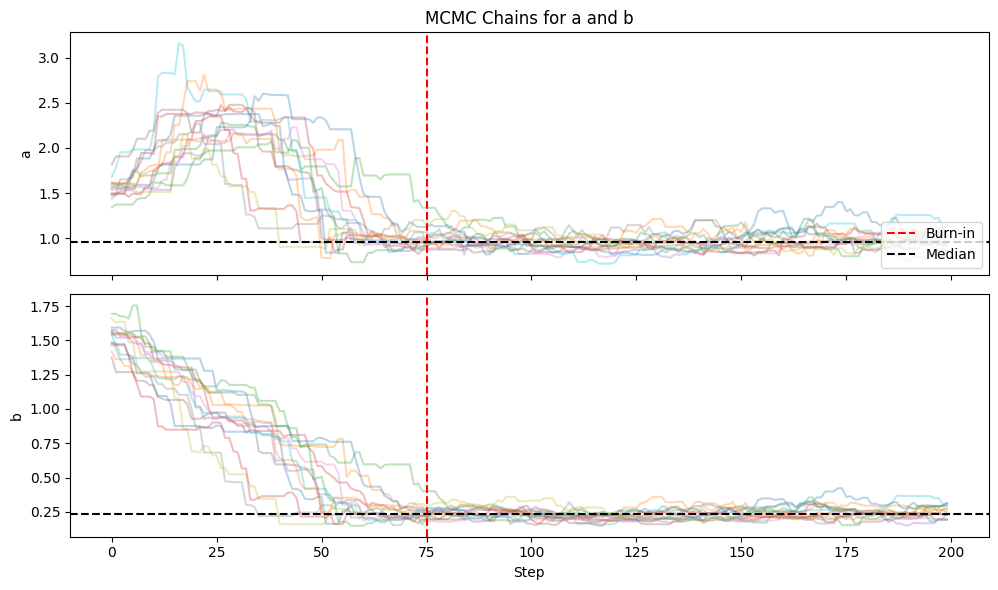

Execution time: 0.1623 seconds


In [17]:
# Plot MCMC diagnostics

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
labels = ['a', 'b']
chain = backend.get_chain()

for i in range(2):
    ax = axes[i]
    ax.plot(chain[:, :, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.axvline(burn_in, color='r', linestyle='--', label='Burn-in')
    ax.axhline(np.median(flat_samples_Mdep_omega[:, i]), color='k', linestyle='--', label='Median')

axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC Chains for a and b")
axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()
# fig.savefig(f'../outputs/graphs_elise_new_rot/mcmc_chain_Mdep_omega_{starformationlaw}.pdf', dpi=300)


Corner plot statistics:
  $a$ (Gyr$^{-1}$): mode = 0.9323, median = 0.9572, 1-sigma = [0.8785, 1.0631]
  $b$ (Gyr$^{-1}$): mode = 0.2298, median = 0.2339, 1-sigma = [0.1964, 0.2804]


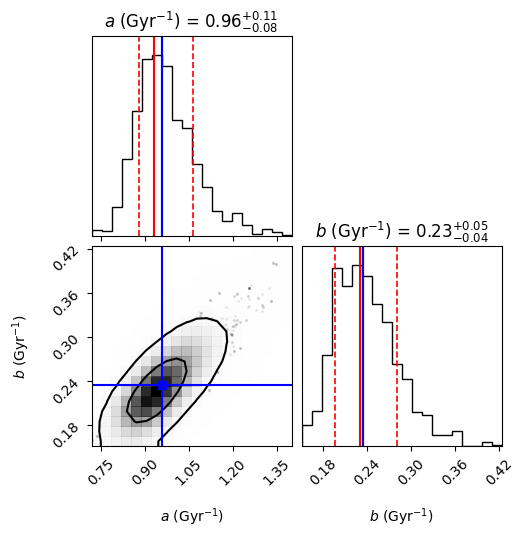

Execution time: 0.3001 seconds


In [18]:
# Corner plot

fig_corner = plot_corner_Mdep_omega(
    flat_samples_Mdep_omega, 
    labels=[r'$a$ (Gyr$^{-1}$)', r'$b$ (Gyr$^{-1}$)'],
    title=None#"$\\omega_{\\rm acc} = a(\\log M_{\\rm bar} - 10) + b$"
)
if fig_corner is not None:
    plt.show()
    # fig_corner.savefig(f'../outputs/graphs_elise_new_rot/corner_Mdep_omega_{starformationlaw}.pdf', dpi=300)

In [19]:
# Plot model with best-fit parameters vs data

log_M_grid = np.linspace(8, 11.5, 50)

r_acc_grid_bestfit = np.zeros((len(log_M_grid), 10))
j_acc_grid_bestfit = np.zeros((len(log_M_grid), 10))
for i, logM in enumerate(log_M_grid):
    r_acc_grid_bestfit[i], j_acc_grid_bestfit[i] = build_r_acc_for_single_M(logM, n_j=10)

r_acc_grid_bestfit_jax = jnp.array(r_acc_grid_bestfit, dtype=jnp.float64)
log_M_grid_jax = jnp.array(log_M_grid, dtype=jnp.float64)

print("Running model with best-fit parameters...")
f_gas_bf, j_bar_bf, j_gas_bf, j_star_bf, Ms_bf, Mg_bf = run_all_masses_Mdep_omega_jax(
    log_M_grid_jax, a_median, b_median, r_acc_grid_bestfit_jax
)

f_gas_bestfit = np.array(f_gas_bf)
j_bar_bestfit = np.array(j_bar_bf)
log_j_bar_bestfit = np.log10(j_bar_bestfit)

print("Done!")
print(f"Best-fit omega at logM=10: {omega_Mdep(10.0, a_median, b_median):.4f} Gyr^-1")
print(f"Best-fit t_acc at logM=10: {tacc_Mdep(10.0, a_median, b_median):.2f} Gyr")

Running model with best-fit parameters...


Done!
Best-fit omega at logM=10: 0.2339 Gyr^-1
Best-fit t_acc at logM=10: 4.28 Gyr
Execution time: 7.7089 seconds


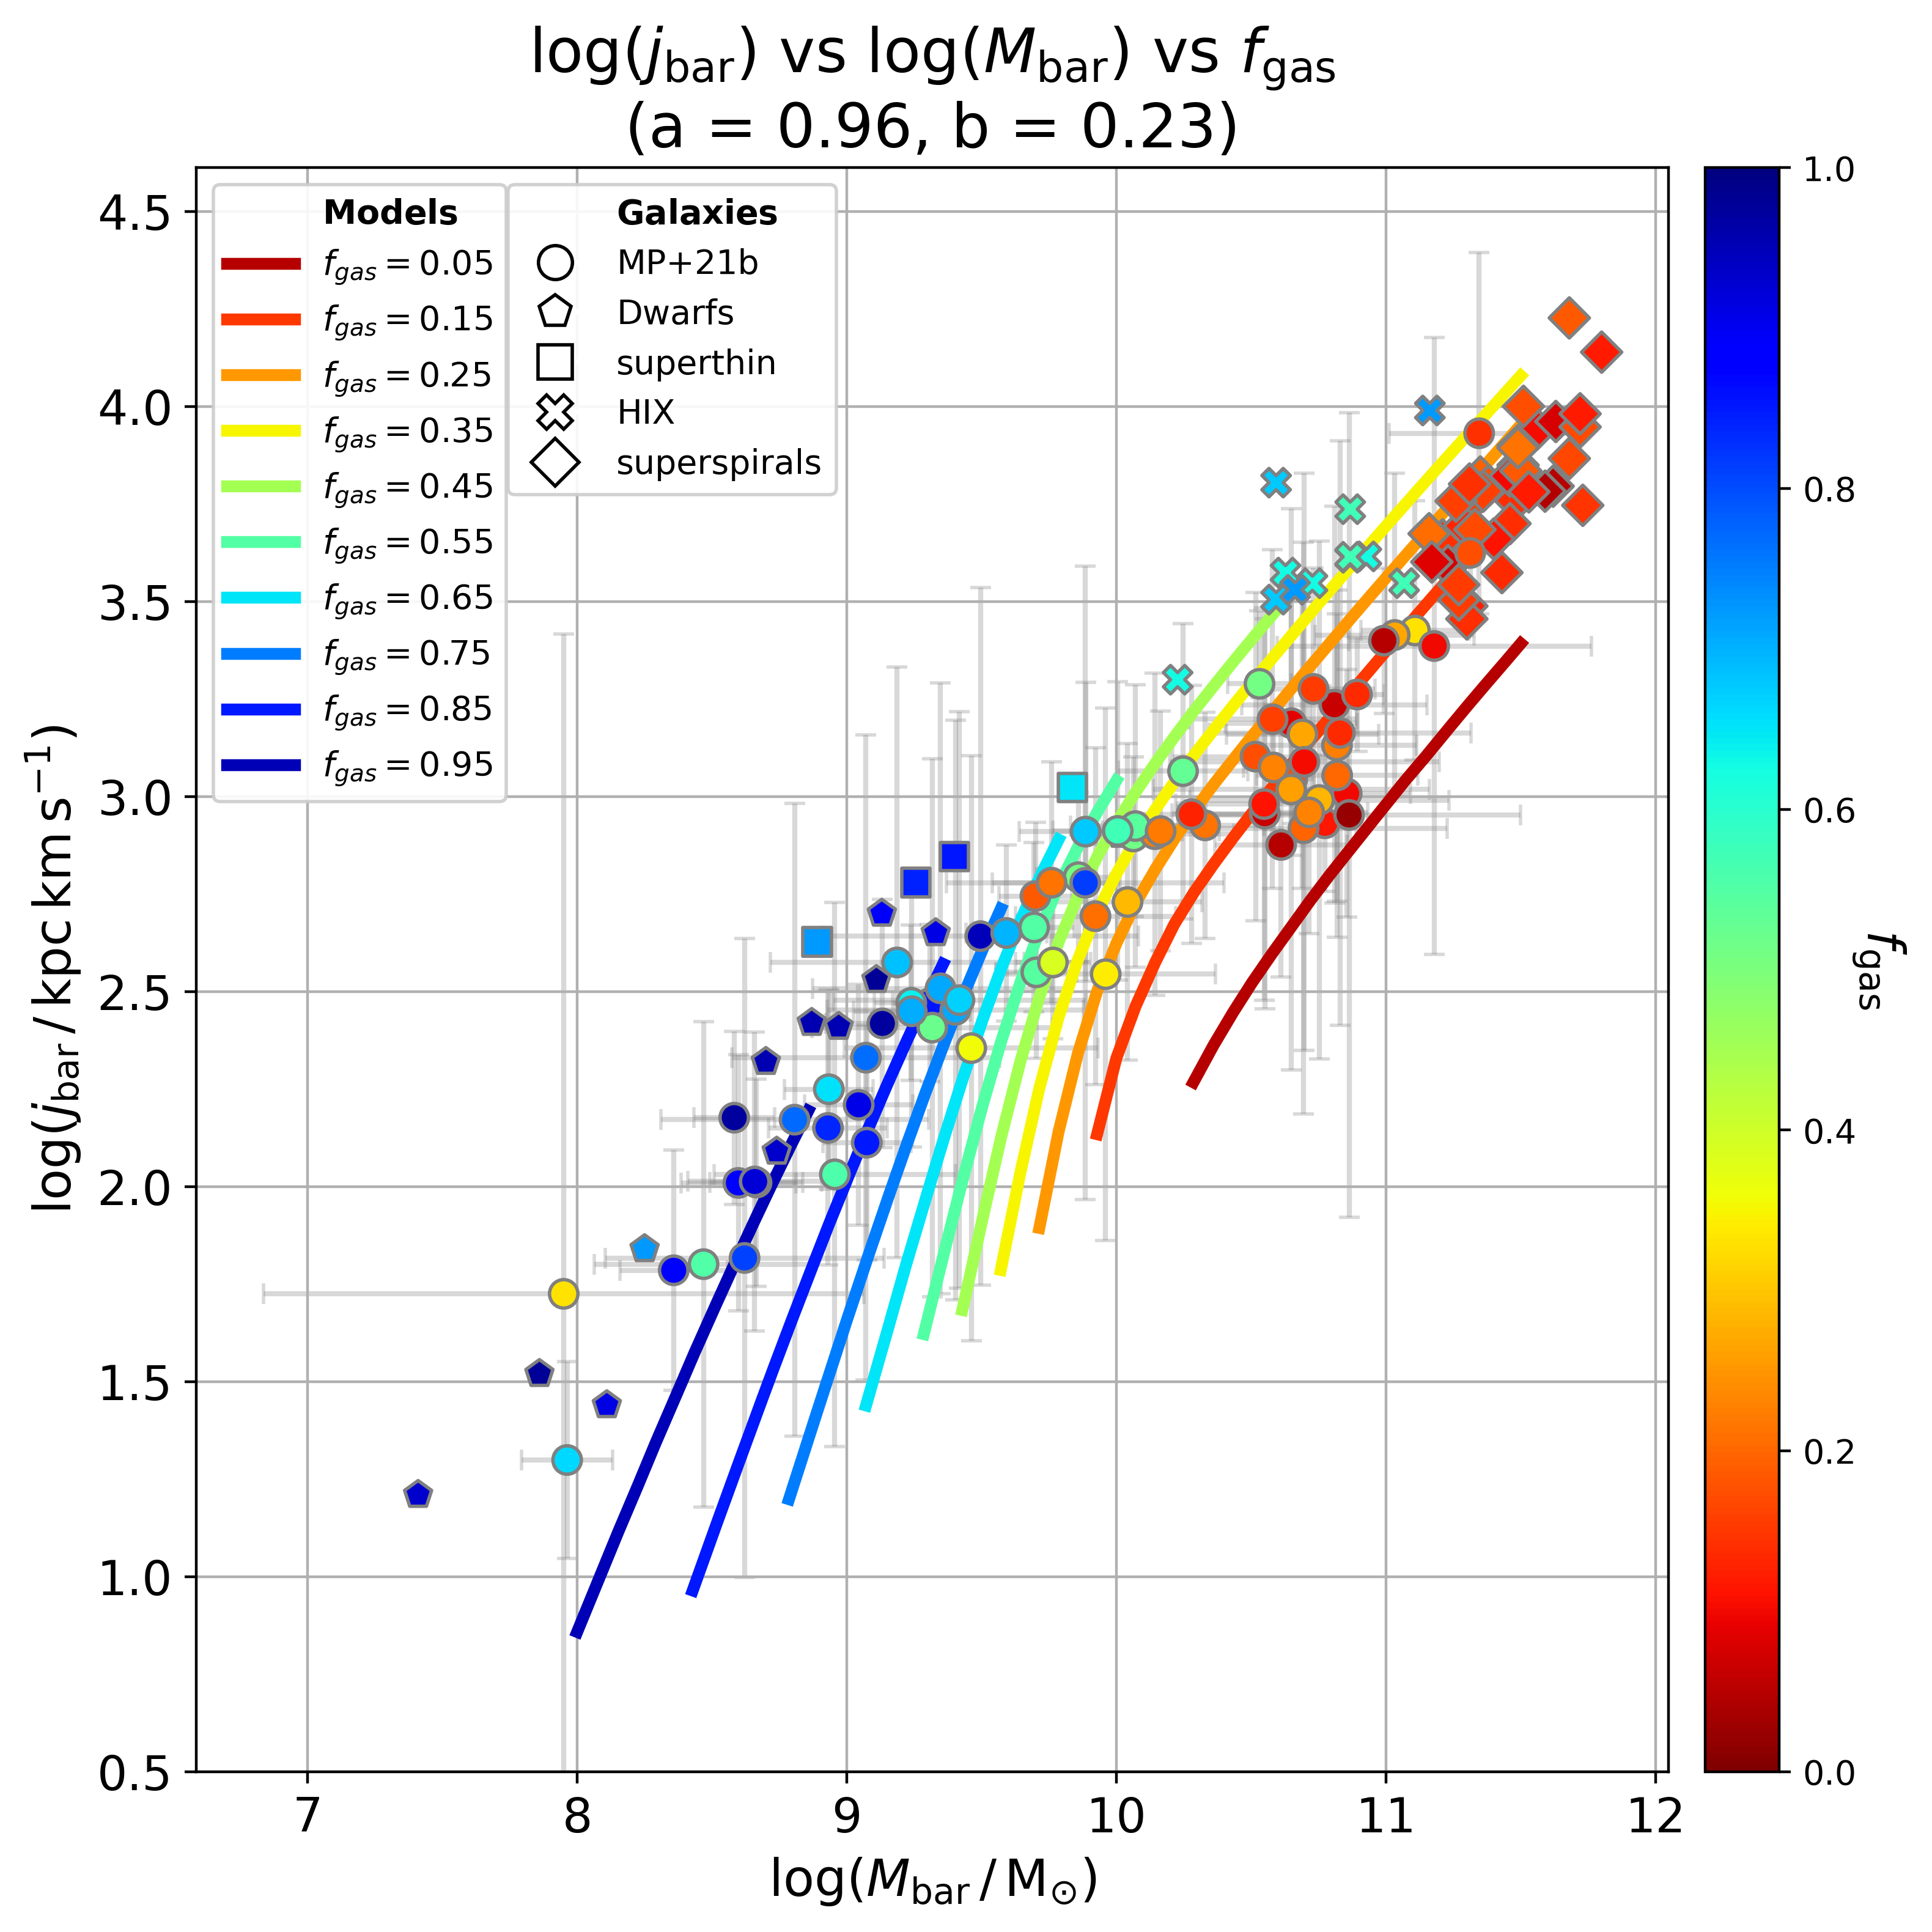

Execution time: 0.5496 seconds


In [20]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8, 8), dpi=400, facecolor='w')
frame = fig.add_subplot(1, 1, 1)

# Colorbar
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

# Model lines at constant f_gas
f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

# Interpolate model to get j_bar at constant f_gas
n_interp = 1000
interp_f_gas_bestfit = np.zeros((len(log_M_grid), n_interp))
interp_j_bar_bestfit = np.zeros((len(log_M_grid), n_interp))

for i in range(len(log_M_grid)):
    f_min, f_max = f_gas_bestfit[i, :].min(), f_gas_bestfit[i, :].max()
    if f_max > f_min:
        interp_f_gas_bestfit[i] = np.linspace(f_min, f_max, n_interp)
        try:
            ipl = spl.interp1d(f_gas_bestfit[i, :], log_j_bar_bestfit[i, :], 
                              kind='linear', fill_value='extrapolate')
            interp_j_bar_bestfit[i] = ipl(interp_f_gas_bestfit[i])
        except:
            interp_j_bar_bestfit[i] = np.nan

log_M_bar_array_backup = log_M_bar_array.copy()
log_M_bar_array = log_M_grid

# Plot model lines
mods = frame.plot([], [], ' ', label="Models")
for i, f_gas_value in enumerate(f_gas_values):
    indexed_M, indexed_j = modelled_j_bar2(interp_f_gas_bestfit, interp_j_bar_bestfit, f_gas_value)
    if len(indexed_M) > 0:
        ax1 = frame.plot(indexed_M, indexed_j, 
                        label=rf"$f_{{gas}} = {f_gas_value:.2f}$", 
                        color=colors[i], lw=3.5, zorder=2)
        ax1s.append(ax1[0])

# Restore original log_M_bar_array
log_M_bar_array = log_M_bar_array_backup

# Filter valid lines
valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if hasattr(x, '__len__') and len(x) > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

# Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", 
                   facecolors=cmap(obs_fgas), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, 
              fmt=' ', ecolor='grey', capsize=3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{\rm gas}$", rotation=270, fontsize=15, labelpad=15)

marker_map = {
    'Dwarfs': 'p',
    'superthin': 's', 
    'HIX': 'X',
    'superspirals': 'D',
}
# scatter_legends = []
for i, (idx, df) in enumerate(pavel_data.items(), start=3):
    marker = marker_map[idx]
    # print(idx, marker)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=idx, marker=marker, facecolors=cmap(df['fgas'].values.copy()), edgecolors="grey", s=70, zorder=i)
    # scatter_legends.append(scatter)

# Legend
models_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Models}$")
models_legend_elements = [models_header] + ax1s
 
galaxies_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Galaxies}$")
galaxy_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")
] + [
    plt.Line2D([0], [0], marker=marker_map[name], color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for name in ['Dwarfs', 'superthin', 'HIX', 'superspirals']
]
galaxies_legend_elements = [galaxies_header] + galaxy_legend_elements

leg1 = frame.legend(handles=models_legend_elements, loc='upper left', framealpha=0.9)
frame.add_artist(leg1)
leg2 = frame.legend(handles=galaxies_legend_elements, loc='upper left', bbox_to_anchor=(0.2, 1.0), framealpha=0.9)

# Title with best-fit parameters
title_str = (rf"$\log(j_{{\rm bar}})$ vs $\log(M_{{\rm bar}})$ vs $f_{{\rm gas}}$" + "\n" +
            f"(a = {a_median:.2f}, b = {b_median:.2f})")
frame.set_title(title_str, fontsize=18)
frame.set_xlabel(r"$\log(M_{\rm bar} \, / \, \rm M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$\log(j_{\rm bar} \, / \, \rm kpc \, km \, s^{-1})$", fontsize = 15)
#frame.legend(handles=legend_elements, loc='upper left', fontsize=9)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
# frame.set_xlim([8, 12])
frame.set_ylim(0.5)

plt.tight_layout()
plt.show()
# fig.savefig(f'../outputs/graphs_elise_new_rot/log_j_bar_vs_log_M_bar_Mdep_omega_bestfit_{starformationlaw}.pdf', dpi=300)

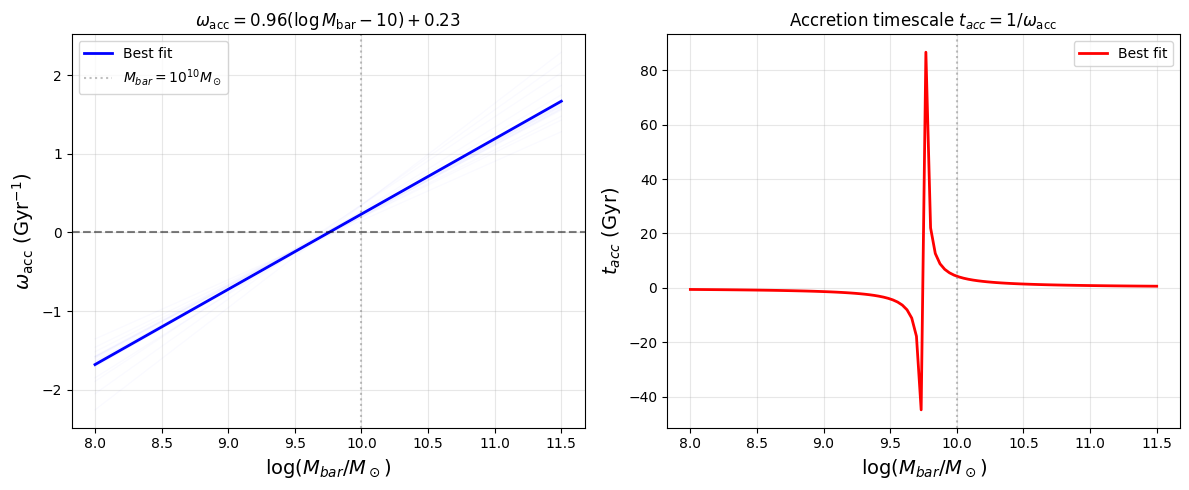

Execution time: 0.3853 seconds


In [21]:
# Plot omega vs M_bar from best-fit

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

logM_plot = np.linspace(8, 11.5, 100)
omega_plot = omega_Mdep(logM_plot, a_median, b_median)
tacc_plot = tacc_Mdep(logM_plot, a_median, b_median)

# Left panel: omega vs logM
ax1 = axes[0]
ax1.plot(logM_plot, omega_plot, 'b-', lw=2, label='Best fit')
ax1.axhline(0, color='k', linestyle='--', alpha=0.5)
ax1.axvline(10, color='gray', linestyle=':', alpha=0.5, label=r'$M_{bar} = 10^{10} M_\odot$')

# Draw uncertainty band from MCMC samples
for i in range(0, len(flat_samples_Mdep_omega), 100):
    a_s, b_s = flat_samples_Mdep_omega[i]
    omega_s = omega_Mdep(logM_plot, a_s, b_s)
    ax1.plot(logM_plot, omega_s, 'b-', alpha=0.02, lw=1)

ax1.set_xlabel(r'$\log(M_{bar}/M_\odot)$', fontsize=14)
ax1.set_ylabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=14)
ax1.set_title(rf'$\omega_{{\rm acc}} = {a_median:.2f}(\log M_{{\rm bar}} - 10) + {b_median:.2f}$', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Right panel: t_acc vs logM
ax2 = axes[1]
# Only plot where omega is not too close to zero
valid_mask = np.abs(omega_plot) > 0.01
ax2.plot(logM_plot[valid_mask], tacc_plot[valid_mask], 'r-', lw=2, label='Best fit')
ax2.axvline(10, color='gray', linestyle=':', alpha=0.5)

ax2.set_xlabel(r'$\log(M_{bar}/M_\odot)$', fontsize=14)
ax2.set_ylabel(r'$t_{acc}$ (Gyr)', fontsize=14)
ax2.set_title(r'Accretion timescale $t_{acc} = 1/\omega_{\rm acc}$', fontsize=12)
# ax2.set_ylim([-50, 50])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# fig.savefig(f'../outputs/graphs_elise_new_rot/omega_tacc_vs_Mbar_bestfit_{starformationlaw}.pdf', dpi=300)

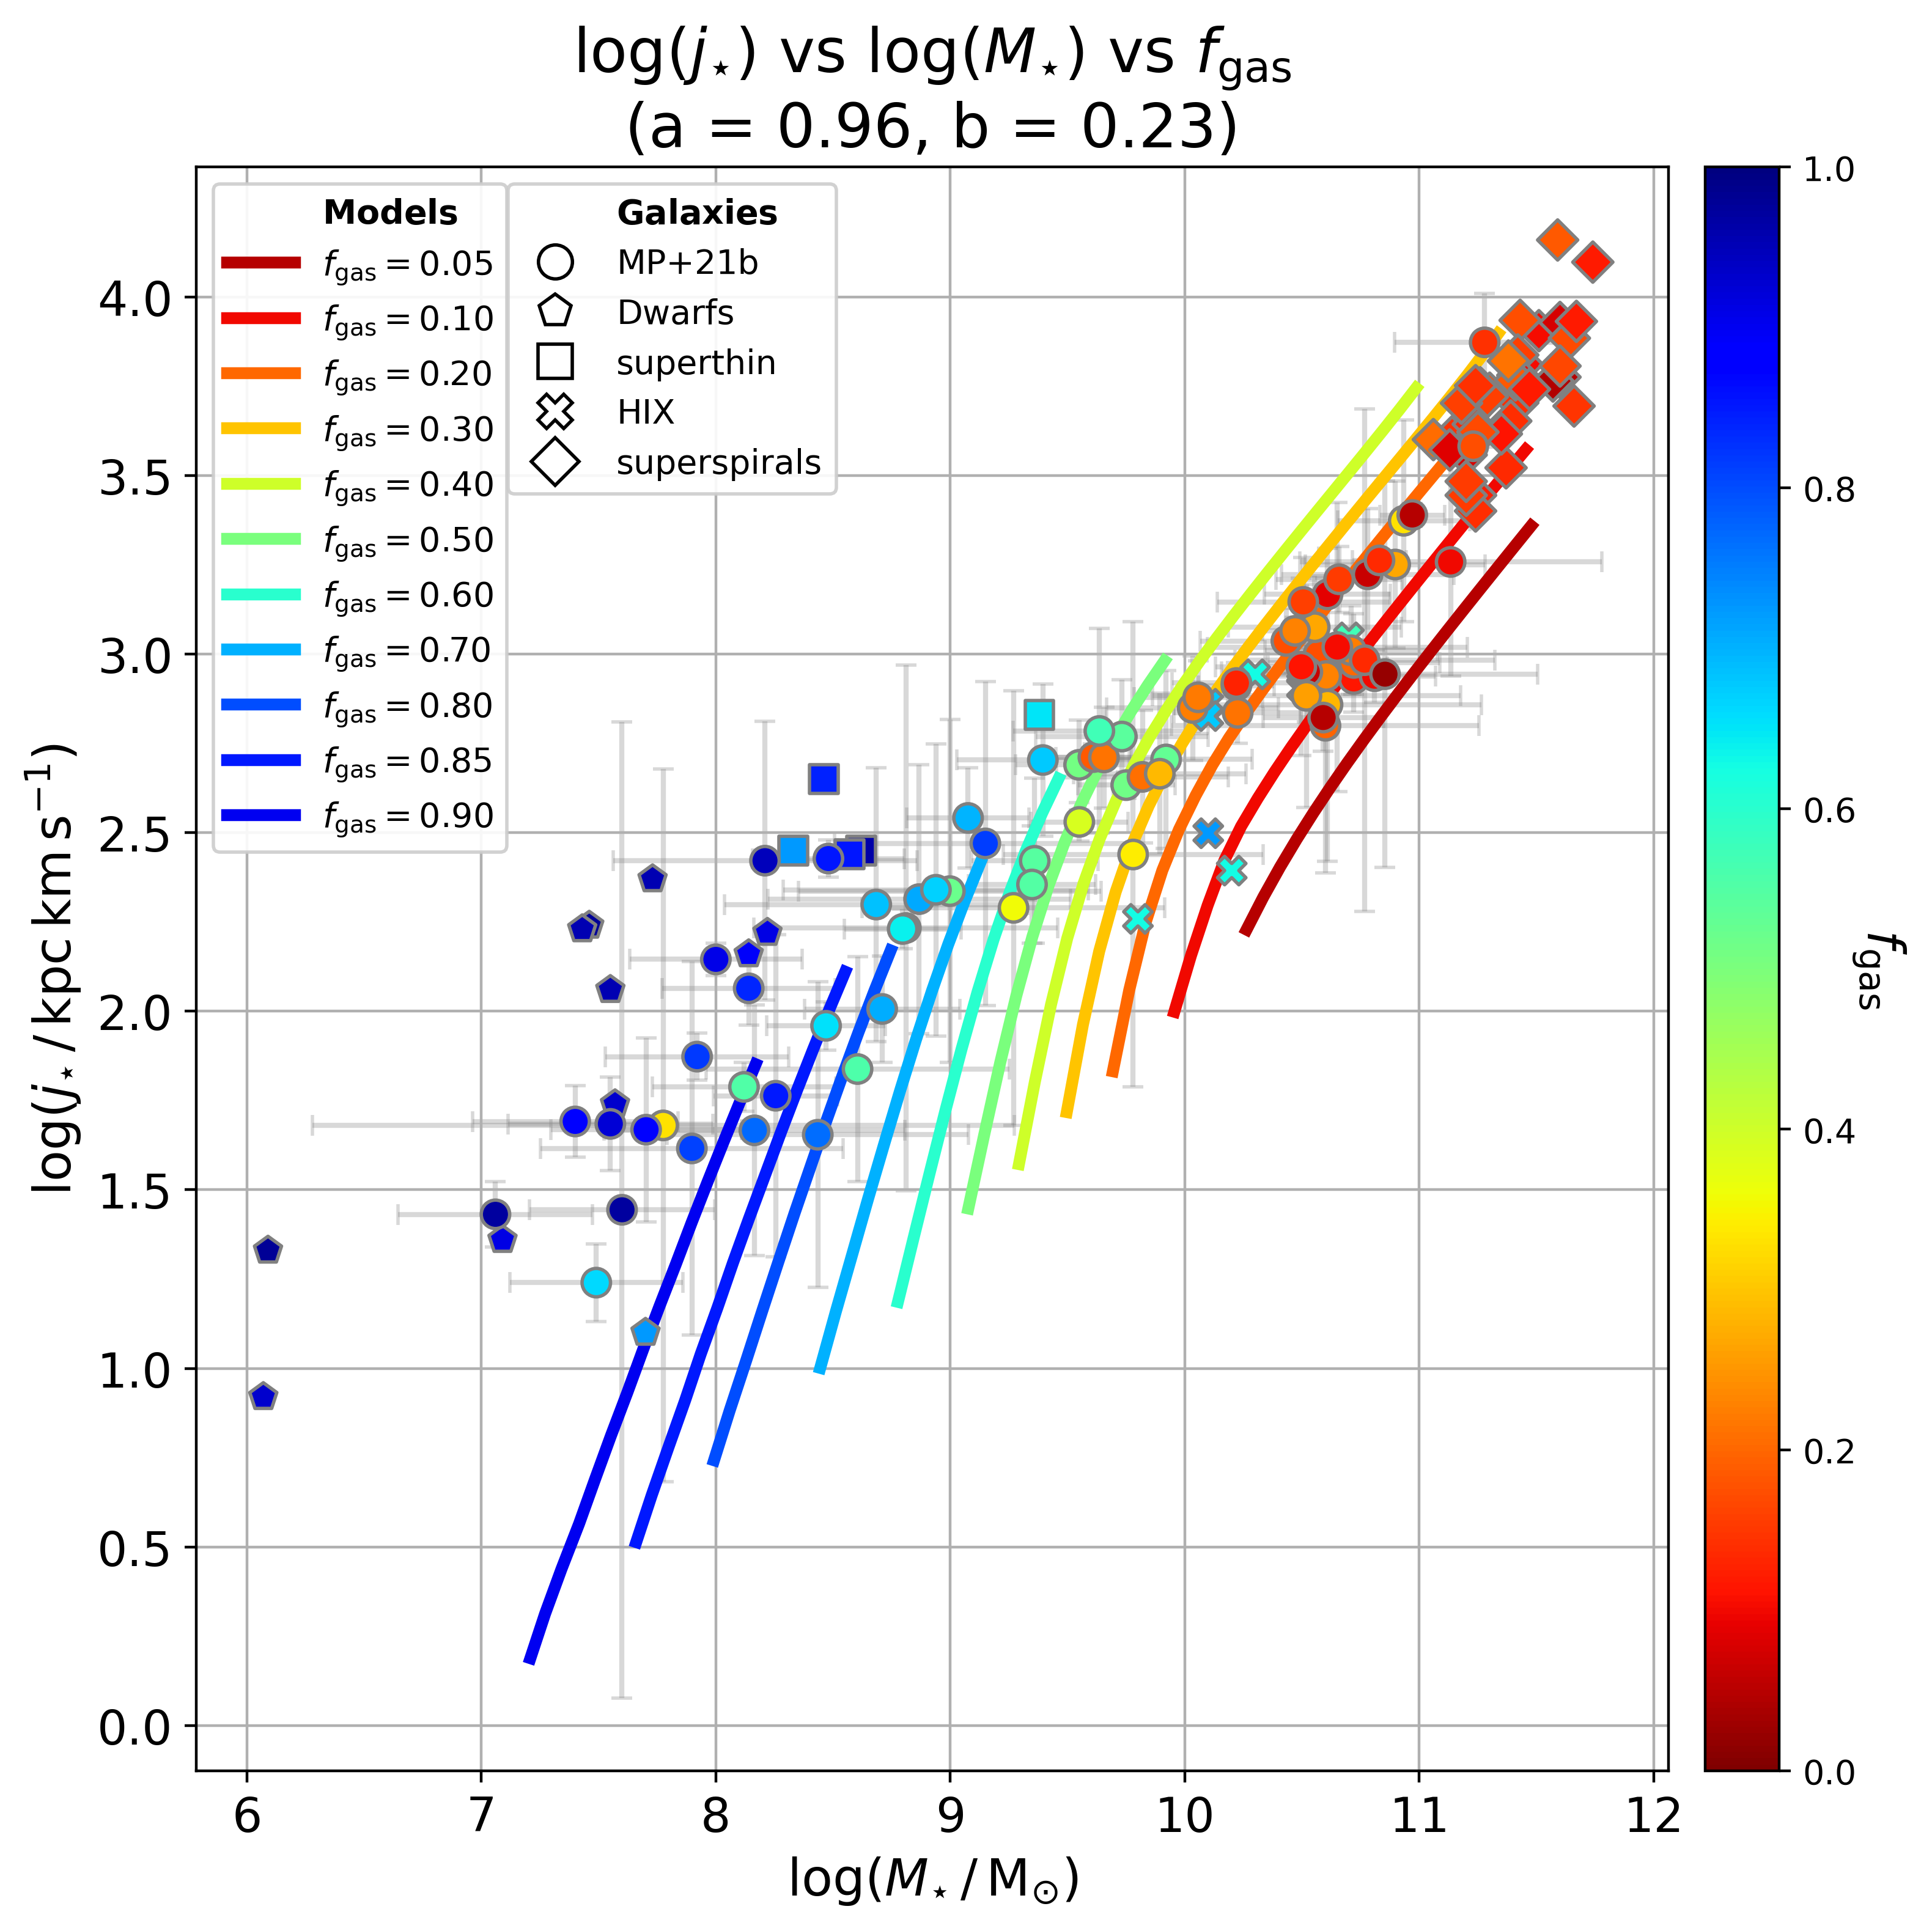

Execution time: 0.5309 seconds


In [22]:
# j_star vs M_star vs f_gas

# Convert model outputs to log scale
log_j_star_bf = np.log10(
    np.array(j_star_bf),
    where=(np.array(j_star_bf) > 0),
    out=np.full_like(np.array(j_star_bf), np.nan)
)
log_M_star_bf = np.log10(
    np.array(Ms_bf),
    where=(np.array(Ms_bf) > 0),
    out=np.full_like(np.array(Ms_bf), np.nan)
)
f_gas_bf_np = np.array(f_gas_bf)

# Create interpolators: f_gas -> log_M_star and f_gas -> log_j_star for each mass track
f_to_logMstar = []
f_to_logjstar = []

for i in range(f_gas_bf_np.shape[0]):
    mask = (np.isfinite(f_gas_bf_np[i]) & 
            np.isfinite(log_M_star_bf[i]) & 
            np.isfinite(log_j_star_bf[i]))
    
    if mask.sum() < 2:
        f_to_logMstar.append(None)
        f_to_logjstar.append(None)
        continue
    
    # Sort by f_gas and de-duplicate
    order = np.argsort(f_gas_bf_np[i, mask])
    fg = f_gas_bf_np[i, mask][order]
    xM = log_M_star_bf[i, mask][order]
    yJ = log_j_star_bf[i, mask][order]
    
    # Keep unique f_gas values
    uniq, uidx = np.unique(fg, return_index=True)
    fg = uniq
    xM = xM[uidx]
    yJ = yJ[uidx]
    
    if len(fg) < 2:
        f_to_logMstar.append(None)
        f_to_logjstar.append(None)
        continue
    
    f_to_logMstar.append(spl.interp1d(fg, xM, kind='linear', bounds_error=False, fill_value=np.nan))
    f_to_logjstar.append(spl.interp1d(fg, yJ, kind='linear', bounds_error=False, fill_value=np.nan))

# Plot
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8, 8), dpi=400, facecolor='w')
frame = fig.add_subplot(1, 1, 1)

# Colorbar
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

# Model lines at constant f_gas
f_gas_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9]
ax1s = []

for fg_val, col in zip(f_gas_values, cmap(f_gas_values)):
    xs = np.array([f(fg_val) if f is not None else np.nan for f in f_to_logMstar])
    ys = np.array([g(fg_val) if g is not None else np.nan for g in f_to_logjstar])
    mask = np.isfinite(xs) & np.isfinite(ys)
    
    if mask.sum() < 2:
        continue
    
    # Sort by M_star to make line monotonic
    order = np.argsort(xs[mask])
    ax1 = frame.plot(xs[mask][order], ys[mask][order], 
                     lw=3.5, color=col, 
                     label=rf"$f_{{\rm gas}}={fg_val:.2f}$", zorder=2)
    ax1s.append(ax1[0])

# Observational data
ax2 = frame.scatter(obs_Mstar, obs_jstar, label="MP+21b", marker="o",
                    facecolors=cmap(obs_fgas), 
                    edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mstar, obs_jstar, 
               xerr=obs_Mstar_errors, yerr=obs_jstar_errors,
               fmt=' ', ecolor='grey', capsize=3, alpha=0.3, zorder=0)

cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{\rm gas}$", rotation=270, fontsize=15, labelpad=15)


# Compilation data
marker_map = {'Dwarfs': 'p', 'superthin': 's', 'HIX': 'X', 'superspirals': 'D'}
for i, (idx, df) in enumerate(pavel_data.items(), start=3):
    marker = marker_map[idx]
    frame.scatter(df['logMstar'], df['logjstar'], marker=marker,
                  facecolors=cmap(df['fgas'].values.copy()),
                  edgecolors='grey', s=70, zorder=i)

# Legend
models_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Models}$")
models_legend_elements = [models_header] + ax1s

galaxies_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Galaxies}$")
galaxy_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
               markeredgecolor='k', markersize=10, label="MP+21b")
] + [
    plt.Line2D([0], [0], marker=marker_map[name], color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=10, label=name)
    for name in ['Dwarfs', 'superthin', 'HIX', 'superspirals']
]
galaxies_legend_elements = [galaxies_header] + galaxy_legend_elements

leg1 = frame.legend(handles=models_legend_elements, loc='upper left', framealpha=0.9)
frame.add_artist(leg1)
leg2 = frame.legend(handles=galaxies_legend_elements, loc='upper left', 
                    bbox_to_anchor=(0.2, 1.0), framealpha=0.9)

# Title with best-fit parameters
title_str = (rf"$\log(j_{{\star}})$ vs $\log(M_{{\star}})$ vs $f_{{\rm gas}}$" + "\n" +
            f"(a = {a_median:.2f}, b = {b_median:.2f})")
frame.set_title(title_str, fontsize=18)
frame.set_xlabel(r"$\log(M_{\star} \, / \, \rm M_{\odot})$", fontsize=15)
frame.set_ylabel(r"$\log(j_{\star} \, / \, \rm kpc \, km \, s^{-1})$", fontsize=15)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)

plt.tight_layout()
plt.show()
# fig.savefig(f'../outputs/graphs_elise_new_rot/log_j_star_vs_log_M_star_Mdep_omega_bestfit_{starformationlaw}.pdf', dpi=300)

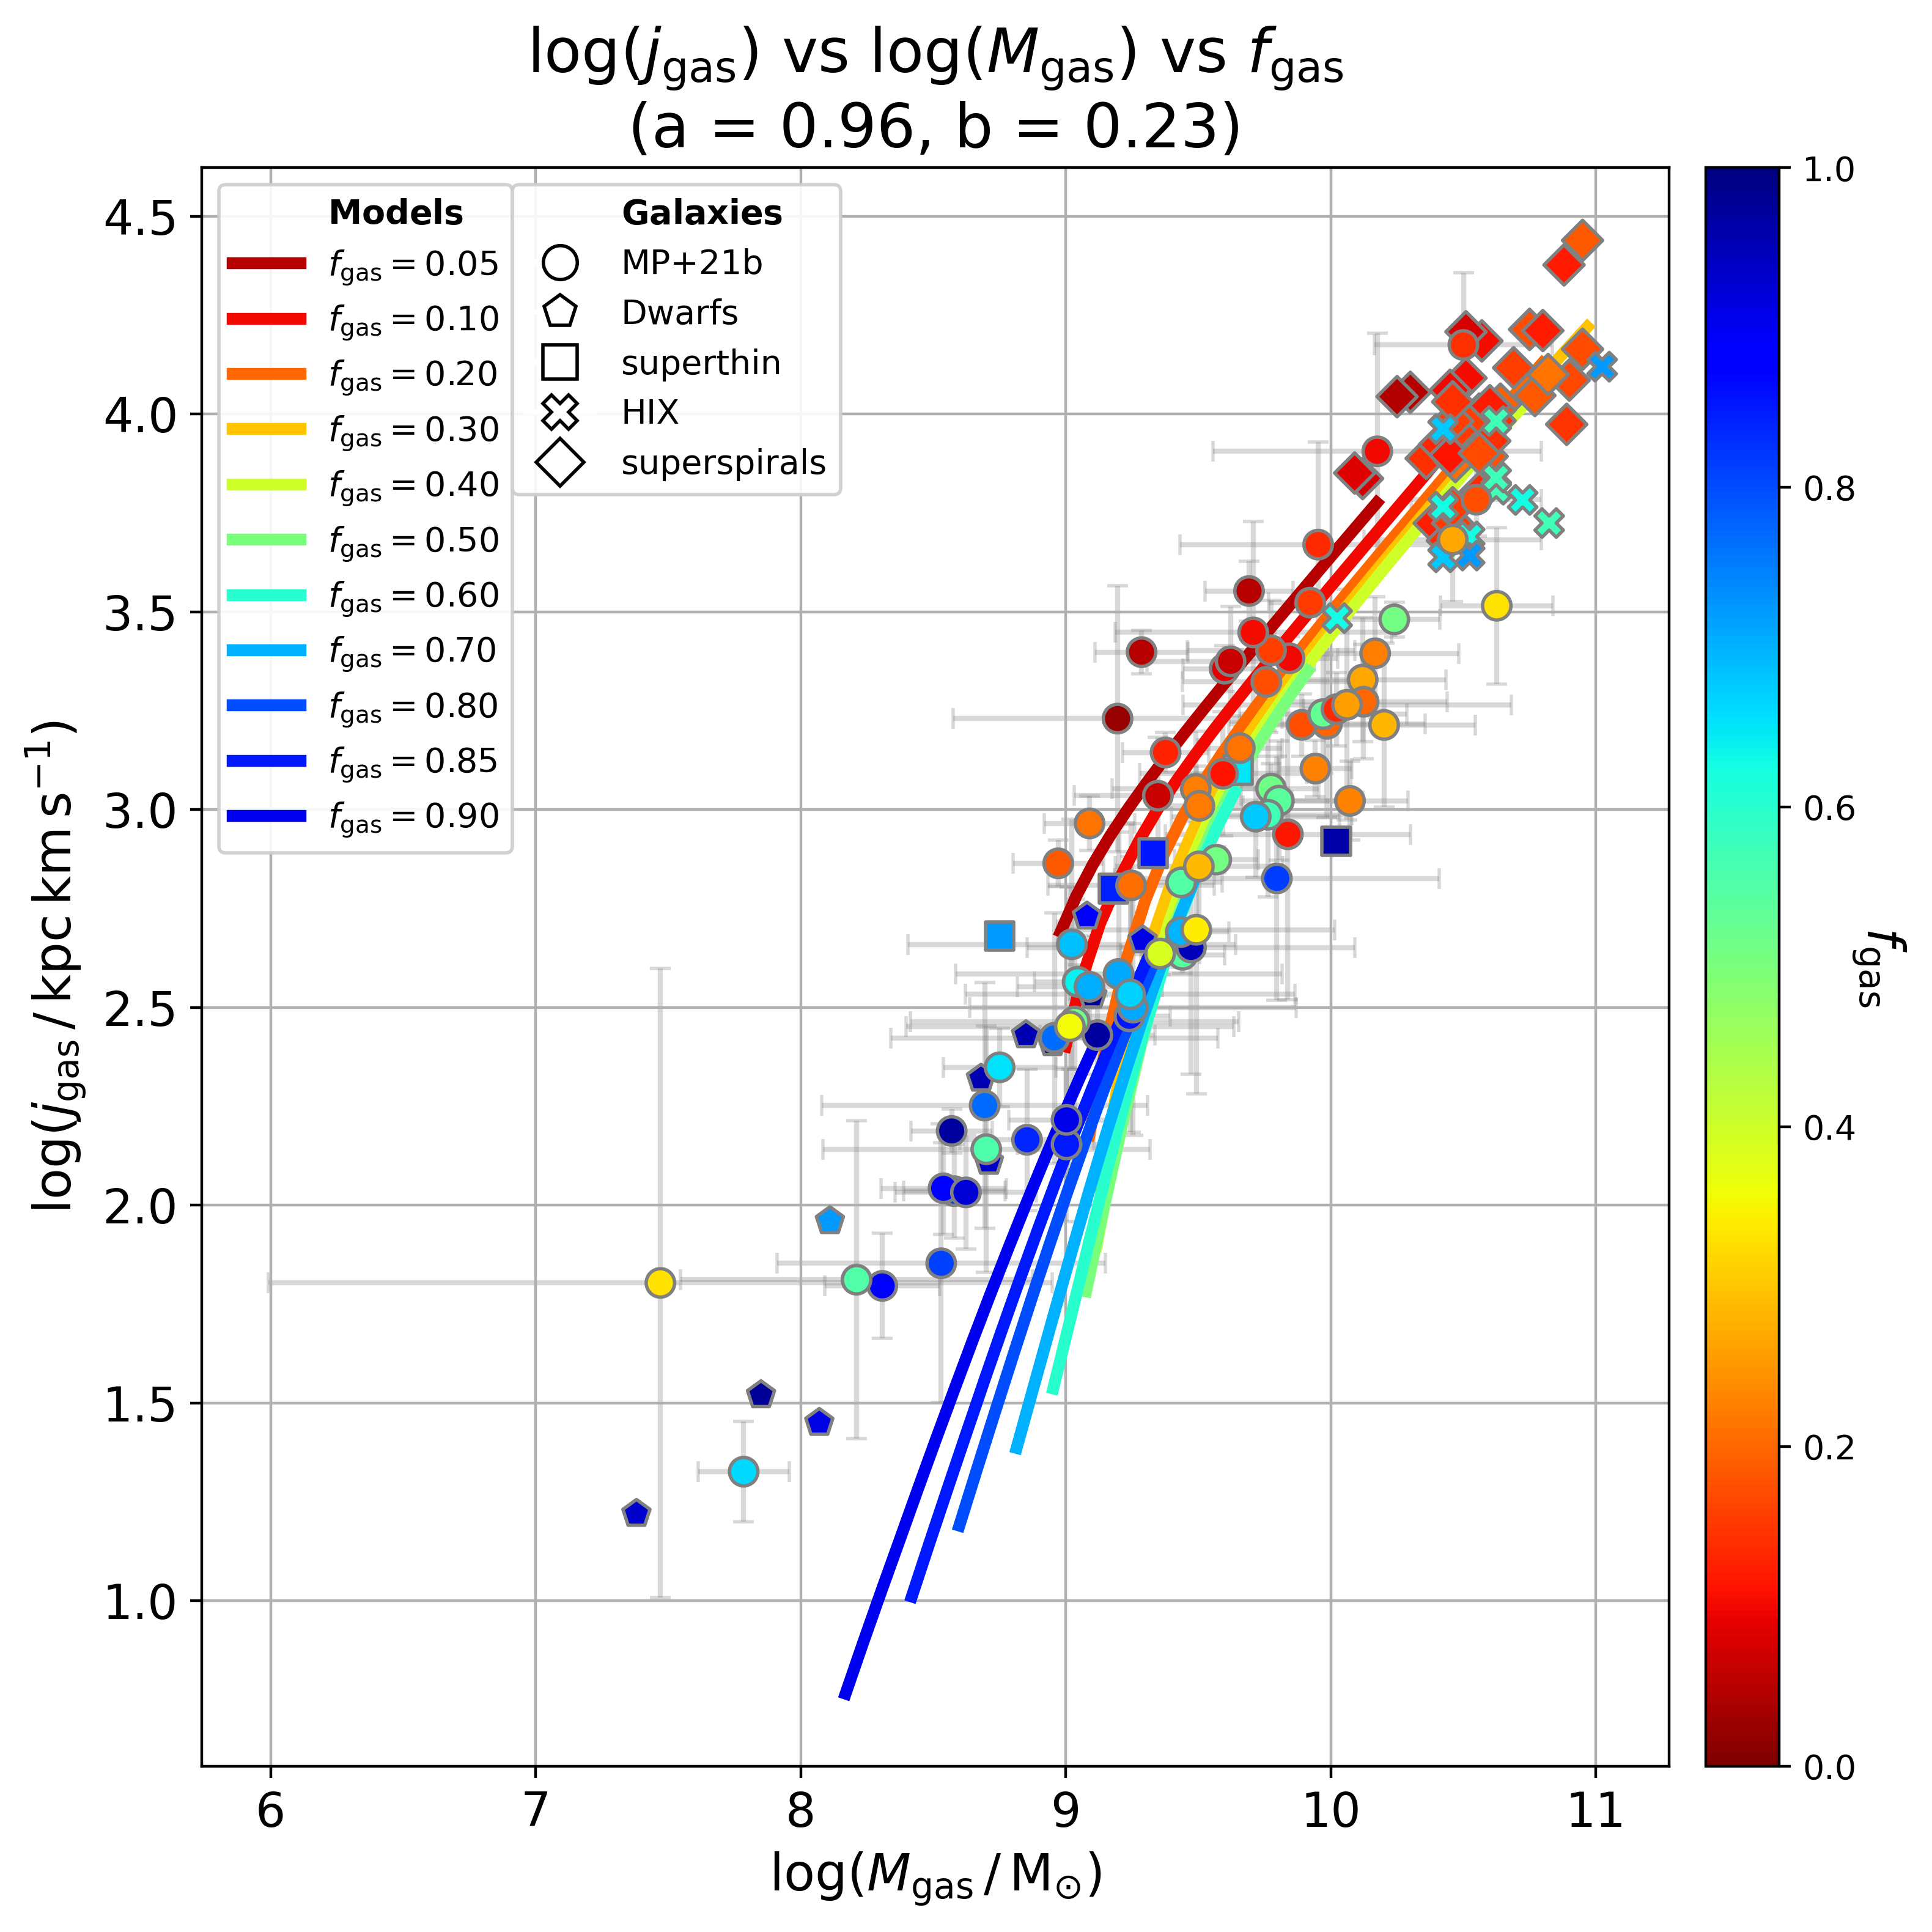

Execution time: 0.5257 seconds


In [23]:
# j_gas vs M_gas vs f_gas

# Convert model outputs to log scale
log_j_gas_bf = np.log10(
    np.array(j_gas_bf),
    where=(np.array(j_gas_bf) > 0),
    out=np.full_like(np.array(j_gas_bf), np.nan)
)
log_M_gas_bf = np.log10(
    np.array(Mg_bf),
    where=(np.array(Mg_bf) > 0),
    out=np.full_like(np.array(Mg_bf), np.nan)
)

# Create interpolators: f_gas -> log_M_gas and f_gas -> log_j_gas for each mass track
f_to_logMgas = []
f_to_logjgas = []

for i in range(f_gas_bf_np.shape[0]):
    mask = (np.isfinite(f_gas_bf_np[i]) & 
            np.isfinite(log_M_gas_bf[i]) & 
            np.isfinite(log_j_gas_bf[i]))
    
    if mask.sum() < 2:
        f_to_logMgas.append(None)
        f_to_logjgas.append(None)
        continue
    
    # Sort by f_gas and de-duplicate
    order = np.argsort(f_gas_bf_np[i, mask])
    fg = f_gas_bf_np[i, mask][order]
    xM = log_M_gas_bf[i, mask][order]
    yJ = log_j_gas_bf[i, mask][order]
    
    # Keep unique f_gas values
    uniq, uidx = np.unique(fg, return_index=True)
    fg = uniq
    xM = xM[uidx]
    yJ = yJ[uidx]
    
    if len(fg) < 2:
        f_to_logMgas.append(None)
        f_to_logjgas.append(None)
        continue
    
    f_to_logMgas.append(spl.interp1d(fg, xM, kind='linear', bounds_error=False, fill_value=np.nan))
    f_to_logjgas.append(spl.interp1d(fg, yJ, kind='linear', bounds_error=False, fill_value=np.nan))

# Plot
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8, 8), dpi=400, facecolor='w')
frame = fig.add_subplot(1, 1, 1)

# Colorbar
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

# Model lines at constant f_gas
f_gas_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9]
ax1s = []

for fg_val, col in zip(f_gas_values, cmap(f_gas_values)):
    xs = np.array([f(fg_val) if f is not None else np.nan for f in f_to_logMgas])
    ys = np.array([g(fg_val) if g is not None else np.nan for g in f_to_logjgas])
    mask = np.isfinite(xs) & np.isfinite(ys)
    
    if mask.sum() < 2:
        continue
    
    # Sort by M_gas to make line monotonic
    order = np.argsort(xs[mask])
    ax1 = frame.plot(xs[mask][order], ys[mask][order], 
                     lw=3.5, color=col, 
                     label=rf"$f_{{\rm gas}}={fg_val:.2f}$", zorder=2)
    ax1s.append(ax1[0])

# Observational data
ax2 = frame.scatter(obs_Mgas, obs_jgas, label="MP+21b", marker="o",
                    facecolors=cmap(obs_fgas), 
                    edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mgas, obs_jgas, 
               xerr=obs_Mgas_errors, yerr=obs_jgas_errors,
               fmt=' ', ecolor='grey', capsize=3, alpha=0.3, zorder=0)

cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{\rm gas}$", rotation=270, fontsize=15, labelpad=15)


# Compilation data
marker_map = {'Dwarfs': 'p', 'superthin': 's', 'HIX': 'X', 'superspirals': 'D'}
for i, (idx, df) in enumerate(pavel_data.items(), start=3):
    marker = marker_map[idx]
    frame.scatter(df['logMgas'], df['logjgas'], marker=marker,
                  facecolors=cmap(df['fgas'].values.copy()),
                  edgecolors='grey', s=70, zorder=i)

# Legend
models_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Models}$")
models_legend_elements = [models_header] + ax1s

galaxies_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Galaxies}$")
galaxy_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
               markeredgecolor='k', markersize=10, label="MP+21b")
] + [
    plt.Line2D([0], [0], marker=marker_map[name], color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=10, label=name)
    for name in ['Dwarfs', 'superthin', 'HIX', 'superspirals']
]
galaxies_legend_elements = [galaxies_header] + galaxy_legend_elements

leg1 = frame.legend(handles=models_legend_elements, loc='upper left', framealpha=0.9)
frame.add_artist(leg1)
leg2 = frame.legend(handles=galaxies_legend_elements, loc='upper left', 
                    bbox_to_anchor=(0.2, 1.0), framealpha=0.9)

# Title with best-fit parameters
title_str = (rf"$\log(j_{{\rm gas}})$ vs $\log(M_{{\rm gas}})$ vs $f_{{\rm gas}}$" + "\n" +
            f"(a = {a_median:.2f}, b = {b_median:.2f})")
frame.set_title(title_str, fontsize=18)
frame.set_xlabel(r"$\log(M_{\rm gas} \, / \, \rm M_{\odot})$", fontsize=15)
frame.set_ylabel(r"$\log(j_{\rm gas} \, / \, \rm kpc \, km \, s^{-1})$", fontsize=15)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)

plt.tight_layout()
plt.show()
# fig.savefig(f'../outputs/graphs_elise_new_rot/log_j_gas_vs_log_M_gas_Mdep_omega_bestfit_{starformationlaw}.pdf', dpi=300)

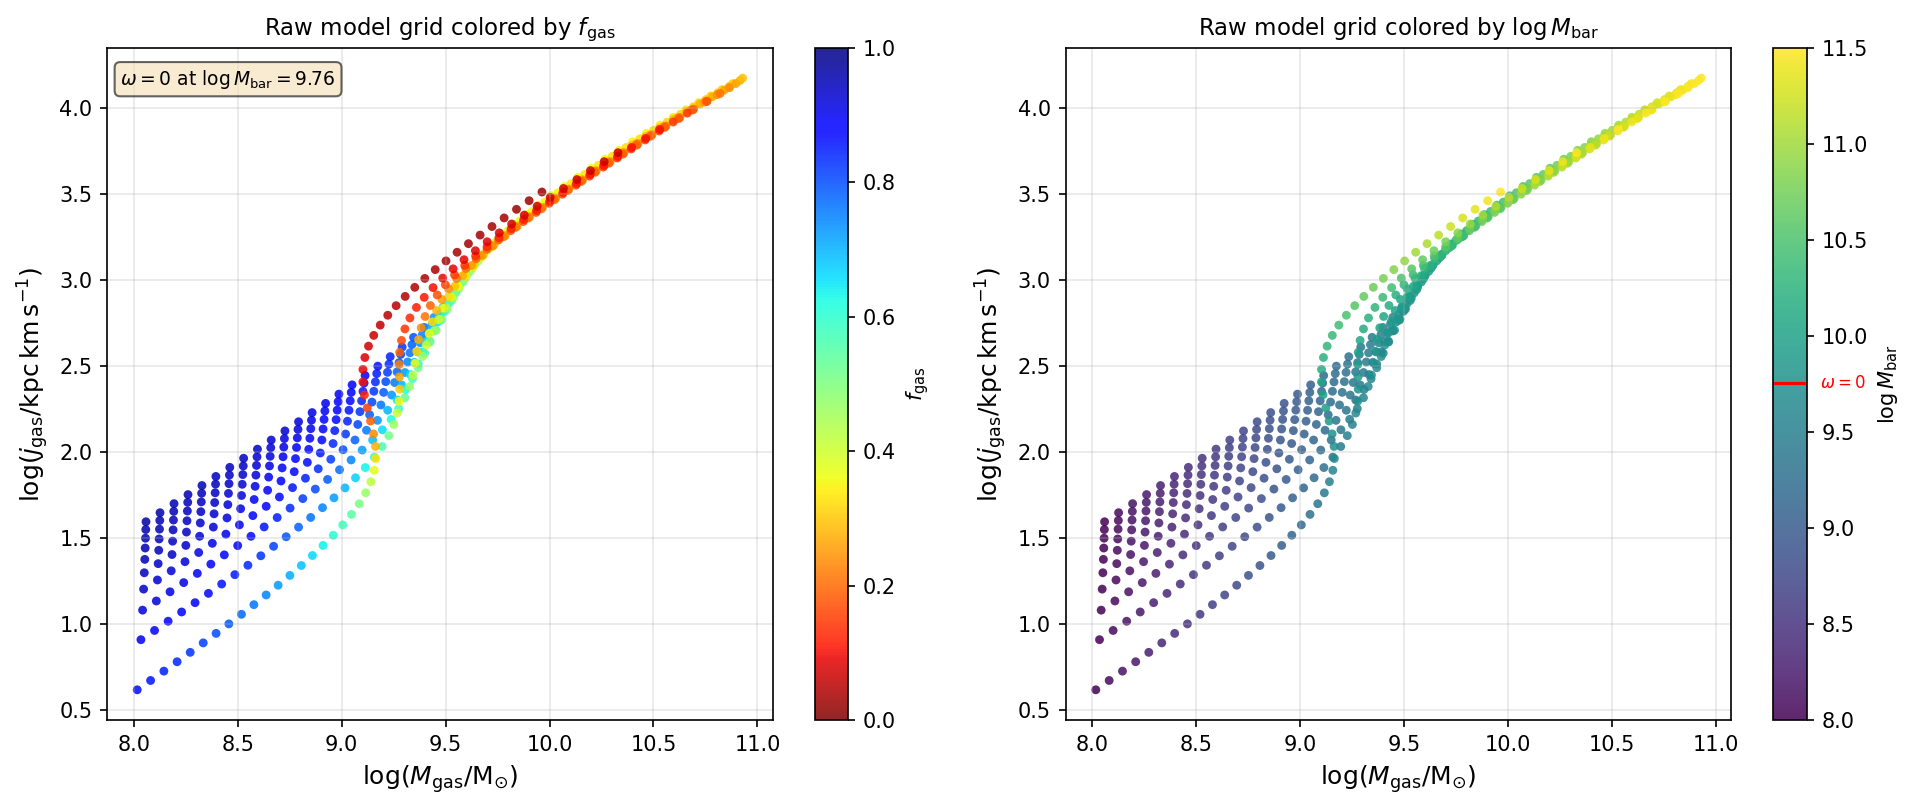


Monotonicity check
  0 / 50 mass tracks are NON-monotonic in f_gas vs j_acc
Execution time: 0.2914 seconds


In [24]:
# Diagnostic: raw model grid (no interpolation) for j_gas vs M_gas vs f_gas
# Each point is one (mass, j_acc) combination. Color = f_gas.
# If the raw points show the same crossing pattern as the interpolated curves,
# the crossing is a model property, not an interpolation artifact.

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=150, facecolor='w')

xx = log_M_gas_bf.flatten()
yy = log_j_gas_bf.flatten()
cc = f_gas_bf_np.flatten()
mm = log_M_grid[:, None].repeat(f_gas_bf_np.shape[1], axis=1).flatten()
valid = np.isfinite(xx) & np.isfinite(yy) & np.isfinite(cc)

# Mass at which omega = 0
logM_omega0 = 10.0 - b_median / a_median

# --- Left: raw points colored by f_gas ---
ax = axes[0]
sc = ax.scatter(xx[valid], yy[valid], c=cc[valid], cmap=cm.jet_r,
                s=18, edgecolors='none', alpha=0.85, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label=r'$f_{\rm gas}$')
ax.set_xlabel(r'$\log(M_{\rm gas} / \rm M_{\odot})$', fontsize=12)
ax.set_ylabel(r'$\log(j_{\rm gas} / \rm kpc \, km \, s^{-1})$', fontsize=12)
ax.set_title('Raw model grid colored by $f_{\\rm gas}$', fontsize=11)
ax.grid(alpha=0.3)
ax.text(0.02, 0.97, fr'$\omega = 0$ at $\log M_{{\rm bar}} = {logM_omega0:.2f}$',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# --- Right: same points colored by M_bar to see negative-omega regime ---
ax = axes[1]
sc = ax.scatter(xx[valid], yy[valid], c=mm[valid], cmap='viridis',
                s=18, edgecolors='none', alpha=0.85)
cbar = plt.colorbar(sc, ax=ax, label=r'$\log M_{\rm bar}$')
cbar.ax.axhline(logM_omega0, color='red', lw=1.5)
cbar.ax.text(1.4, logM_omega0, r'$\omega=0$', color='red',
             va='center', fontsize=8, transform=cbar.ax.get_yaxis_transform())
ax.set_xlabel(r'$\log(M_{\rm gas} / \rm M_{\odot})$', fontsize=12)
ax.set_ylabel(r'$\log(j_{\rm gas} / \rm kpc \, km \, s^{-1})$', fontsize=12)
ax.set_title(r'Raw model grid colored by $\log M_{\rm bar}$', fontsize=11)
ax.grid(alpha=0.3)

# plt.suptitle('Diagnostic: raw model output (no interpolation)', fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

print("\nMonotonicity check")
n_non_mono = 0
for i in range(f_gas_bf_np.shape[0]):
    fg_row = f_gas_bf_np[i]
    valid_row = np.isfinite(fg_row)
    if valid_row.sum() < 2:
        continue
    diffs = np.diff(fg_row[valid_row])
    if not (np.all(diffs >= -1e-10) or np.all(diffs <= 1e-10)):
        n_non_mono += 1
print(f"  {n_non_mono} / {f_gas_bf_np.shape[0]} mass tracks are NON-monotonic in f_gas vs j_acc")


logM=9: omega=-0.723 Gyr^-1, t_acc=-1.38 Gyr
  j_bar range: [20.8, 208.1] kpc km/s
  f_gas range: [0.619, 0.909]
logM=10: omega=0.234 Gyr^-1, t_acc=4.28 Gyr
  j_bar range: [112.2, 1121.7] kpc km/s
  f_gas range: [0.108, 0.572]
logM=11: omega=1.191 Gyr^-1, t_acc=0.84 Gyr
  j_bar range: [602.9, 5902.2] kpc km/s
  f_gas range: [0.032, 0.460]
Saved 33 fine-mass band profiles to ../outputs/jbar_fgas_profiles/nio/band/


/tmp/ipykernel_2555778/2267232629.py:127: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(hix_j, np.log10(hix_f), c='magenta', s=50, edgecolors='k',


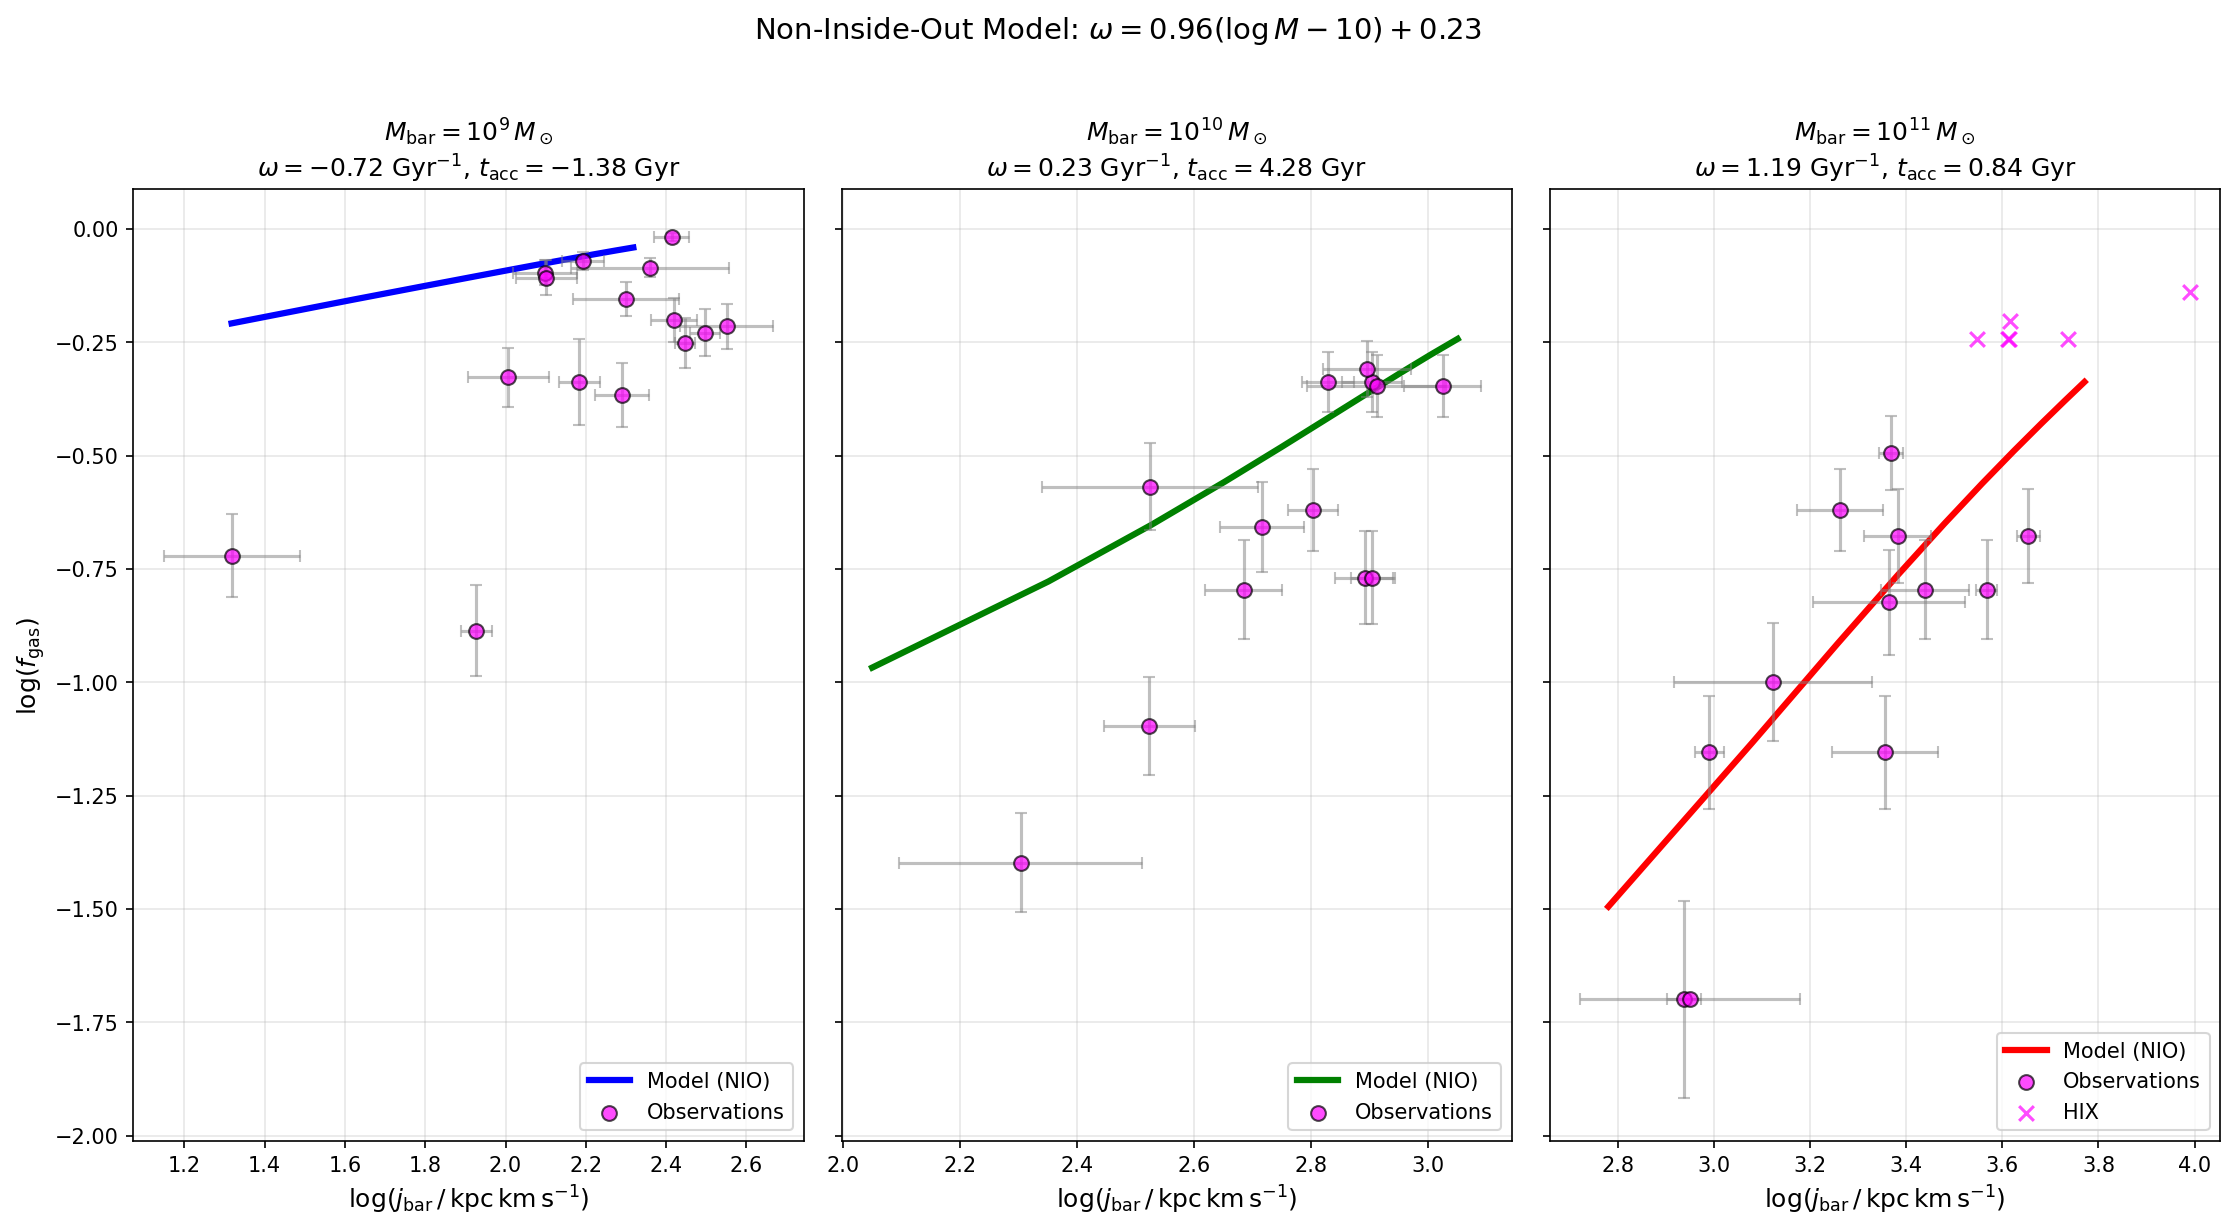

Execution time: 11.4038 seconds


In [25]:
BARY_9 = pd.read_csv('../data/baryons_9.csv')
BARY_10 = pd.read_csv('../data/baryons_10.csv')
BARY_11 = pd.read_csv('../data/baryons_11.csv')

for df in [BARY_9, BARY_10, BARY_11]:
    df['j'] = pd.to_numeric(df['j'], errors='coerce')
    df['e_j'] = pd.to_numeric(df['e_j'], errors='coerce')
    df['fgas'] = pd.to_numeric(df['fgas'], errors='coerce')
    df['e_fgas'] = pd.to_numeric(df['e_fgas'], errors='coerce')

# Compute model curves for each fixed mass
masses = [9, 10, 11]
n_j = 10
model_profiles = {}
HIX_indices_11 = np.where((HIX_data['logMbar'] >= 10.8) & (HIX_data['logMbar'] <= 11.2))[0]

for logM in masses:
    Mbar = 10.0**logM
    
    j_max = j_maxer(Mbar)
    j_min = j_max / 10.0
    j_acc_array = np.linspace(j_min, j_max, n_j)
    
    # Convert j_acc to r_acc using r_btfr_def
    r_acc_array_kpc = np.array([r_btfr_def(Mbar, j) for j in j_acc_array])
    r_acc_array_pc = jnp.array(r_acc_array_kpc * 1000.0, dtype=jnp.float64)
    
    f_gas, j_bar, j_gas, j_star, M_star, M_gas = Full_final_definer_Mdep_omega_jax(
        float(logM), a_median, b_median, r_acc_array_pc, 
        star_formation_law="cutoff_ksl", at_t0=True
    )
    
    # Store results (convert to numpy)
    model_profiles[logM] = {
        'j_acc': np.array(j_acc_array),
        'j_bar': np.array(j_bar),
        'f_gas': np.array(f_gas),
        'j_gas': np.array(j_gas),
        'j_star': np.array(j_star),
        'M_star': np.array(M_star),
        'M_gas': np.array(M_gas),
    }
    
    # Save as CSV
    df_save = pd.DataFrame({
        'j_acc_kpc_km_s': model_profiles[logM]['j_acc'],
        'j_bar_kpc_km_s': model_profiles[logM]['j_bar'],
        'f_gas': model_profiles[logM]['f_gas'],
        'j_gas_kpc_km_s': model_profiles[logM]['j_gas'],
        'j_star_kpc_km_s': model_profiles[logM]['j_star'],
    })
    df_save.to_csv(f'../outputs/jbar_fgas_profiles/nio/jbar_fgas_logM{logM}.csv', index=False)
    
    omega_val = omega_Mdep(logM, a_median, b_median)
    t_acc_val = 1.0/omega_val if abs(omega_val) > 1e-4 else np.inf
    print(f"logM={logM}: omega={float(omega_val):.3f} Gyr^-1, t_acc={float(t_acc_val):.2f} Gyr")
    print(f"  j_bar range: [{model_profiles[logM]['j_bar'].min():.1f}, {model_profiles[logM]['j_bar'].max():.1f}] kpc km/s")
    print(f"  f_gas range: [{model_profiles[logM]['f_gas'].min():.3f}, {model_profiles[logM]['f_gas'].max():.3f}]")

# ── Also save fine-mass NIO profiles spanning each bin (for the comparison-mosaic bands) ──
# Additive: same j_acc-sweep model call as above, evaluated on a fine mass grid that
# covers [logM, logM+0.5] for each panel mass, so the comparison notebook can draw
# a model band matching the central line.
band_dir = '../outputs/jbar_fgas_profiles/nio/band/'
os.makedirs(band_dir, exist_ok=True)
# Bins must match the comparison-notebook mosaic (compare_radial_profiles.ipynb).
band_bins = [(9.0, 9.5), (9.7, 10.3), (10.8, 11.2)]
band_masses = np.round(np.unique(np.concatenate(
    [np.arange(a, b + 1e-9, 0.05) for a, b in band_bins])), 4)
for logM_b in band_masses:
    Mbar_b = 10.0**float(logM_b)
    j_max_b = j_maxer(Mbar_b)
    j_acc_b = np.linspace(j_max_b / 10.0, j_max_b, n_j)
    r_acc_b_pc = jnp.array(np.array([r_btfr_def(Mbar_b, j) for j in j_acc_b]) * 1000.0,
                           dtype=jnp.float64)
    f_gas_b, j_bar_b, j_gas_b, j_star_b, _, _ = Full_final_definer_Mdep_omega_jax(
        float(logM_b), a_median, b_median, r_acc_b_pc,
        star_formation_law="cutoff_ksl", at_t0=True)
    pd.DataFrame({
        'j_acc_kpc_km_s': np.array(j_acc_b),
        'j_bar_kpc_km_s': np.array(j_bar_b),
        'f_gas': np.array(f_gas_b),
        'j_gas_kpc_km_s': np.array(j_gas_b),
        'j_star_kpc_km_s': np.array(j_star_b),
    }).to_csv(band_dir + f'jbar_fgas_logM{float(logM_b):.4f}.csv', index=False)
print(f"Saved {len(band_masses)} fine-mass band profiles to {band_dir}")

# Create mosaic plot
fig, axes = plt.subplots(1, 3, figsize=(15, 8), dpi=150, sharey=True)

obs_data = {9: BARY_9, 10: BARY_10, 11: BARY_11}
colors = {9: 'blue', 10: 'green', 11: 'red'}

for i, logM in enumerate(masses):
    ax = axes[i]
    
    # Model curve
    j_bar_model = model_profiles[logM]['j_bar']
    f_gas_model = model_profiles[logM]['f_gas']
    
    # Filter valid model points (f_gas > 0 and < 1)
    valid = (f_gas_model > 0.01) & (f_gas_model < 0.99)
    
    ax.plot(np.log10(j_bar_model[valid]), np.log10(f_gas_model[valid]), 
            color=colors[logM], lw=3, label='Model (NIO)')
    
    # Observed data
    df_obs = obs_data[logM]
    obs_j = np.log10(df_obs['j'].values)
    obs_f = np.log10(df_obs['fgas'].values)
    obs_j_err = df_obs['e_j'].values / df_obs['j'].values / np.log(10)
    obs_f_err = df_obs['e_fgas'].values / df_obs['fgas'].values / np.log(10)
    
    ax.scatter(obs_j, obs_f, c='magenta', s=50, edgecolors='k', 
               alpha=0.7, zorder=5, label='Observations')
    ax.errorbar(obs_j, obs_f, xerr=obs_j_err, yerr=obs_f_err,
                fmt=' ', ecolor='grey', capsize=3, alpha=0.5, zorder=4)
    
    omega_val = float(omega_Mdep(logM, a_median, b_median))
    t_acc_val = 1.0/omega_val if abs(omega_val) > 1e-4 else np.inf
    if logM == 11:
        hix_j = HIX_data['logjbar'].iloc[HIX_indices_11].values
        hix_f = HIX_data['fgas'].iloc[HIX_indices_11].values
        # hix_j_err = 0.13*(10**hix_j) / np.log(10)
        # hix_f_err = 0.21*hix_f
        
        ax.scatter(hix_j, np.log10(hix_f), c='magenta', s=50, edgecolors='k',
                   alpha=0.7, zorder=5, marker='x', label='HIX')
        # ax.errorbar(hix_j, hix_f, xerr=hix_j_err, yerr=hix_f_err,
        #             fmt=' ', ecolor='grey', capsize=3, alpha=0.5, zorder=4)
    
    ax.set_title(rf'$M_{{\rm bar}} = 10^{{{logM}}} \, M_\odot$' + '\n' + 
                 rf'$\omega = {omega_val:.2f}$ Gyr$^{{-1}}$, $t_{{\rm acc}} = {t_acc_val:.2f}$ Gyr',
                 fontsize=12)
    ax.set_xlabel(r'$\log(j_{\rm bar} \, / \, {\rm kpc \, km \, s^{-1}})$', fontsize=12)
    if i == 0:
        ax.set_ylabel(r'$\log(f_{\rm gas})$', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    # ax.set_xlim(0.5, 4.0)
    # ax.set_ylim(-2.0, 0.1)

plt.suptitle(rf'Non-Inside-Out Model: $\omega = {a_median:.2f}(\log M - 10) + {b_median:.2f}$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/jbar_fgas_profiles/nio/jbar_vs_fgas_mosaic.pdf', dpi=300, bbox_inches='tight')
plt.show()

# print(f"\nSaved profiles to ../outputs/jbar_fgas_profiles/nio/")

M_bar = 10^10.75 Msun, j_bar = 1584.9 kpc km/s, r_acc = 4.36 kpc


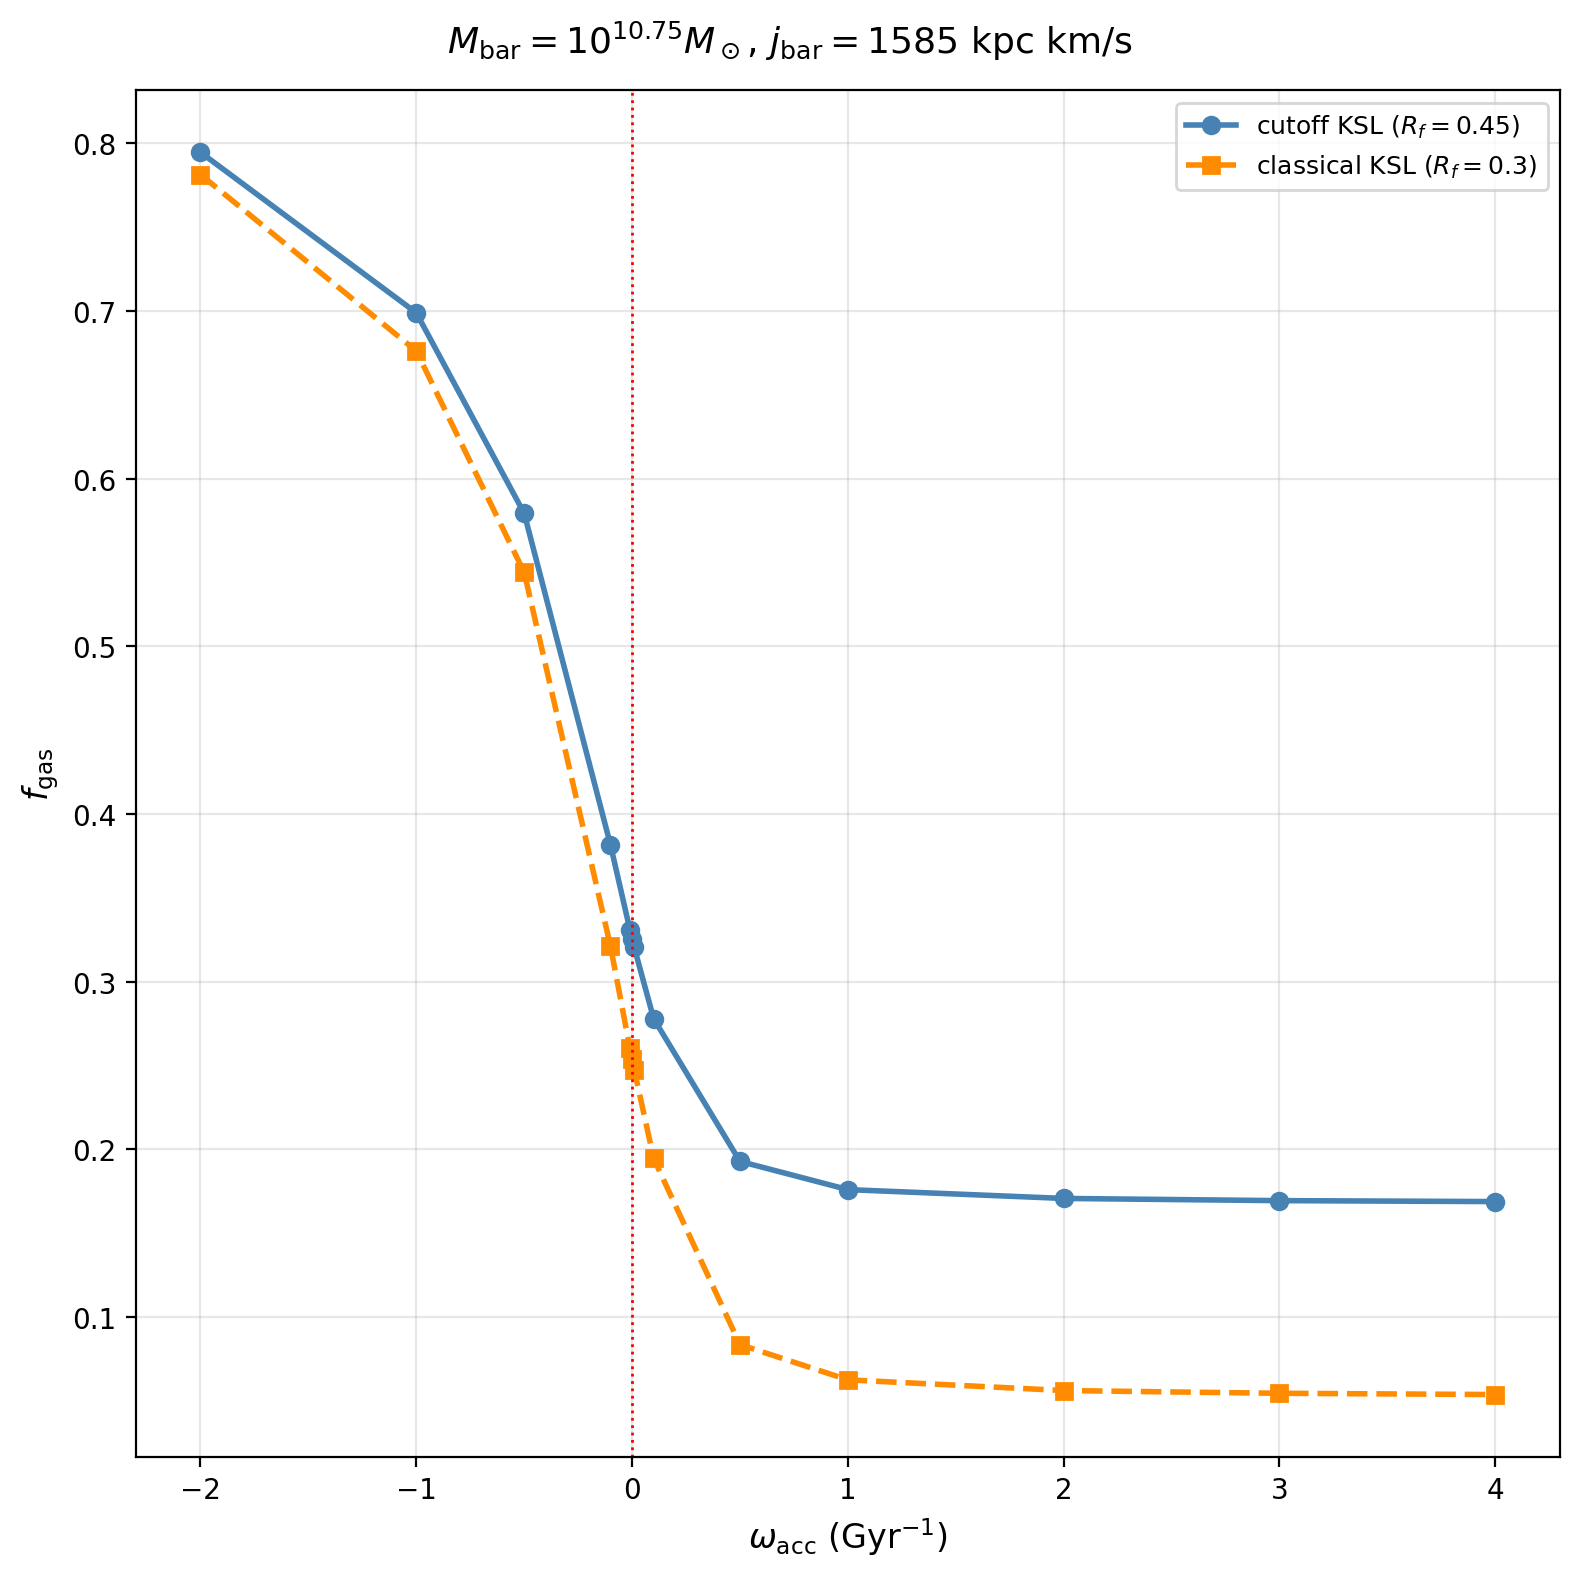

Execution time: 2.3634 seconds


In [26]:
logM_test = 10.75
Mbar_test = 10.0**logM_test

j_bar_test = 10**3.2

r_acc_kpc = r_btfr_def(Mbar_test, j_bar_test)
r_acc_pc = r_acc_kpc * 1000.0

print(f"M_bar = 10^{logM_test} Msun, j_bar = {j_bar_test:.1f} kpc km/s, r_acc = {r_acc_kpc:.2f} kpc")

omega_values = np.array([-2, -1, -0.5, -0.1, -0.01, 0, 0.01, 0.1, 0.5, 1, 2, 3, 4])
r_pc = jnp.arange(0.0, 1000.0*100.1, 120, dtype=jnp.float64)
r_acc_array_pc = jnp.array([r_acc_pc], dtype=jnp.float64)

def obs_curves(sfl, Rf):
    fg, jg, js = [], [], []
    for omega in omega_values:
        t_acc = np.inf if omega == 0 else 1.0 / omega
        C_val = C_def_jax(Mbar_test, t_acc)
        SD_gas = Sigma_definer_static_racc_jax(
            r_pc, t_acc, Mbar_test, float(C_val), sfl, r_acc_array_pc, Rf=Rf
        )
        f_gas, _, j_gas, j_star, _, _ = full_from_sigma_jax(
            SD_gas, Mbar_test, r_pc, dt, sfl, at_t0=True
        )
        fg.append(float(f_gas[0]))
        jg.append(float(j_gas[0]))
        js.append(float(j_star[0]))
    return np.array(fg), np.array(jg), np.array(js)

fg_cut, jg_cut, js_cut = obs_curves("cutoff_ksl", Rf=0.45)
fg_old, jg_old, js_old = obs_curves("old_ksl",    Rf=0.3)

fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=200)

# ax = axes[0]
ax.plot(omega_values, fg_cut, 'o-',  lw=2, ms=6, color='steelblue',  label=r'cutoff KSL ($R_f=0.45$)')
ax.plot(omega_values, fg_old, 's--', lw=2, ms=6, color='darkorange', label=r'classical KSL ($R_f=0.3$)')
ax.axvline(0, color='red', ls=':', lw=1.0)
ax.set_xlabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=12)
ax.set_ylabel(r'$f_{\rm gas}$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ax = axes[1]
# ax.plot(omega_values, jg_cut, 'o-',  lw=2, ms=6, color='steelblue')
# ax.plot(omega_values, jg_old, 's--', lw=2, ms=6, color='darkorange')
# ax.axvline(0, color='red', ls=':', lw=1.0)
# ax.set_yscale('log')
# ax.set_xlabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=12)
# ax.set_ylabel(r'$j_{\rm gas}$ (kpc km s$^{-1}$)', fontsize=12)
# ax.grid(alpha=0.3, which='both')

# ax = axes[2]
# ax.plot(omega_values, js_cut, 'o-',  lw=2, ms=6, color='steelblue')
# ax.plot(omega_values, js_old, 's--', lw=2, ms=6, color='darkorange')
# ax.axvline(0, color='red', ls=':', lw=1.0)
# ax.set_yscale('log')
# ax.set_xlabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=12)
# ax.set_ylabel(r'$j_{\star}$ (kpc km s$^{-1}$)', fontsize=12)
# ax.grid(alpha=0.3, which='both')

fig.suptitle(rf'$M_{{\rm bar}} = 10^{{{logM_test}}} M_\odot$, $j_{{\rm bar}} = {j_bar_test:.0f}$ kpc km/s', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/jbar_fgas_profiles/nio/diagnostic_observables_vs_omega.pdf', dpi=300)
plt.show()


In [27]:
def compute_fgas_for_galaxy(logM, j_bar_obs, b, a=0.0):
    """Compute model f_gas for a single galaxy."""
    Mbar = 10.0**logM
    r_acc_kpc = r_btfr_def(Mbar, j_bar_obs)
    r_acc_pc = r_acc_kpc * 1000.0
    r_acc_array = jnp.array([r_acc_pc], dtype=jnp.float64)
    
    f_gas, _, _, _, _, _ = Full_final_definer_Mdep_omega_jax(
        logM, a, b, r_acc_array, star_formation_law="cutoff_ksl", at_t0=True
    )
    return float(f_gas[0])

# MCMC with a=0 (only b free) to investigate residuals by mass
def log_posterior_a0(theta, logM_obs_array, jbar_obs_array,
                     Mgas_obs_array, sigma_Mgas_array,
                     Mstar_obs_array, sigma_Mstar_array,
                     jgas_obs_array, sigma_jgas_array,
                     jstar_obs_array, sigma_jstar_array,
                     sfl_type, b_min=-1.5, b_max=3.0):
    b = theta[0]
    if not (b_min < b < b_max):
        return -np.inf
    ll = logL_4obs_all_galaxies(
        0.0, b, logM_obs_array, jbar_obs_array,
        Mgas_obs_array, sigma_Mgas_array,
        Mstar_obs_array, sigma_Mstar_array,
        jgas_obs_array, sigma_jgas_array,
        jstar_obs_array, sigma_jstar_array,
        sfl_type=sfl_type
    )
    return ll

Execution time: 0.0014 seconds


In [ ]:
n_walkers_a0 = 10
n_steps_a0 = 100

backend_a0 = emcee.backends.HDFBackend('../outputs/mcmc_chains/chain_mcmc_noninsideout_a0.h5')
backend_a0.reset(n_walkers_a0, 1)

pos_a0 = np.array([[1.5]]) + 0.1 * np.random.randn(n_walkers_a0, 1)
pos_a0[:, 0] = np.clip(pos_a0[:, 0], -1.49, 2.99)

executor = get_reusable_executor(max_workers=12, initializer=init_worker)
sampler_a0 = emcee.EnsembleSampler(
    n_walkers_a0, 1, log_posterior_a0,
    args=(logM_obs_mcmc, jbar_obs_mcmc,
          Mgas_obs_mcmc, Mgas_errors_mcmc,
          Mstar_obs_mcmc, Mstar_errors_mcmc,
          jgas_obs_mcmc, jgas_errors_mcmc,
          jstar_obs_mcmc, jstar_errors_mcmc,
          "cutoff_ksl"),
    pool=executor, backend=backend_a0
)
sampler_a0.run_mcmc(pos_a0, n_steps_a0, progress=True)


100%|██████████| 100/100 [06:41<00:00,  4.02s/it]


State([[2.85213411]
 [2.93925191]
 [2.79813031]
 [2.69160487]
 [2.90640291]
 [2.97832478]
 [2.7582842 ]
 [2.65700541]
 [2.82227766]
 [2.82916611]], log_prob=[-1309.90146731 -1309.55079032 -1310.13361577 -1310.6404853
 -1309.68033716 -1309.40139668 -1310.31631048 -1310.81649197
 -1310.02782929 -1309.99833291], blobs=None, random_state=('MT19937', array([2770722076, 1096601598, 2762277153, 3213030424, 2386647906,
        239253370, 3813432218, 2067670342, 2173509844, 3677167011,
       1008628134, 2960080027, 4157088319, 1432890013, 3151815622,
       2017319998, 3932548187, 3595876509, 3850766670, 3479836852,
       1406701342, 2501784650, 1386409603, 1409431612, 1416989622,
        372130630, 1629181488, 4085302678, 4193576975, 3820963399,
       4254623093, 2542656288,  791474274, 1880202633, 4006493873,
       1228827529, 1065011251, 2958862133, 2894982972, 1514338477,
        979609467,   25747133, 2694981892,  854197605, 2371819474,
       3726375944, 3698464968,  915925771, 167618

Execution time: 406.2500 seconds


In [29]:
# Analyze
flat_a0 = sampler_a0.get_chain(discard=25, flat=True)
b_mcmc_16, b_mcmc_50, b_mcmc_84 = np.percentile(flat_a0[:, 0], [16, 50, 84])
b_best_a0 = b_mcmc_50
print(f"MCMC best-fit b (a=0): {b_best_a0:.4f} (+{b_mcmc_84-b_mcmc_50:.4f}, -{b_mcmc_50-b_mcmc_16:.4f}) Gyr^-1")

# Compute residuals using MCMC best-fit b
residuals_a0 = []
chi_a0 = []
f_gas_mod_a0 = []

for i in range(len(logM_obs_mcmc)):
    f_mod = compute_fgas_for_galaxy(logM_obs_mcmc[i], jbar_obs_mcmc[i], b_best_a0, a=0.0)
    f_gas_mod_a0.append(f_mod)
    residuals_a0.append(f_mod / fgas_obs_mcmc[i] - 1)
    chi_a0.append((f_mod - fgas_obs_mcmc[i]) / fgas_errors_mcmc[i])

residuals_a0 = np.array(residuals_a0)
f_gas_mod_a0 = np.array(f_gas_mod_a0)
chi_a0 = np.array(chi_a0)


MCMC best-fit b (a=0): 2.7896 (+0.1533, -0.2934) Gyr^-1
Execution time: 1.7655 seconds


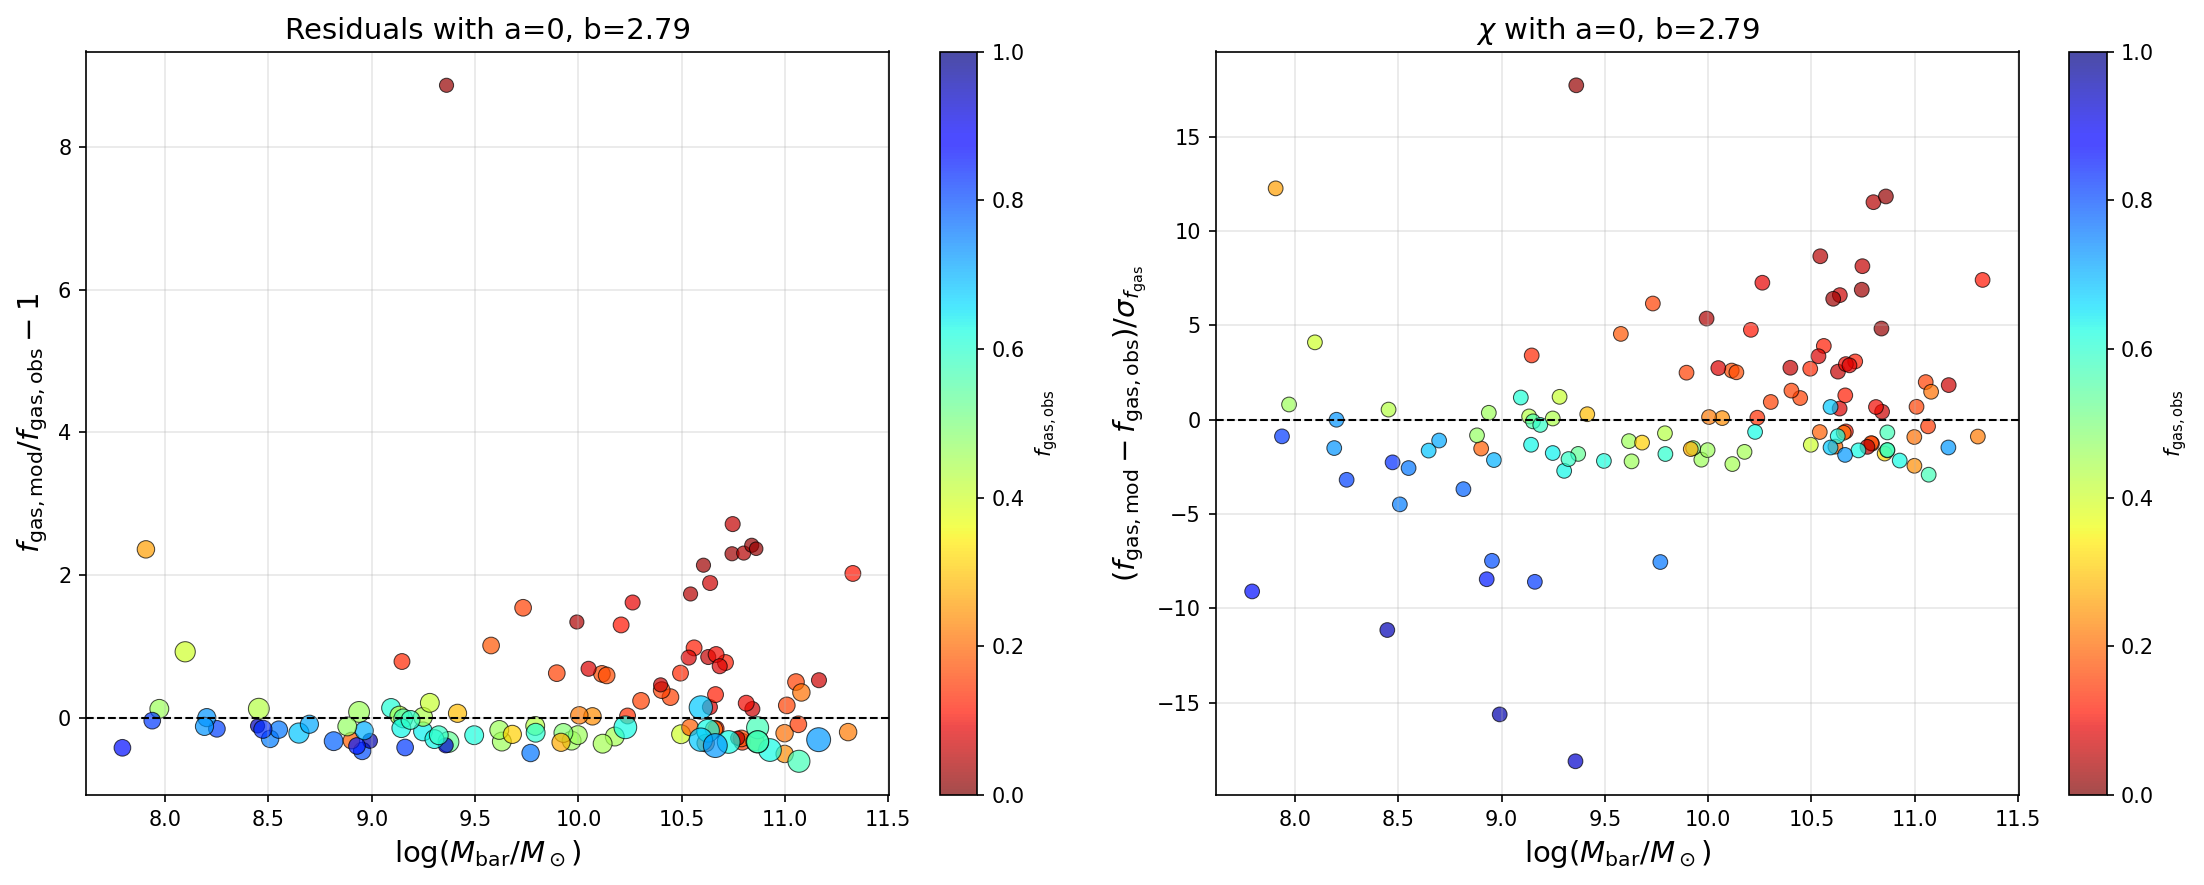

Execution time: 0.3075 seconds


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)

ax1 = axes[0]
valid = np.isfinite(residuals_a0)
sc = ax1.scatter(logM_obs_mcmc[valid], residuals_a0[valid], c=fgas_obs_mcmc[valid], 
                  cmap='jet_r', s=fgas_errors_mcmc[valid]*600+40, alpha=0.7, edgecolors='k', 
                  linewidths=0.5, vmin=0.0, vmax=1.0)
ax1.axhline(0, color='k', ls='--', lw=1)
ax1.set_xlabel(r'$\log(M_{\rm bar}/M_\odot)$', fontsize=14)
ax1.set_ylabel(r'$f_{\rm gas,mod}/f_{\rm gas,obs} - 1$', fontsize=14)
ax1.set_title(f'Residuals with a=0, b={b_best_a0:.2f}', fontsize=14)
cbar = fig.colorbar(sc, ax=ax1, label=r'$f_{\rm gas,obs}$')
ax1.grid(alpha=0.3)

ax2 = axes[1]
sc = ax2.scatter(logM_obs_mcmc[valid], chi_a0[valid], c=fgas_obs_mcmc[valid], 
                  cmap='jet_r', s=50, alpha=0.7, edgecolors='k', 
                  linewidths=0.5, vmin=0.0, vmax=1.0)
ax2.axhline(0, color='k', ls='--', lw=1)
ax2.set_xlabel(r'$\log(M_{\rm bar}/M_\odot)$', fontsize=14)
ax2.set_ylabel(r'$(f_{\rm gas,mod} - f_{\rm gas,obs}) / \sigma_{f_{\rm gas}}$', fontsize=14)
ax2.set_title(rf'${{\chi}}$ with a=0, b={b_best_a0:.2f}', fontsize=14)
cbar = fig.colorbar(sc, ax=ax2, label=r'$f_{\rm gas,obs}$')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/jbar_fgas_profiles/nio/residuals_a0.pdf', dpi=300)


In [31]:
# Same residual analysis but with both a and b free (from MCMC)
a_best = a_median
b_best = b_median
print(f"MCMC best-fit a: {a_best:.4f} Gyr^-1/dex")
print(f"MCMC best-fit b: {b_best:.4f} Gyr^-1")

# Compute residuals and model values for MCMC best-fit parameters
residuals_ab = []
chi_ab = []
f_gas_mod_ab = []

for i in range(len(logM_obs_mcmc)):
    f_mod = compute_fgas_for_galaxy(logM_obs_mcmc[i], jbar_obs_mcmc[i], b_best, a=a_best)
    f_gas_mod_ab.append(f_mod)
    residuals_ab.append(f_mod / fgas_obs_mcmc[i] - 1)
    chi_ab.append((f_mod - fgas_obs_mcmc[i]) / fgas_errors_mcmc[i])

residuals_ab = np.array(residuals_ab)
f_gas_mod_ab = np.array(f_gas_mod_ab)
chi_ab = np.array(chi_ab)


MCMC best-fit a: 2.1087 Gyr^-1/dex
MCMC best-fit b: 2.1501 Gyr^-1
Execution time: 1.5630 seconds


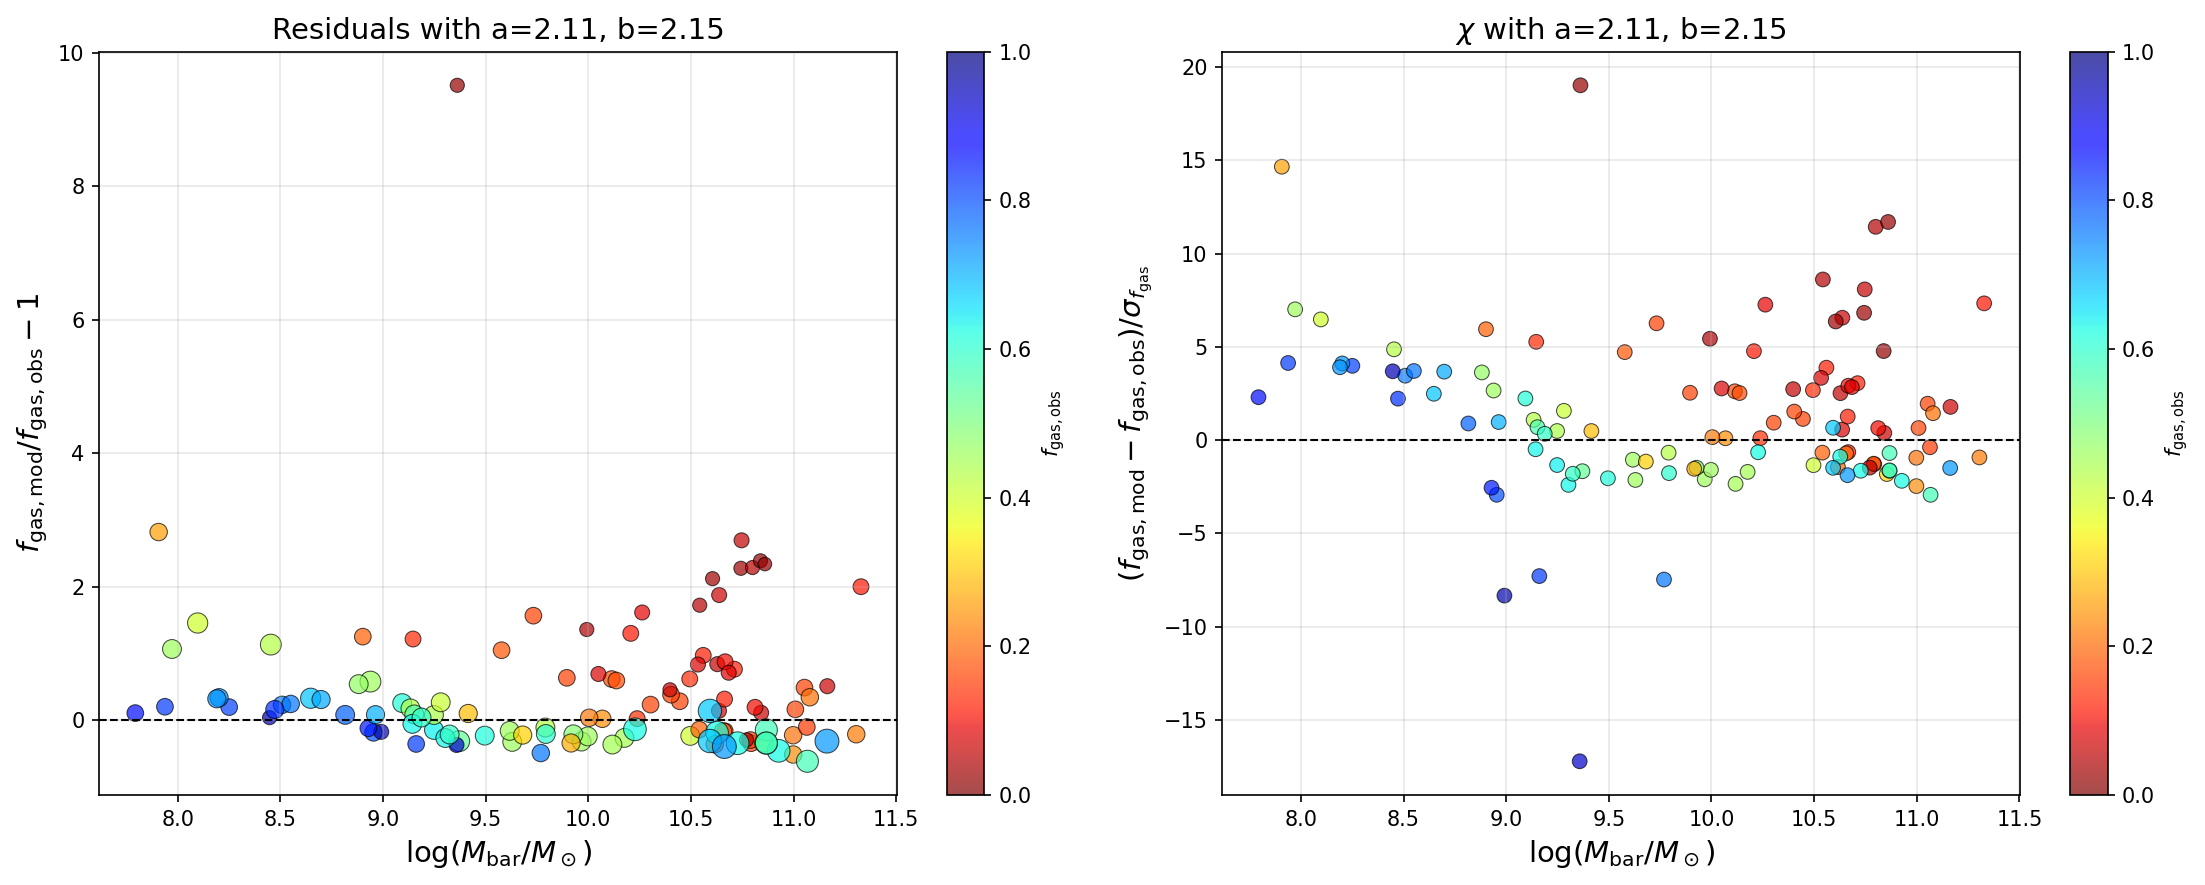

Execution time: 0.3011 seconds


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)

ax1 = axes[0]
valid = np.isfinite(residuals_ab)
sc = ax1.scatter(logM_obs_mcmc[valid], residuals_ab[valid], c=fgas_obs_mcmc[valid], 
                  cmap='jet_r', s=fgas_errors_mcmc[valid]*600+40, alpha=0.7, edgecolors='k', 
                  linewidths=0.5, vmin=0.0, vmax=1.0)
ax1.axhline(0, color='k', ls='--', lw=1)
ax1.set_xlabel(r'$\log(M_{\rm bar}/M_\odot)$', fontsize=14)
ax1.set_ylabel(r'$f_{\rm gas,mod}/f_{\rm gas,obs} - 1$', fontsize=14)
ax1.set_title(f'Residuals with a={a_best:.2f}, b={b_best:.2f}', fontsize=14)
cbar = fig.colorbar(sc, ax=ax1, label=r'$f_{\rm gas,obs}$')
ax1.grid(alpha=0.3)

ax2 = axes[1]
sc = ax2.scatter(logM_obs_mcmc[valid], chi_ab[valid], c=fgas_obs_mcmc[valid], 
                  cmap='jet_r', s=50, alpha=0.7, edgecolors='k', 
                  linewidths=0.5, vmin=0.0, vmax=1.0)
ax2.axhline(0, color='k', ls='--', lw=1)
ax2.set_xlabel(r'$\log(M_{\rm bar}/M_\odot)$', fontsize=14)
ax2.set_ylabel(r'$(f_{\rm gas,mod} - f_{\rm gas,obs}) / \sigma_{f_{\rm gas}}$', fontsize=14)
ax2.set_title(rf'${{\chi}}$ with a={a_best:.2f}, b={b_best:.2f}', fontsize=14)
cbar = fig.colorbar(sc, ax=ax2, label=r'$f_{\rm gas,obs}$')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/jbar_fgas_profiles/nio/residuals_ab.pdf', dpi=300)


## Per-mass-bin ω fit

In [29]:
mass_bins_nio = np.arange(8, 12, 0.5)
n_bins_nio = len(mass_bins_nio) - 1
bin_centers_nio = 0.5 * (mass_bins_nio[:-1] + mass_bins_nio[1:])

omega_grid = np.linspace(-5.0, 15.0, 500) # ω scan range

logL_per_bin    = np.full((n_bins_nio, len(omega_grid)), -np.inf)
n_gal_per_bin   = np.zeros(n_bins_nio, dtype=int)
omega_best_bin  = np.full(n_bins_nio, np.nan)
omega_lo_bin    = np.full(n_bins_nio, np.nan)
omega_hi_bin    = np.full(n_bins_nio, np.nan)

def _scan_omega_for_bin(i):
    mass_mask = (logM_obs_mcmc >= mass_bins_nio[i]) & (logM_obs_mcmc < mass_bins_nio[i+1])
    n_in = int(mass_mask.sum())
    if n_in == 0:
        return i, n_in, np.full(len(omega_grid), -np.inf)
    logL_row = np.empty(len(omega_grid))
    for j, omega in enumerate(omega_grid):
        logL_row[j] = float(logL_4obs_all_galaxies(
            0.0, float(omega),
            logM_obs_mcmc[mass_mask],   jbar_obs_mcmc[mass_mask],
            Mgas_obs_mcmc[mass_mask],   Mgas_errors_mcmc[mass_mask],
            Mstar_obs_mcmc[mass_mask],  Mstar_errors_mcmc[mass_mask],
            jgas_obs_mcmc[mass_mask],   jgas_errors_mcmc[mass_mask],
            jstar_obs_mcmc[mass_mask],  jstar_errors_mcmc[mass_mask],
            sfl_type='cutoff_ksl'
        ))
    return i, n_in, logL_row

executor = get_reusable_executor(max_workers=min(n_bins_nio, 12), initializer=init_worker)
results = list(executor.map(_scan_omega_for_bin, range(n_bins_nio)))

print(f"{'Bin (logM)':<14s} {'N':>4s} {'omega_best':>12s} {'1sigma':>20s}")
for i, n_in, row in results:
    n_gal_per_bin[i] = n_in
    logL_per_bin[i] = row
    if n_in == 0:
        print(f"[{mass_bins_nio[i]:.1f}, {mass_bins_nio[i+1]:.1f})  {n_in:>4d}  (no galaxies)")
        continue
    
    j_max = int(np.argmax(row))
    omega_best_bin[i] = omega_grid[j_max]
    threshold = row[j_max] - 0.5
    # left/right 1sigma
    left = j_max
    while left > 0 and row[left] >= threshold:
        left -= 1
    right = j_max
    while right < len(omega_grid) - 1 and row[right] >= threshold:
        right += 1
    omega_lo_bin[i] = omega_grid[left]
    omega_hi_bin[i] = omega_grid[right]
    print(f"[{mass_bins_nio[i]:.1f}, {mass_bins_nio[i+1]:.1f})  {n_in:>4d}  {omega_best_bin[i]:>+12.3f}  [{omega_lo_bin[i]:+.2f}, {omega_hi_bin[i]:+.2f}]")


Bin (logM)        N   omega_best               1sigma
[8.0, 8.5)     2        +0.331  [+0.17, +0.65]
[8.5, 9.0)     9        -0.311  [-0.43, -0.23]
[9.0, 9.5)    14        -1.473  [-1.79, -1.31]
[9.5, 10.0)    11        +0.130  [+0.05, +0.17]
[10.0, 10.5)    10        +0.371  [+0.29, +0.49]
[10.5, 11.0)    34        +0.611  [+0.53, +0.69]
[11.0, 11.5)     7        +0.251  [+0.17, +0.33]
Execution time: 678.6489 seconds


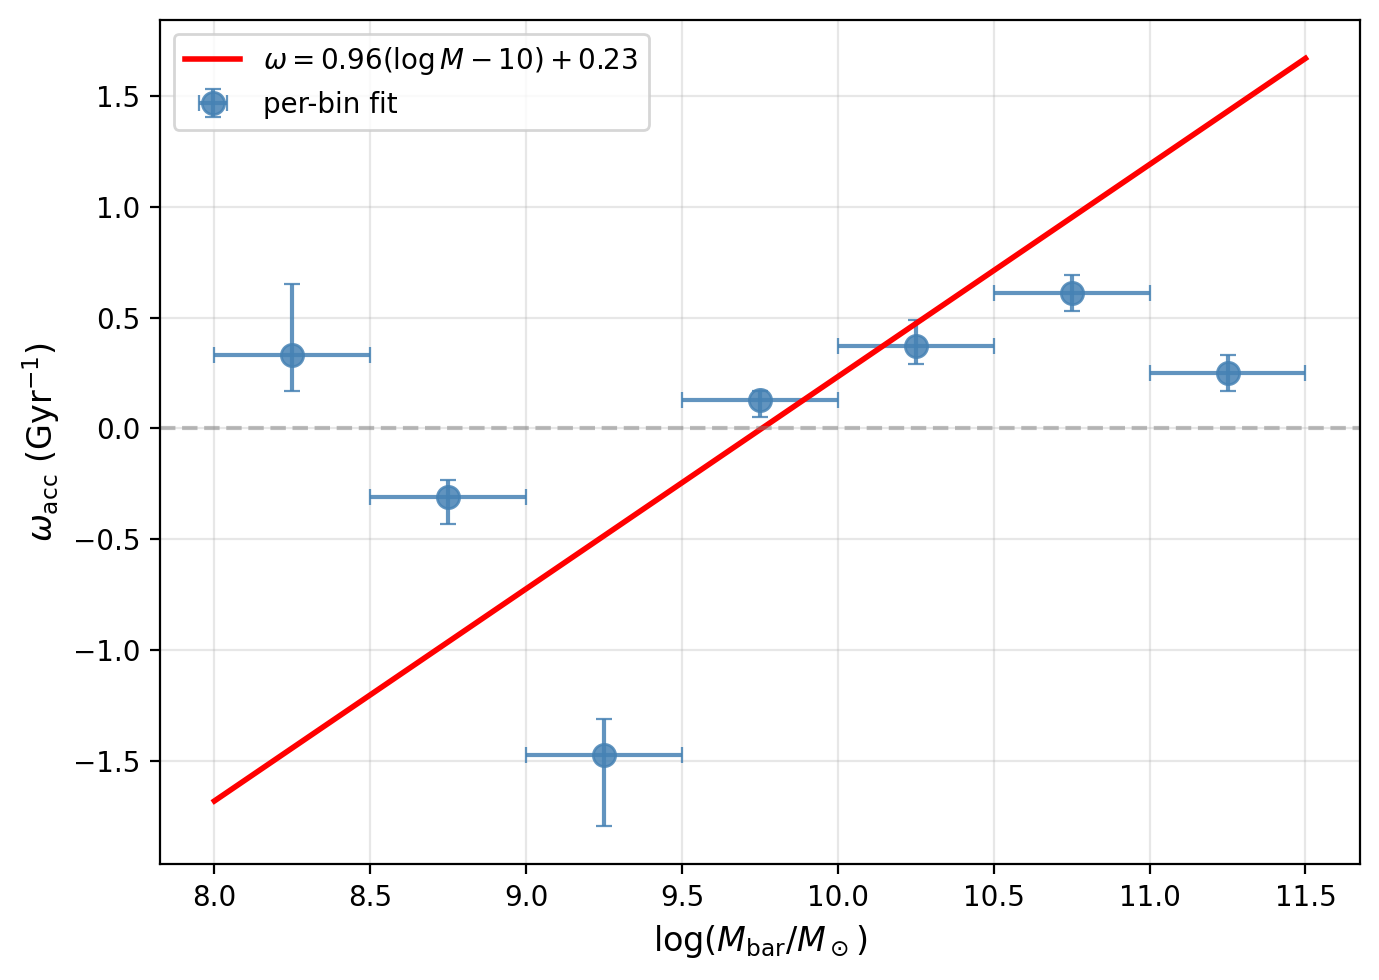

Execution time: 0.1133 seconds


In [30]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)

valid = n_gal_per_bin > 0
yerr_lo = omega_best_bin - omega_lo_bin
yerr_hi = omega_hi_bin - omega_best_bin

ax.errorbar(bin_centers_nio[valid], omega_best_bin[valid],
            xerr=np.full(valid.sum(), 0.25),
            yerr=[yerr_lo[valid], yerr_hi[valid]],
            fmt='o', capsize=3, capthick=0.8, markersize=8,
            color='steelblue', ecolor='steelblue', alpha=0.85,
            label='per-bin fit')

logM_line = np.linspace(mass_bins_nio[0], mass_bins_nio[-1], 50)
omega_linear = a_median * (logM_line - 10.0) + b_median
ax.plot(logM_line, omega_linear, 'r-', lw=2,
        label=rf'$\omega = {a_median:.2f}(\log M - 10) + {b_median:.2f}$')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\log(M_{\rm bar} / M_\odot)$', fontsize=12)
ax.set_ylabel(r'$\omega_{\rm acc}$ (Gyr$^{-1}$)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)
# ax.set_title('Per-bin ω fit vs global linear assumption (NIO)', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# ====== Experiment (i): per-bin omega fit on the FULL j_bar sample (BARY + HIX) ======
# Likelihood: f_gas-only (4-obs LL needs Mgas/Mstar/jgas/jstar, only full for CONVERGED).

def logL_fgas_single_galaxy(logM_obs, j_bar_obs, fgas_obs, sigma_fgas, b, a=0.0):
    f_mod = compute_fgas_for_galaxy(logM_obs, j_bar_obs, b, a)
    if not np.isfinite(f_mod) or f_mod <= 0 or f_mod >= 1:
        return -1e6
    return -0.5 * ((f_mod - fgas_obs) / max(sigma_fgas, 1e-6)) ** 2

def logL_fgas_all_galaxies(a, b, logM_obs_array, jbar_obs_array,
                           fgas_obs_array, sigma_fgas_array):
    total = 0.0
    for i in range(len(logM_obs_array)):
        total += logL_fgas_single_galaxy(
            logM_obs_array[i], jbar_obs_array[i],
            fgas_obs_array[i], sigma_fgas_array[i], b, a)
    return total

# --- Build the 105 BARY galaxies (gas <- gasses.csv, stars <- stars.csv/Pavel+25) ---
# Rule: update a galaxy only if it has a Pavel+25 stellar update or Geesink+25 H2 data.
#   - 77 CONVERGED galaxies: use the existing CONVERGED values (already carry the
#     Pavel+25 / Geesink-H2 / helium corrections).
#   - 28 non-CONVERGED galaxies: keep the raw baryons1.csv values, EXCEPT recompute
#     Mbar/fgas/jbar for a galaxy that (a) is in Pavel+25 or Geesink+25, AND (b) has
#     the components available -- Mgas from gasses.csv, Mstar from stars.csv or
#     Pavel+25. galaxies_total_sample.csv is NOT used anywhere.
_conv_set = set(CONVERGED['Name'])

Mbar_p1   = CONVERGED['Mbar'].values.astype(float)
e_Mbar_p1 = CONVERGED['e_Mbar'].values.astype(float)
jbar_p1   = CONVERGED['jbar'].values.astype(float)
e_jbar_p1 = CONVERGED['e_jbar'].values.astype(float)
fgas_p1   = CONVERGED['fgas'].values.astype(float)
e_fgas_p1 = CONVERGED['e_fgas'].values.astype(float)

_extra   = [n for n in BARY['Name'] if n not in _conv_set]
_bary_i  = BARY.set_index('Name')
_gas_i   = GAS.set_index('Name')
_star_i  = STAR.set_index('Name')
_p25_i   = P25.set_index('Name')
_g25_pos = {_normalize_name(n): i for i, n in enumerate(G25['Name'])}

_Mbar2, _eMbar2, _jbar2, _ejbar2, _fgas2, _efgas2 = [], [], [], [], [], []
_upd_names = []
for nm in _extra:
    b = _bary_i.loc[nm]
    in_p25  = nm in _p25_i.index
    in_g25  = _normalize_name(nm) in _g25_pos
    in_gas  = nm in _gas_i.index
    in_star = nm in _star_i.index
    can_recompute = (in_p25 or in_g25) and in_gas and (in_star or in_p25)
    if not can_recompute:
        _Mbar2.append(float(b['Mass(Msun)'])); _eMbar2.append(float(b['e_Mass(Msun)']))
        _jbar2.append(float(b['j']));          _ejbar2.append(float(b['e_j']))
        _fgas2.append(float(b['fgas']));       _efgas2.append(float(b['e_fgas']))
        continue
    # gas: helium x1.4 on HI mass + Geesink+25 H2 if present
    g = _gas_i.loc[nm]
    M_HI, e_M_HI = float(g['Mass']), float(g['e_Mass'])
    j_HI, e_j_HI = float(g['j']),    float(g['e_j'])
    M_H2 = e_M_H2 = j_H2 = e_j_H2 = 0.0
    if in_g25:
        gr = G25.iloc[_g25_pos[_normalize_name(nm)]]
        M_H2   = 10**gr['log_MH2']
        e_M_H2 = M_H2 * np.log(10) * gr['log_MH2_err']
        j_H2   = 10**gr['log_jH2']
        e_j_H2 = j_H2 * np.log(10) * gr['log_jH2_err']
    D = M_HI + M_H2
    Mgas   = 1.4 * D
    e_Mgas = 1.4 * np.sqrt(e_M_HI**2 + e_M_H2**2)
    jgas   = (M_HI*j_HI + M_H2*j_H2) / D
    e_jgas = (1.0/D) * np.sqrt(
        ((j_HI - jgas)*e_M_HI)**2 + (M_HI*e_j_HI)**2 +
        ((j_H2 - jgas)*e_M_H2)**2 + (M_H2*e_j_H2)**2)
    # stars: Pavel+25 if present, else stars.csv
    if in_p25:
        r = _p25_i.loc[nm]
        Mstar   = 10**r['logMstar']
        e_Mstar = 10**r['logMstar'] * np.log(10) * r['e_logMstar']
        jstar   = float(r['jstar'])
        e_jstar = float(r['e_jstar'])
    else:
        s = _star_i.loc[nm]
        Mstar, e_Mstar = float(s['Mass']), float(s['e_Mass'])
        jstar, e_jstar = float(s['j']),    float(s['e_j'])
    # recompute derived quantities (same formulas as the CONVERGED pipeline)
    Mbar_n   = Mgas + Mstar
    e_Mbar_n = np.sqrt(e_Mgas**2 + e_Mstar**2)
    fgas_n   = Mgas / Mbar_n
    e_fgas_n = np.sqrt((Mstar*e_Mgas)**2 + (Mgas*e_Mstar)**2) / Mbar_n**2
    jbar_n   = (Mgas*jgas + Mstar*jstar) / Mbar_n
    e_jbar_n = (1.0/Mbar_n) * np.sqrt(
        (jgas*e_Mgas)**2 + (Mgas*e_jgas)**2 +
        (jstar*e_Mstar)**2 + (Mstar*e_jstar)**2 + (jbar_n*e_Mbar_n)**2)
    _Mbar2.append(Mbar_n);   _eMbar2.append(e_Mbar_n)
    _jbar2.append(jbar_n);   _ejbar2.append(e_jbar_n)
    _fgas2.append(fgas_n);   _efgas2.append(e_fgas_n)
    _upd_names.append(nm)

print(f"BARY sample: {len(Mbar_p1)} CONVERGED (as-is) + {len(_extra)} extra "
      f"({len(_upd_names)} recomputed, {len(_extra)-len(_upd_names)} kept raw)")
if _upd_names:
    print(f"  recomputed extra galaxies: {_upd_names}")

Mbar_bary        = np.concatenate([Mbar_p1,   np.array(_Mbar2,  dtype=float)])
Mbar_err_bary    = np.concatenate([e_Mbar_p1, np.array(_eMbar2, dtype=float)])
jbar_bary        = np.concatenate([jbar_p1,   np.array(_jbar2,  dtype=float)])
jbar_errors_bary = np.concatenate([e_jbar_p1, np.array(_ejbar2, dtype=float)])
fgas_bary        = np.concatenate([fgas_p1,   np.array(_fgas2,  dtype=float)])
fgas_errors_bary = np.concatenate([e_fgas_p1, np.array(_efgas2, dtype=float)])
logM_bary        = np.log10(Mbar_bary)
n_bary_full      = len(logM_bary)

# --- Append HIX on top ---
logM_obs_bary    = np.concatenate([logM_bary,        hix_logMbar])
jbar_obs_bary    = np.concatenate([jbar_bary,        hix_jbar])
fgas_obs_bary    = np.concatenate([fgas_bary,        hix_fgas])
fgas_errors_bary = np.concatenate([fgas_errors_bary, hix_e_fgas])
n_hix = len(hix_logMbar)
n_tot_bary = len(logM_obs_bary)
print(f"Full scan sample = BARY ({n_bary_full}) + HIX ({n_hix}) = {n_tot_bary} galaxies")

# --- Per-bin omega scan ---
mass_bins_bary   = np.arange(8, 12, 0.5)
n_bins_bary      = len(mass_bins_bary) - 1
bin_centers_bary = 0.5 * (mass_bins_bary[:-1] + mass_bins_bary[1:])
omega_grid_bary  = np.linspace(-5.0, 15.0, 500)

logL_per_bin_bary  = np.full((n_bins_bary, len(omega_grid_bary)), -np.inf)
n_gal_per_bin_bary = np.zeros(n_bins_bary, dtype=int)
omega_best_bary    = np.full(n_bins_bary, np.nan)
omega_lo_bary      = np.full(n_bins_bary, np.nan)
omega_hi_bary      = np.full(n_bins_bary, np.nan)

def _scan_omega_for_bin_bary(i):
    mass_mask = (logM_obs_bary >= mass_bins_bary[i]) & (logM_obs_bary < mass_bins_bary[i+1])
    n_in = int(mass_mask.sum())
    if n_in == 0:
        return i, n_in, np.full(len(omega_grid_bary), -np.inf)
    logL_row = np.empty(len(omega_grid_bary))
    for j, omega in enumerate(omega_grid_bary):
        logL_row[j] = float(logL_fgas_all_galaxies(
            0.0, float(omega),
            logM_obs_bary[mass_mask], jbar_obs_bary[mass_mask],
            fgas_obs_bary[mass_mask], fgas_errors_bary[mass_mask]))
    return i, n_in, logL_row

executor = get_reusable_executor(max_workers=min(n_bins_bary, 12), initializer=init_worker)
results_bary = list(executor.map(_scan_omega_for_bin_bary, range(n_bins_bary)))

print(f"{'Bin (logM)':<14s} {'N':>4s} {'omega_best':>12s} {'1sigma':>20s}")
for i, n_in, row in results_bary:
    n_gal_per_bin_bary[i] = n_in
    logL_per_bin_bary[i]  = row
    if n_in == 0:
        print(f"[{mass_bins_bary[i]:.1f}, {mass_bins_bary[i+1]:.1f})  {n_in:>4d}  (no galaxies)")
        continue
    j_max = int(np.argmax(row))
    omega_best_bary[i] = omega_grid_bary[j_max]
    threshold = row[j_max] - 0.5
    left = j_max
    while left > 0 and row[left] >= threshold:
        left -= 1
    right = j_max
    while right < len(omega_grid_bary) - 1 and row[right] >= threshold:
        right += 1
    omega_lo_bary[i] = omega_grid_bary[left]
    omega_hi_bary[i] = omega_grid_bary[right]
    print(f"[{mass_bins_bary[i]:.1f}, {mass_bins_bary[i+1]:.1f})  {n_in:>4d}  "
          f"{omega_best_bary[i]:>+12.3f}  [{omega_lo_bary[i]:+.2f}, {omega_hi_bary[i]:+.2f}]")

# --- Plot omega vs mass with the global linear-omega MCMC overlay ---
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)
valid = n_gal_per_bin_bary > 0
yerr_lo = omega_best_bary - omega_lo_bary
yerr_hi = omega_hi_bary - omega_best_bary
ax.errorbar(bin_centers_bary[valid], omega_best_bary[valid],
            xerr=np.full(valid.sum(), 0.25), yerr=[yerr_lo[valid], yerr_hi[valid]],
            fmt='o', capsize=3, capthick=0.8, markersize=8,
            color='steelblue', ecolor='steelblue', alpha=0.85,
            label=f'per-bin fit (BARY+HIX, f_gas LL, N={n_tot_bary})')
logM_line = np.linspace(mass_bins_bary[0], mass_bins_bary[-1], 50)
ax.plot(logM_line, a_median * (logM_line - 10.0) + b_median, 'r-', lw=2,
        label=rf'$\omega = {a_median:.2f}(\log M - 10) + {b_median:.2f}$ (global MCMC)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\log_{10}(M_{\rm bar}/M_\odot)$')
ax.set_ylabel(r'$\omega$ [Gyr$^{-1}$]')
ax.set_title('Exp (i): per-bin $\\omega$, BARY+HIX full sample, $f_{\\rm gas}$ likelihood')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# ====== Experiment (i) — baryonic plot for BARY (+ HIX overlay) ======
# Model curves use the GLOBAL linear-omega MCMC medians (a_median, b_median).
log_M_grid_i = np.linspace(8, 11.5, 50)
log_M_bar_array_backup_i = log_M_bar_array.copy()
log_M_bar_array = log_M_grid_i  # modelled_j_bar2 indexes the global log_M_bar_array
print(f"Model curves built at: a = {a_median:.4f}, b = {b_median:.4f}")

r_acc_grid_i = np.zeros((len(log_M_grid_i), 10))
for i_, logM_ in enumerate(log_M_grid_i):
    r_acc_grid_i[i_], _ = build_r_acc_for_single_M(logM_, n_j=10)
r_acc_grid_i_jax = jnp.array(r_acc_grid_i, dtype=jnp.float64)
log_M_grid_i_jax = jnp.array(log_M_grid_i, dtype=jnp.float64)

f_gas_bf_i, j_bar_bf_i, _, _, _, _ = run_all_masses_Mdep_omega_jax(
    log_M_grid_i_jax, a_median, b_median, r_acc_grid_i_jax)
f_gas_bestfit_i     = np.nan_to_num(np.array(f_gas_bf_i), nan=np.nan, posinf=1.0, neginf=0.0)
j_bar_bestfit_i     = np.array(j_bar_bf_i)
log_j_bar_bestfit_i = np.log10(np.where(j_bar_bestfit_i > 0, j_bar_bestfit_i, np.nan))
print(f"Model f_gas range: min = {np.nanmin(f_gas_bestfit_i):.3f}, max = {np.nanmax(f_gas_bestfit_i):.3f}")

n_interp = 1000
interp_f_gas_i = np.zeros((len(log_M_grid_i), n_interp))
interp_j_bar_i = np.zeros((len(log_M_grid_i), n_interp))
for i_ in range(len(log_M_grid_i)):
    f_min_, f_max_ = f_gas_bestfit_i[i_, :].min(), f_gas_bestfit_i[i_, :].max()
    if f_max_ > f_min_:
        interp_f_gas_i[i_] = np.linspace(f_min_, f_max_, n_interp)
        try:
            ipl_ = spl.interp1d(f_gas_bestfit_i[i_, :], log_j_bar_bestfit_i[i_, :],
                                kind='linear', fill_value='extrapolate')
            interp_j_bar_i[i_] = ipl_(interp_f_gas_i[i_])
        except Exception:
            interp_j_bar_i[i_] = np.nan

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8, 8), dpi=400, facecolor='w')
frame = fig.add_subplot(1, 1, 1)
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")
f_gas_values = [0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
colors_ = cmap(f_gas_values)
ax1s = []
for kk, f_gas_value in enumerate(f_gas_values):
    indexed_M, indexed_j = modelled_j_bar2(interp_f_gas_i, interp_j_bar_i, f_gas_value)
    if len(indexed_M) > 0:
        ax1 = frame.plot(indexed_M, indexed_j, label=rf"$f_{{gas}} = {f_gas_value:.2f}$",
                        color=colors_[kk], lw=3.5, zorder=2)
        ax1s.append(ax1[0])

# MP+21 (= BARY) scatter
logM_bary_err = Mbar_err_bary / Mbar_bary / np.log(10.0)
logj_bary_err = jbar_errors_bary / jbar_bary / np.log(10.0)
ax2 = frame.scatter(logM_bary, np.log10(jbar_bary), label="MP+21b", marker="o",
                    facecolors=cmap(fgas_bary), edgecolors="grey", s=70, zorder=9)
frame.errorbar(logM_bary, np.log10(jbar_bary), xerr=logM_bary_err, yerr=logj_bary_err,
               fmt=' ', ecolor='grey', capsize=3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{\rm gas}$", rotation=270, fontsize=15)

marker_map = {'Dwarfs': 'p', 'superthin': 's', 'HIX': 'X', 'superspirals': 'D'}
for kk, (idx, df_) in enumerate(pavel_data.items(), start=3):
    frame.scatter(df_['logMbar'], df_['logjbar'], label=idx, marker=marker_map[idx],
                  facecolors=cmap(df_['fgas'].values.copy()), edgecolors="grey", s=70, zorder=kk)

models_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Models}$")
models_legend_elements = [models_header] + ax1s
galaxies_header = plt.Line2D([0], [0], color='none', label=r"$\mathbf{Galaxies}$")
galaxy_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=10, label="MP+21b"),
] + [
    plt.Line2D([0], [0], marker=marker_map[name], color='w', markerfacecolor='none',
               markeredgecolor='k', markersize=10, label=name)
    for name in ['Dwarfs', 'superthin', 'HIX', 'superspirals']
]
galaxies_legend_elements = [galaxies_header] + galaxy_legend_elements
leg1 = frame.legend(handles=models_legend_elements, loc='upper left', framealpha=0.9)
frame.add_artist(leg1)
leg2 = frame.legend(handles=galaxies_legend_elements, loc='upper left',
                    bbox_to_anchor=(0.21, 1.0), framealpha=0.9)

frame.set_title(
    rf"$\log(j_{{\rm bar}})$ vs $\log(M_{{\rm bar}})$ vs $f_{{\rm gas}}$ — Exp (i), BARY full sample"
    + "\n" + f"(a = {a_median:.2f}, b = {b_median:.2f}, global linear-$\omega$ model)", fontsize=15)
frame.set_xlabel(r"$\log(M_{\rm bar} \, / \, \rm M_{\odot})$", fontsize=15)
frame.set_ylabel(r"$\log(j_{\rm bar} \, / \, \rm kpc \, km \, s^{-1})$", fontsize=15)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
frame.set_ylim(0.5)
log_M_bar_array = log_M_bar_array_backup_i  # restore global
plt.show()


/tmp/ipykernel_2585355/289183395.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='lower right')


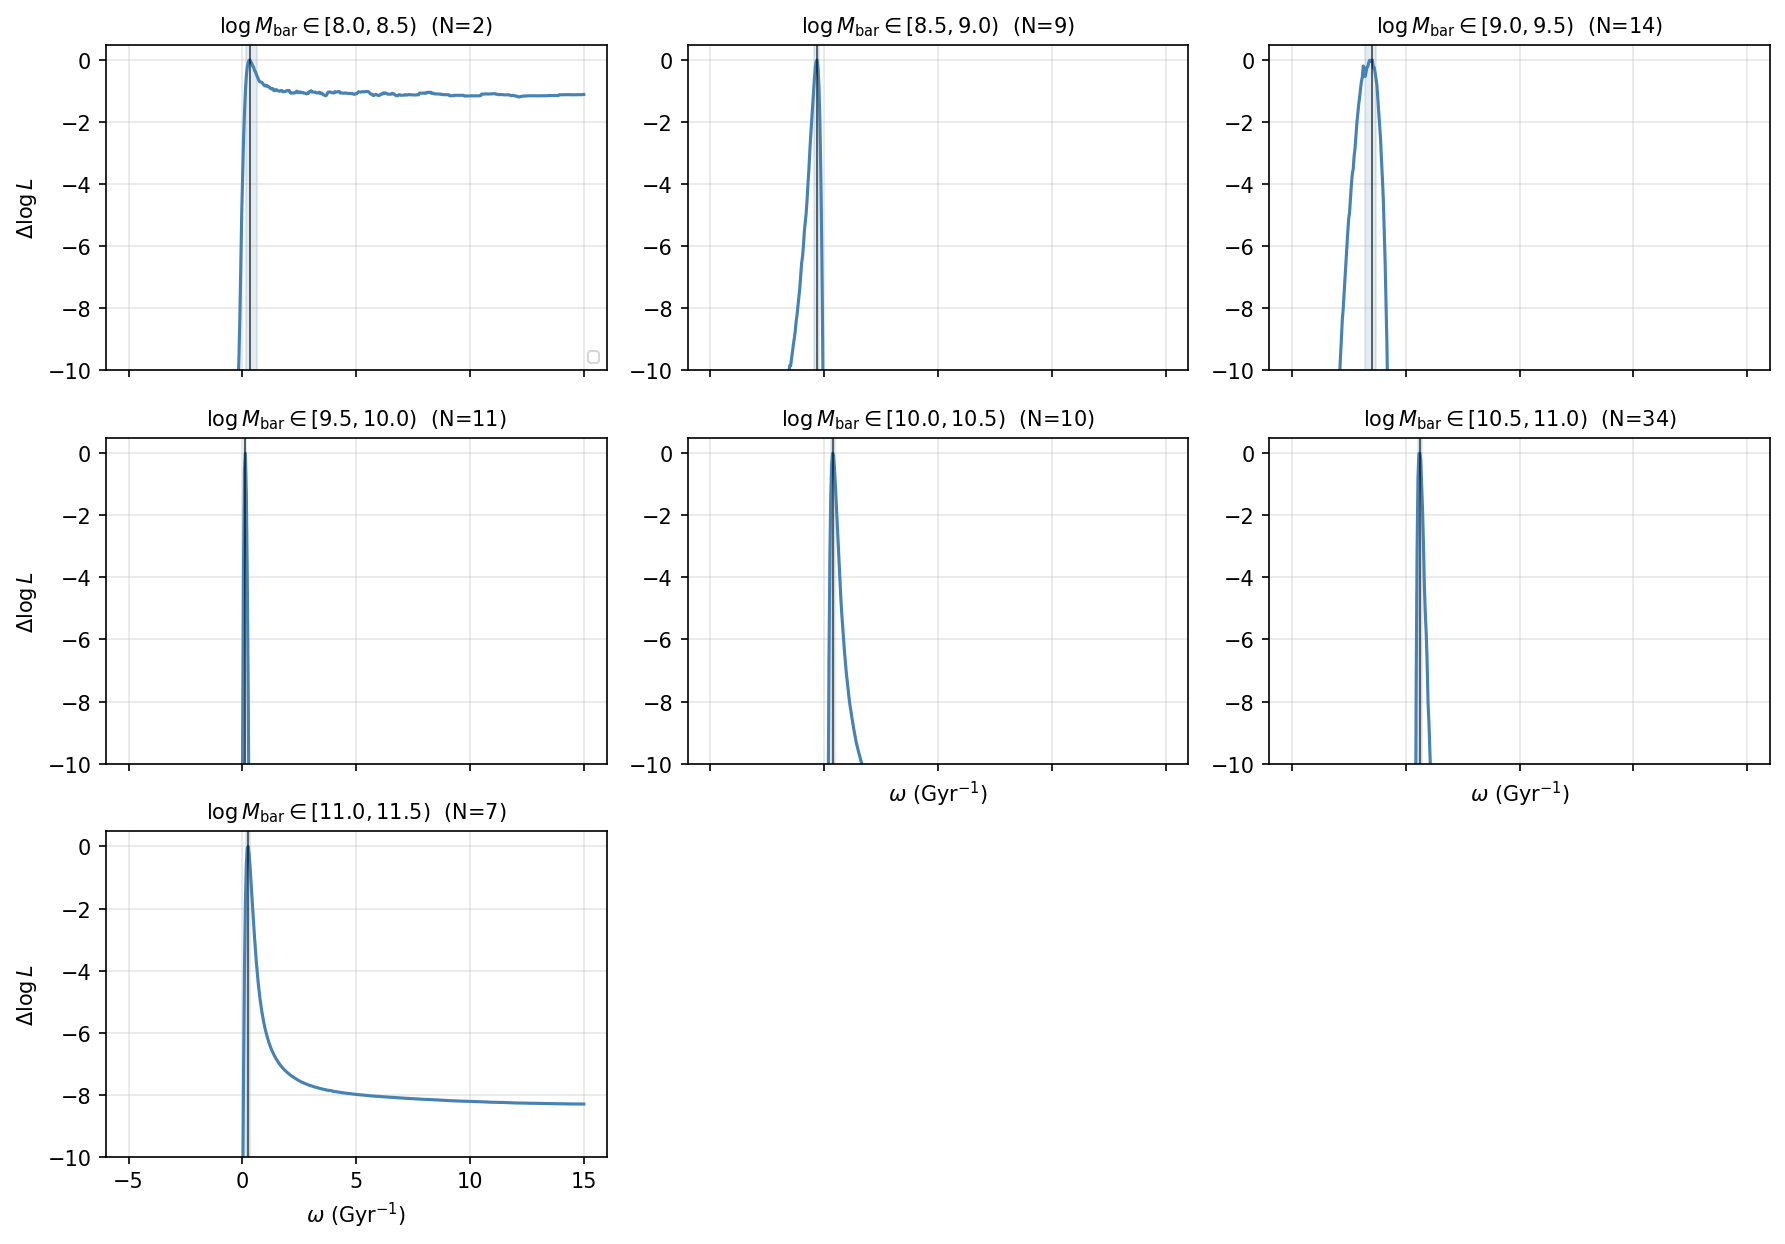

Execution time: 0.4696 seconds


In [31]:
valid_idx = np.where(n_gal_per_bin > 0)[0]
n_panels = len(valid_idx)
ncols = 3
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 2.8*nrows),
                         dpi=150, sharex=True)
axes = np.atleast_1d(axes).flatten()

for k, i in enumerate(valid_idx):
    ax = axes[k]
    row = logL_per_bin[i]
    j_max = int(np.argmax(row))
    L_max = row[j_max]

    # Plot Δ logL = logL - max
    ax.plot(omega_grid, row - L_max, color='steelblue', lw=1.5)
    # ax.axhline(-0.5, color='red', ls='--', lw=0.8, alpha=0.7, label=r'1σ ($\Delta\log L = -0.5$)')
    # ax.axhline(-2.0, color='red', ls=':',  lw=0.8, alpha=0.5, label=r'2σ ($\Delta\log L = -2.0$)')
    ax.axvline(omega_best_bin[i], color='k', lw=0.8, alpha=0.7)
    ax.axvspan(omega_lo_bin[i], omega_hi_bin[i], color='steelblue', alpha=0.15)

    ax.set_title(rf'$\log M_{{\rm bar}} \in [{mass_bins_nio[i]:.1f}, {mass_bins_nio[i+1]:.1f})$  (N={n_gal_per_bin[i]})',
                 fontsize=10)
    ax.set_ylim(-10, 0.5)
    ax.grid(alpha=0.3)
    if k % ncols == 0:
        ax.set_ylabel(r'$\Delta \log L$', fontsize=10)
    if k >= n_panels - ncols:
        ax.set_xlabel(r'$\omega$ (Gyr$^{-1}$)', fontsize=10)
    if k == 0:
        ax.legend(fontsize=7, loc='lower right')

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].axis('off')

# plt.suptitle('Per-bin log-likelihood profile vs ω', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

# Radial Profiles for Model Comparison

This section computes and saves radial profiles of Σ_gas, Σ_star, Σ_SFR at different times,
as well as the integrated SFH (total SFR vs time), for comparison with the inside-out model.

In [26]:
@partial(jax.jit, static_argnames=("sfl_type",))
def _compute_radial_profiles_nio_jax(logM, t_acc, r_acc_pc, M_bar, sfl_type="cutoff_ksl"):
    """
    JIT-compiled core computation for radial profiles.
    
    Parameters:
    -----------
    logM : float
        log10(M_bar / Msun)
    t_acc : float
        Accretion timescale (Gyr)
    r_acc_pc : float
        Accretion radius in pc (constant, not array)
    M_bar : float
        Baryonic mass in Msun
    sfl_type : str
        Star formation law type
    
    Returns:
    --------
    dict with JAX arrays for all profile data
    """
    # Radial grid
    res = 120.0
    Rmax = 100.1
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)
    r_kpc = r_pc / 1000.0
    dr = res
    
    # Normalization constant
    C = C_def_jax(M_bar, t_acc)
    
    # Compute Sigma_gas(r, t) with constant r_acc
    # Sigma_definer_static_racc_jax expects array, returns (n_racc, n_r, n_t)
    r_acc_array = jnp.array([r_acc_pc], dtype=jnp.float64)
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc, t_acc, M_bar, C, sfl_type, r_acc_array
    )[0]  # (n_r, n_t)
    
    # Compute SFR surface density
    R_broad = r_pc[:, None]
    SD_sfr = SFL_jax(SD_gas, sfl_type, R_broad, M_bar)
    
    # Time step
    dt = M_times1_jax[1] - M_times1_jax[0]
    
    # Compute stellar surface density via cumulative integration
    SD_star = dt * jnp.cumsum(SD_sfr, axis=-1)
    
    # Radial integration helpers
    r_col = r_pc[:, None]
    r2_col = r_col**2
    
    def integrate_radially(integrand):
        return simpson_uniform_jax(integrand, dr, axis=0)
    
    # Mass integrals
    integrand_gas = 2.0 * jnp.pi * r_col * SD_gas
    integrand_sfr = 2.0 * jnp.pi * r_col * SD_sfr
    
    M_gas_t = integrate_radially(integrand_gas)
    M_sfr_t = integrate_radially(integrand_sfr)  # SFR(t) = SFH
    M_star_t = dt * jnp.cumsum(M_sfr_t)
    M_bar_t = M_gas_t + M_star_t
    
    # Gas fraction
    f_gas_t = M_gas_t / jnp.where(M_bar_t > 0, M_bar_t, jnp.inf)
    
    # Angular momentum integrals
    v_rot = exp_vrot_jax(r_pc, M_bar)[:, None]  # (n_r, 1)
    
    integrand_gas_j = 2.0 * jnp.pi * r2_col * SD_gas * v_rot
    integrand_sfr_j = 2.0 * jnp.pi * r2_col * SD_sfr * v_rot
    
    nom_gas = integrate_radially(integrand_gas_j)
    nom_sfr = integrate_radially(integrand_sfr_j)
    nom_star = dt * jnp.cumsum(nom_sfr)
    nom_bar = nom_star + nom_gas
    
    # Specific angular momentum (pc*km/s -> kpc*km/s)
    j_bar_t = (nom_bar / jnp.where(M_bar_t > 0, M_bar_t, jnp.inf)) / 1000.0
    j_gas_t = (nom_gas / jnp.where(M_gas_t > 0, M_gas_t, jnp.inf)) / 1000.0
    j_star_t = (nom_star / jnp.where(M_star_t > 0, M_star_t, jnp.inf)) / 1000.0
    
    return {
        'r_kpc': r_kpc,
        'times': M_times1_jax,
        'Sigma_gas': SD_gas,
        'Sigma_sfr': SD_sfr,
        'Sigma_star': SD_star,
        'SFH': M_sfr_t,
        'M_gas_t': M_gas_t,
        'M_star_t': M_star_t,
        'f_gas_t': f_gas_t,
        'j_bar_t': j_bar_t,
        'j_gas_t': j_gas_t,
        'j_star_t': j_star_t,
    }


def compute_radial_profiles_nio(logM, j_bar_obs, a, b, sfl_type="cutoff_ksl"):
    """
    Compute radial profiles for the non-inside-out model.
    
    Key model features:
    - omega(M_bar) = a * (logM - 10) + b determines t_acc
    - j_acc = j_bar_obs (analytical result: j_bar = j_acc for constant j_acc)
    - r_acc is constant in time (derived from j_acc via r_btfr_def)
    
    Parameters:
    -----------
    logM : float
        log10(M_bar / Msun)
    j_bar_obs : float
        Observed baryonic specific angular momentum [kpc km/s]
    a, b : float
        omega(M_bar) parameters [Gyr^-1]
    sfl_type : str
        Star formation law type
    
    Returns:
    --------
    dict with numpy arrays containing all radial profile data
    """
    M_bar = 10.0**logM
    
    # Compute t_acc from M_bar-dependent omega
    omega = float(omega_Mdep(logM, a, b))
    t_acc = 1.0 / omega if abs(omega) > 1e-4 else 1000.0
    
    # j_acc = j_bar_obs (the analytical result)
    j_acc = j_bar_obs
    
    # Compute r_acc from j_acc (requires scipy, cannot be JIT-compiled)
    r_acc_kpc = r_btfr_def(M_bar, j_acc)
    r_acc_pc = r_acc_kpc * 1000.0
    
    # Call JIT-compiled core function
    profiles = _compute_radial_profiles_nio_jax(
        logM, t_acc, r_acc_pc, M_bar, sfl_type=sfl_type
    )
    
    # Convert to numpy and add metadata
    return {
        'log_M_bar': logM,
        't_acc': t_acc,
        'omega': omega,
        'j_acc': j_acc,
        'a': a,
        'b': b,
        'r_acc_kpc': r_acc_kpc,
        'r_kpc': np.array(profiles['r_kpc']),
        'times': np.array(profiles['times']),
        'Sigma_gas': np.array(profiles['Sigma_gas']),
        'Sigma_sfr': np.array(profiles['Sigma_sfr']),
        'Sigma_star': np.array(profiles['Sigma_star']),
        'SFH': np.array(profiles['SFH']),
        'M_gas_t': np.array(profiles['M_gas_t']),
        'M_star_t': np.array(profiles['M_star_t']),
        'f_gas_t': np.array(profiles['f_gas_t']),
        'j_bar_t': np.array(profiles['j_bar_t']),
        'j_gas_t': np.array(profiles['j_gas_t']),
        'j_star_t': np.array(profiles['j_star_t']),
    }


def save_radial_profiles_nio(profiles, filename):
    """Save radial profiles to a .npz file."""
    profiles_np = {k: (np.array(v) if hasattr(v, 'shape') else v) 
                   for k, v in profiles.items()}
    np.savez(filename, **profiles_np)


def load_radial_profiles_nio(filename):
    """Load radial profiles from a .npz file."""
    data = np.load(filename, allow_pickle=True)
    return {key: data[key] for key in data.files}


def compute_and_save_all_profiles_nio(logM_obs, jbar_obs, a, b, 
                                       galaxy_names=None,
                                       output_dir='../outputs/model_radial_profiles/nio/',
                                       sfl_type="cutoff_ksl"):
    """
    Compute and save radial profiles for all observed galaxies.
    
    In the non-inside-out model:
    - omega(M_bar) = a * (logM - 10) + b determines t_acc
    - j_acc = j_bar_obs (analytical result)
    - r_acc is constant in time
    """
    os.makedirs(output_dir, exist_ok=True)
    
    logM_obs = np.asarray(logM_obs)
    jbar_obs = np.asarray(jbar_obs)
    n_gal = len(logM_obs)
    
    if galaxy_names is None:
        galaxy_names = [f"galaxy_{i:03d}" for i in range(n_gal)]
    
    print(f"Computing radial profiles for {n_gal} galaxies")
    print(f"Model: omega = {a:.4f}*(logM-10) + {b:.4f} [Gyr^-1]")
    
    all_profiles = []
    
    for i in range(n_gal):
        logM_i = float(logM_obs[i])
        jbar_i = float(jbar_obs[i])
        name_i = galaxy_names[i]
        
        try:
            profile = compute_radial_profiles_nio(logM_i, jbar_i, a, b, sfl_type=sfl_type)
            profile['galaxy_name'] = name_i
            profile['is_valid'] = True
            
            # Save individual profile
            filename = os.path.join(output_dir, f"{name_i}_profile.npz")
            save_radial_profiles_nio(profile, filename)
            
        except Exception as e:
            print(f"  Warning: {name_i} failed: {e}")
            profile = {'galaxy_name': name_i, 'log_M_bar': logM_i, 
                      'j_acc': jbar_i, 'is_valid': False}
        
        all_profiles.append(profile)
        
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{n_gal}...")
    
    # Save summary
    valid_mask = np.array([p.get('is_valid', False) for p in all_profiles])
    summary_file = os.path.join(output_dir, f"all_profiles_a{a:.3f}_b{b:.3f}.npz")
    np.savez(summary_file,
             a=a, b=b,
             galaxy_names=galaxy_names,
             log_M_bar=logM_obs,
             j_bar_obs=jbar_obs,
             t_acc=np.array([p.get('t_acc', np.nan) for p in all_profiles]),
             omega=np.array([p.get('omega', np.nan) for p in all_profiles]),
             r_acc_kpc=np.array([p.get('r_acc_kpc', np.nan) for p in all_profiles]),
             is_valid=valid_mask,
             r_kpc=all_profiles[0]['r_kpc'] if valid_mask[0] else None,
             times=all_profiles[0]['times'] if valid_mask[0] else None,
    )
    print(f"\nSaved {np.sum(valid_mask)}/{n_gal} profiles to {output_dir}")
    
    return all_profiles

Execution time: 0.0257 seconds


In [ ]:
converged_names = CONVERGED['Name'].tolist()
hix_names = [f"HIX_{i:02d}" for i in range(len(HIX_data))]
all_galaxy_names = converged_names + hix_names

print(f"Using a = {a_median:.3f}, b = {b_median:.3f}")
print(f"Total galaxies: {len(logM_obs_mcmc)} ({len(converged_names)} CONVERGED + {len(hix_names)} HIX)")

all_profiles_nio = compute_and_save_all_profiles_nio(
    logM_obs_mcmc,
    jbar_obs_mcmc,
    a_median, 
    b_median,
    galaxy_names=all_galaxy_names,
    output_dir='../outputs/model_radial_profiles/nio/',
    sfl_type="cutoff_ksl"
)

print(f"\nDone! Computed profiles for {len(all_profiles_nio)} galaxies.")


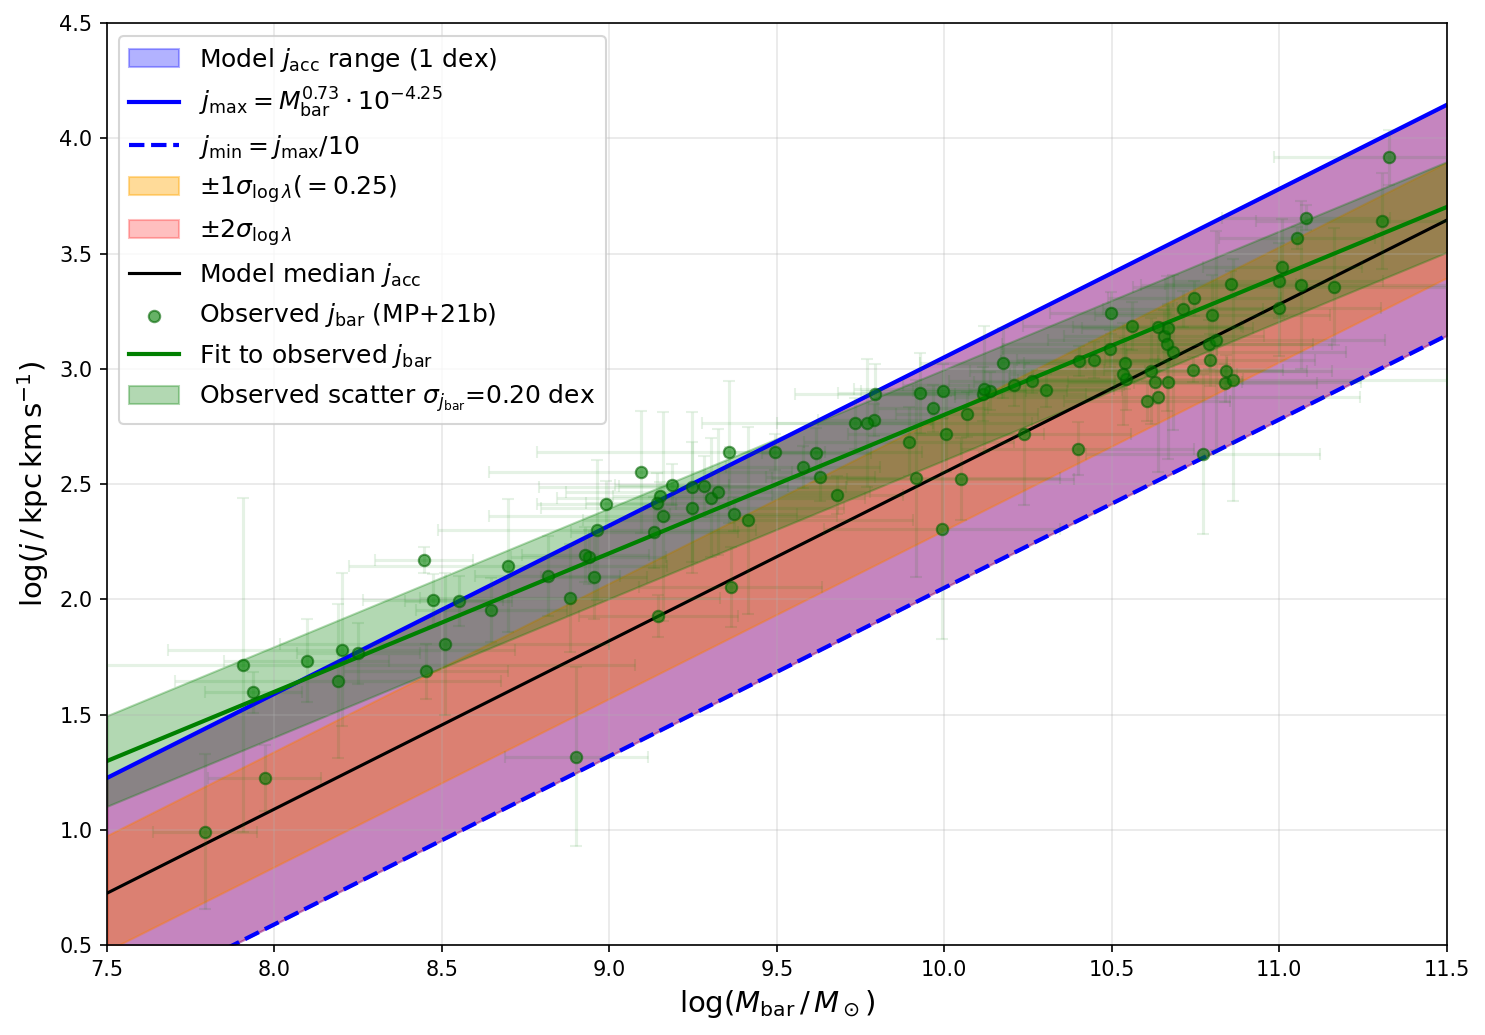

Execution time: 0.3083 seconds


In [ ]:
# Compare model j_acc scatter with LCDM spin parameter distribution

# From LCDM simulations, lambda follows a log-normal distribution:
#   median lambda ~ 0.035
#   sigma_ln(lambda) ~ 0.5-0.6  =>  sigma_log10(lambda) ~ 0.22-0.26
#
# Since j ∝ lambda at fixed halo mass, the scatter in log(j) equals scatter in log(lambda)

# Mass array for plotting
log_M_plot = np.linspace(7.5, 11.5, 100)
M_plot = 10**log_M_plot

# Model j_acc range
j_max_plot = j_maxer(M_plot)
j_min_plot = j_max_plot / 10.0

# Geometric mean of j_acc range (representative "median" j_acc in model)
j_median_model = np.sqrt(j_max_plot * j_min_plot)

# LCDM spin parameter sigma_ln(lambda) ~ 0.5-0.6 --> sigma_log10(lambda) ~ 0.22-0.26
sigma_log10_lambda = 0.25 #conservative choice

# For LCDM comparison, use the model's median j_acc as reference
# and add scatter based on lambda distribution
log_j_median = np.log10(j_median_model)
j_lcdm_1sigma_up = 10**(log_j_median + sigma_log10_lambda)
j_lcdm_1sigma_down = 10**(log_j_median - sigma_log10_lambda)
j_lcdm_2sigma_up = 10**(log_j_median + 2*sigma_log10_lambda)
j_lcdm_2sigma_down = 10**(log_j_median - 2*sigma_log10_lambda)
j_lcdm_3sigma_up = 10**(log_j_median + 3*sigma_log10_lambda)
j_lcdm_3sigma_down = 10**(log_j_median - 3*sigma_log10_lambda)

# Plot
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# Model j_acc range (shaded)
ax.fill_between(log_M_plot, np.log10(j_min_plot), np.log10(j_max_plot), 
                alpha=0.3, color='blue', label=r'Model $j_{\rm acc}$ range (1 dex)')
ax.plot(log_M_plot, np.log10(j_max_plot), 'b-', lw=2, label=r'$j_{\rm max} = M_{\rm bar}^{0.73} \cdot 10^{-4.25}$')
ax.plot(log_M_plot, np.log10(j_min_plot), 'b--', lw=2, label=r'$j_{\rm min} = j_{\rm max}/10$')

# LCDM scatter bands (centered on model median)
ax.fill_between(log_M_plot, np.log10(j_lcdm_1sigma_down), np.log10(j_lcdm_1sigma_up),
                alpha=0.4, color='orange', label=rf'$\pm 1\sigma_{{\log \lambda}} (={sigma_log10_lambda}$)')
ax.fill_between(log_M_plot, np.log10(j_lcdm_2sigma_down), np.log10(j_lcdm_2sigma_up),
                alpha=0.25, color='red', label=r'$\pm 2\sigma_{\log \lambda}$')

# Model median line
ax.plot(log_M_plot, log_j_median, 'k-', lw=1.5, label=r'Model median $j_{\rm acc}$')

# Observed j_bar data for comparison
ax.scatter(obs_Mbar, obs_jbar, c='green', s=30, alpha=0.6, edgecolors='darkgreen', 
           label=r'Observed $j_{\rm bar}$ (MP+21b)', zorder=5)
ax.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors,
            fmt=' ', ecolor='green', alpha=0.1, capsize=3, zorder=4)
# fit observed j_bar - M_bar relation in log-log space and 1sigma scatter of the fit as fill_between -- use ODR to account for errors in both x and y
from scipy.odr import ODR, Model, RealData
def log_fit(beta, x):
    return beta[0] * x + beta[1]
data = RealData(obs_Mbar, obs_jbar, sx=obs_Mbar_errors, sy=obs_jbar_errors)
model = Model(log_fit)
odr = ODR(data, model, beta0=[0.7, -4.0])
out = odr.run()
a_fit, b_fit = out.beta
y_fit = log_fit([a_fit, b_fit], log_M_plot)
ax.plot(log_M_plot, y_fit, 'g-', lw=2, label=rf'Fit to observed $j_{{\rm bar}}$')
# Calculate scatter of observed points around the fit
y_fit_obs = log_fit([a_fit, b_fit], obs_Mbar)
residuals = obs_jbar - y_fit_obs
sigma_obs = np.std(residuals)
ax.fill_between(log_M_plot, y_fit - sigma_obs, y_fit + sigma_obs, color='green', alpha=0.3, label=rf'Observed scatter $\sigma_{{j_{{\rm bar}}}}$={sigma_obs:.2f} dex')

# Annotations
# model_range_dex = 1.0
# lcdm_2sigma_dex = 4 * sigma_log10_lambda
# ax.text(0.02, 0.98, f'Model range: {model_range_dex:.1f} dex\n'
#                      f'LCDM 1σ range: {2*sigma_log10_lambda:.2f} dex\n'
#                      f'LCDM 2σ range: {4*sigma_log10_lambda:.2f} dex',
#         transform=ax.transAxes, fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel(r'$\log(M_{\rm bar} \, / \, M_\odot)$', fontsize=14)
ax.set_ylabel(r'$\log(j \, / \, {\rm kpc \, km \, s^{-1}})$', fontsize=14)
# ax.set_title(r'Model $j_{\rm acc}$ scatter vs $\Lambda$CDM spin parameter distribution', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(7.5, 11.5)
ax.set_ylim(0.5, 4.5)

plt.tight_layout()
plt.show()
fig.savefig('../outputs/graphs_elise_new_rot/j_acc_scatter_vs_LCDM_lambda.pdf', dpi=300)

In [51]:
# Compute per-galaxy f_gas chi-squared for fair model comparison
f_gas_preds_nonio = []

for i in range(len(logM_obs_mcmc)):
    f_mod, j_mod = run_single_galaxy_from_jbar(
        logM_obs_mcmc[i], jbar_obs_mcmc[i], np.median(flat_samples_Mdep_omega[:, 0]), np.median(flat_samples_Mdep_omega[:, 1])
    )
    f_gas_preds_nonio.append(f_mod)

f_gas_preds_nonio = np.array(f_gas_preds_nonio)
sigma_fgas_clipped = np.maximum(fgas_errors_mcmc, 4e-3)  # same clipping as IO model
residuals_nonio = (fgas_obs_mcmc - f_gas_preds_nonio) / sigma_fgas_clipped
chi2_fgas_nonio = np.sum(residuals_nonio**2)

print(f"f_gas χ² = {chi2_fgas_nonio:.2f}")
print(f"Number of galaxies: {len(logM_obs_mcmc)}")


f_gas χ² = 2210.61
Number of galaxies: 117
Execution time: 1.5550 seconds


In [52]:
flat_logp_elise = sampler_Mdep_omega.get_log_prob(flat=True)
flat_samples_full = sampler_Mdep_omega.get_chain(flat=True)
imax_elise = np.argmax(flat_logp_elise)
best_a, best_b = flat_samples_full[imax_elise]
log_L_max_elise = flat_logp_elise[imax_elise]

n_data = 117
k_params = 2

np.savez('../outputs/mcmc_results/bic_data_non_io_model.npz',
         log_L_max=log_L_max_elise,
         best_a=best_a,
         best_b=best_b,
         n_data=n_data,
         k_params=k_params,
         chi2_fgas=chi2_fgas_nonio,
         model_name='non_inside_out')

print(f"Saved: log_L_max={log_L_max_elise:.2f}, χ²_fgas={chi2_fgas_nonio:.2f}, a={best_a:.4f}, b={best_b:.4f}")

Saved: log_L_max=-1105.24, χ²_fgas=2210.61, a=1.6015, b=1.6222
Execution time: 0.0093 seconds


In [ ]:
# Define parameter grid
a_grid = np.linspace(0., 2., 5)  # slope
b_grid = np.linspace(0., 2., 5)  # intercept at 10^10 Msun

# Compute log-likelihood at each grid point
logL_grid = np.zeros((len(a_grid), len(b_grid)))

for i, a_val in enumerate(a_grid):
    for j, b_val in enumerate(b_grid):
        logL_grid[i, j] = logL_4obs_all_galaxies(
            a_val, b_val, 
            logM_obs_mcmc, jbar_obs_mcmc,
            Mgas_obs_mcmc, Mgas_errors_mcmc,
            Mstar_obs_mcmc, Mstar_errors_mcmc,
            jgas_obs_mcmc, jgas_errors_mcmc,
            jstar_obs_mcmc, jstar_errors_mcmc,
            sfl_type="cutoff_ksl"
        )
        print(f"Computed logL for a = {a_val:.3f}, b = {b_val:.3f}: {logL_grid[i, j]:.2f}")


Computed logL for a = 0.000, b = 0.000: -4526.78
Computed logL for a = 0.000, b = 0.500: -1319.84
Computed logL for a = 0.000, b = 1.000: -1214.93
Computed logL for a = 0.000, b = 1.500: -1203.51
Computed logL for a = 0.000, b = 2.000: -1200.55
Computed logL for a = 0.500, b = 0.000: -2996.44
Computed logL for a = 0.500, b = 0.500: -1223.38
Computed logL for a = 0.500, b = 1.000: -1139.53
Computed logL for a = 0.500, b = 1.500: -1175.67
Computed logL for a = 0.500, b = 2.000: -1188.35
Computed logL for a = 1.000, b = 0.000: -3623.82
Computed logL for a = 1.000, b = 0.500: -1859.64
Computed logL for a = 1.000, b = 1.000: -1121.10
Computed logL for a = 1.000, b = 1.500: -1132.51
Computed logL for a = 1.000, b = 2.000: -1155.39
Computed logL for a = 1.500, b = 0.000: -4159.63
Computed logL for a = 1.500, b = 0.500: -2822.42
Computed logL for a = 1.500, b = 1.000: -1454.43
Computed logL for a = 1.500, b = 1.500: -1106.03
Computed logL for a = 1.500, b = 2.000: -1146.24
Computed logL for a 


Grid search results:
  Best a = 1.500 Gyr^-1/dex
  Best b = 1.500 Gyr^-1
  Max log(L) = -1106.0


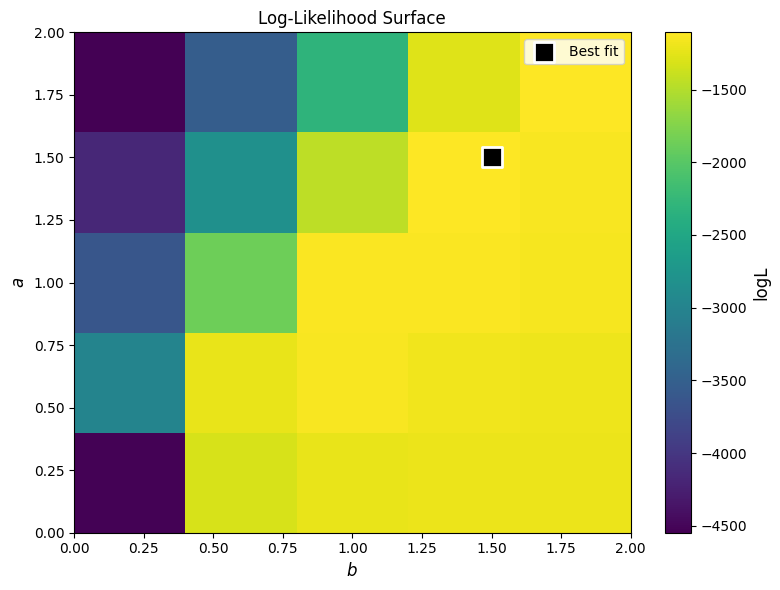

Execution time: 0.0981 seconds


In [26]:
best_idx = np.unravel_index(np.argmax(logL_grid), logL_grid.shape)
a_best_grid = a_grid[best_idx[0]]
b_best_grid = b_grid[best_idx[1]]
logL_best = logL_grid[best_idx]

print(f"\nGrid search results:")
print(f"  Best a = {a_best_grid:.3f} Gyr^-1/dex")
print(f"  Best b = {b_best_grid:.3f} Gyr^-1")
print(f"  Max log(L) = {logL_best:.1f}")

fig, ax = plt.subplots(figsize=(8, 6))
extent = [b_grid[0], b_grid[-1], a_grid[0], a_grid[-1]]
im = ax.imshow(logL_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
ax.scatter([b_best_grid], [a_best_grid], color='k', marker='s', s=200, edgecolors='white', linewidths=2, label='Best fit')
ax.set_xlabel(r'$b$', fontsize=12)
ax.set_ylabel(r'$a$', fontsize=12)
ax.set_title('Log-Likelihood Surface', fontsize=12)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'logL', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## Full run

In [14]:
t_acc_array = np.array([3., 25.]) # Gyr
n_M = len(log_M_bar_array)
n_tac = len(t_acc_array)

# Arrays: first index = mass, second index = t_acc
f_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_bar_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_star_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
Mstar_grid = np.zeros((n_M, n_tac, 10))
Mgas_grid  = np.zeros((n_M, n_tac, 10))

for j_tac, t_acc in enumerate(t_acc_array):
    print(f"Running models for t_acc = {t_acc:.1f} Gyr")

    # process_mbar takes (M, t_acc)
    process_mbar_cutoff_ksl = partial(process_mbar_old_model, t_acc=t_acc)

    # parallelize over M for this fixed t_acc
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_mbar_cutoff_ksl, log_M_bar_array))

    # unpack results into [:, j_tac, :]
    for i_M, (f_gas_temp, j_bar_temp, j_gas_temp, j_star_temp,
              Ms_temp,   Mg_temp) in enumerate(results):

        f_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = f_gas_temp
        j_bar_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_bar_temp
        j_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_gas_temp
        j_star_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_star_temp
        Mstar_grid[i_M, j_tac, :] = Ms_temp
        Mgas_grid[i_M, j_tac, :] = Mg_temp

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl.npy', Mgas_grid)

Running models for t_acc = 3.0 Gyr


/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
  j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:144: RuntimeWarning: invalid value encountered in divide
  j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:145: RuntimeWarning: invalid value encountered in divide
  j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
 

Running models for t_acc = 25.0 Gyr


/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
  f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:143: RuntimeWarning: invalid value encountered in divide
  j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:144: RuntimeWarning: invalid value encountered in divide
  j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:145: RuntimeWarning: invalid value encountered in divide
  j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
/tmp/ipykernel_988404/3771080033.py:133: RuntimeWarning: invalid value encountered in divide
 

Execution time: 115.2275 seconds


In [21]:
t_acc_array = np.array([3.0, 10.0, 25.0, -10.0], dtype=float)
t_acc_array_jax = jnp.array(t_acc_array, dtype=jnp.float64)

Mbar_grid = 10.0**log_M_bar_array
Mbar_grid_jax = jnp.array(Mbar_grid, dtype=jnp.float64)

f_gas_all_jax, j_bar_all_jax, j_gas_all_jax, j_star_all_jax, Ms_all_jax, Mg_all_jax = \
    run_all_masses_bad_jax(
        Mbar_grid_jax,
        t_acc_array_jax,
        r_acc_grid_jax,
        star_formation_law="cutoff_ksl",
    )

f_gas_array_10_50_cutoff_ksl = np.array(f_gas_all_jax)
j_bar_array_10_50_cutoff_ksl = np.array(j_bar_all_jax)
j_gas_array_10_50_cutoff_ksl = np.array(j_gas_all_jax)
j_star_array_10_50_cutoff_ksl = np.array(j_star_all_jax)
Mstar_grid = np.array(Ms_all_jax)
Mgas_grid  = np.array(Mg_all_jax)

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl_bad_jax.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl_bad_jax.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl_bad_jax.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl_bad_jax.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl_bad_jax.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl_bad_jax.npy', Mgas_grid)

Execution time: 51.9397 seconds


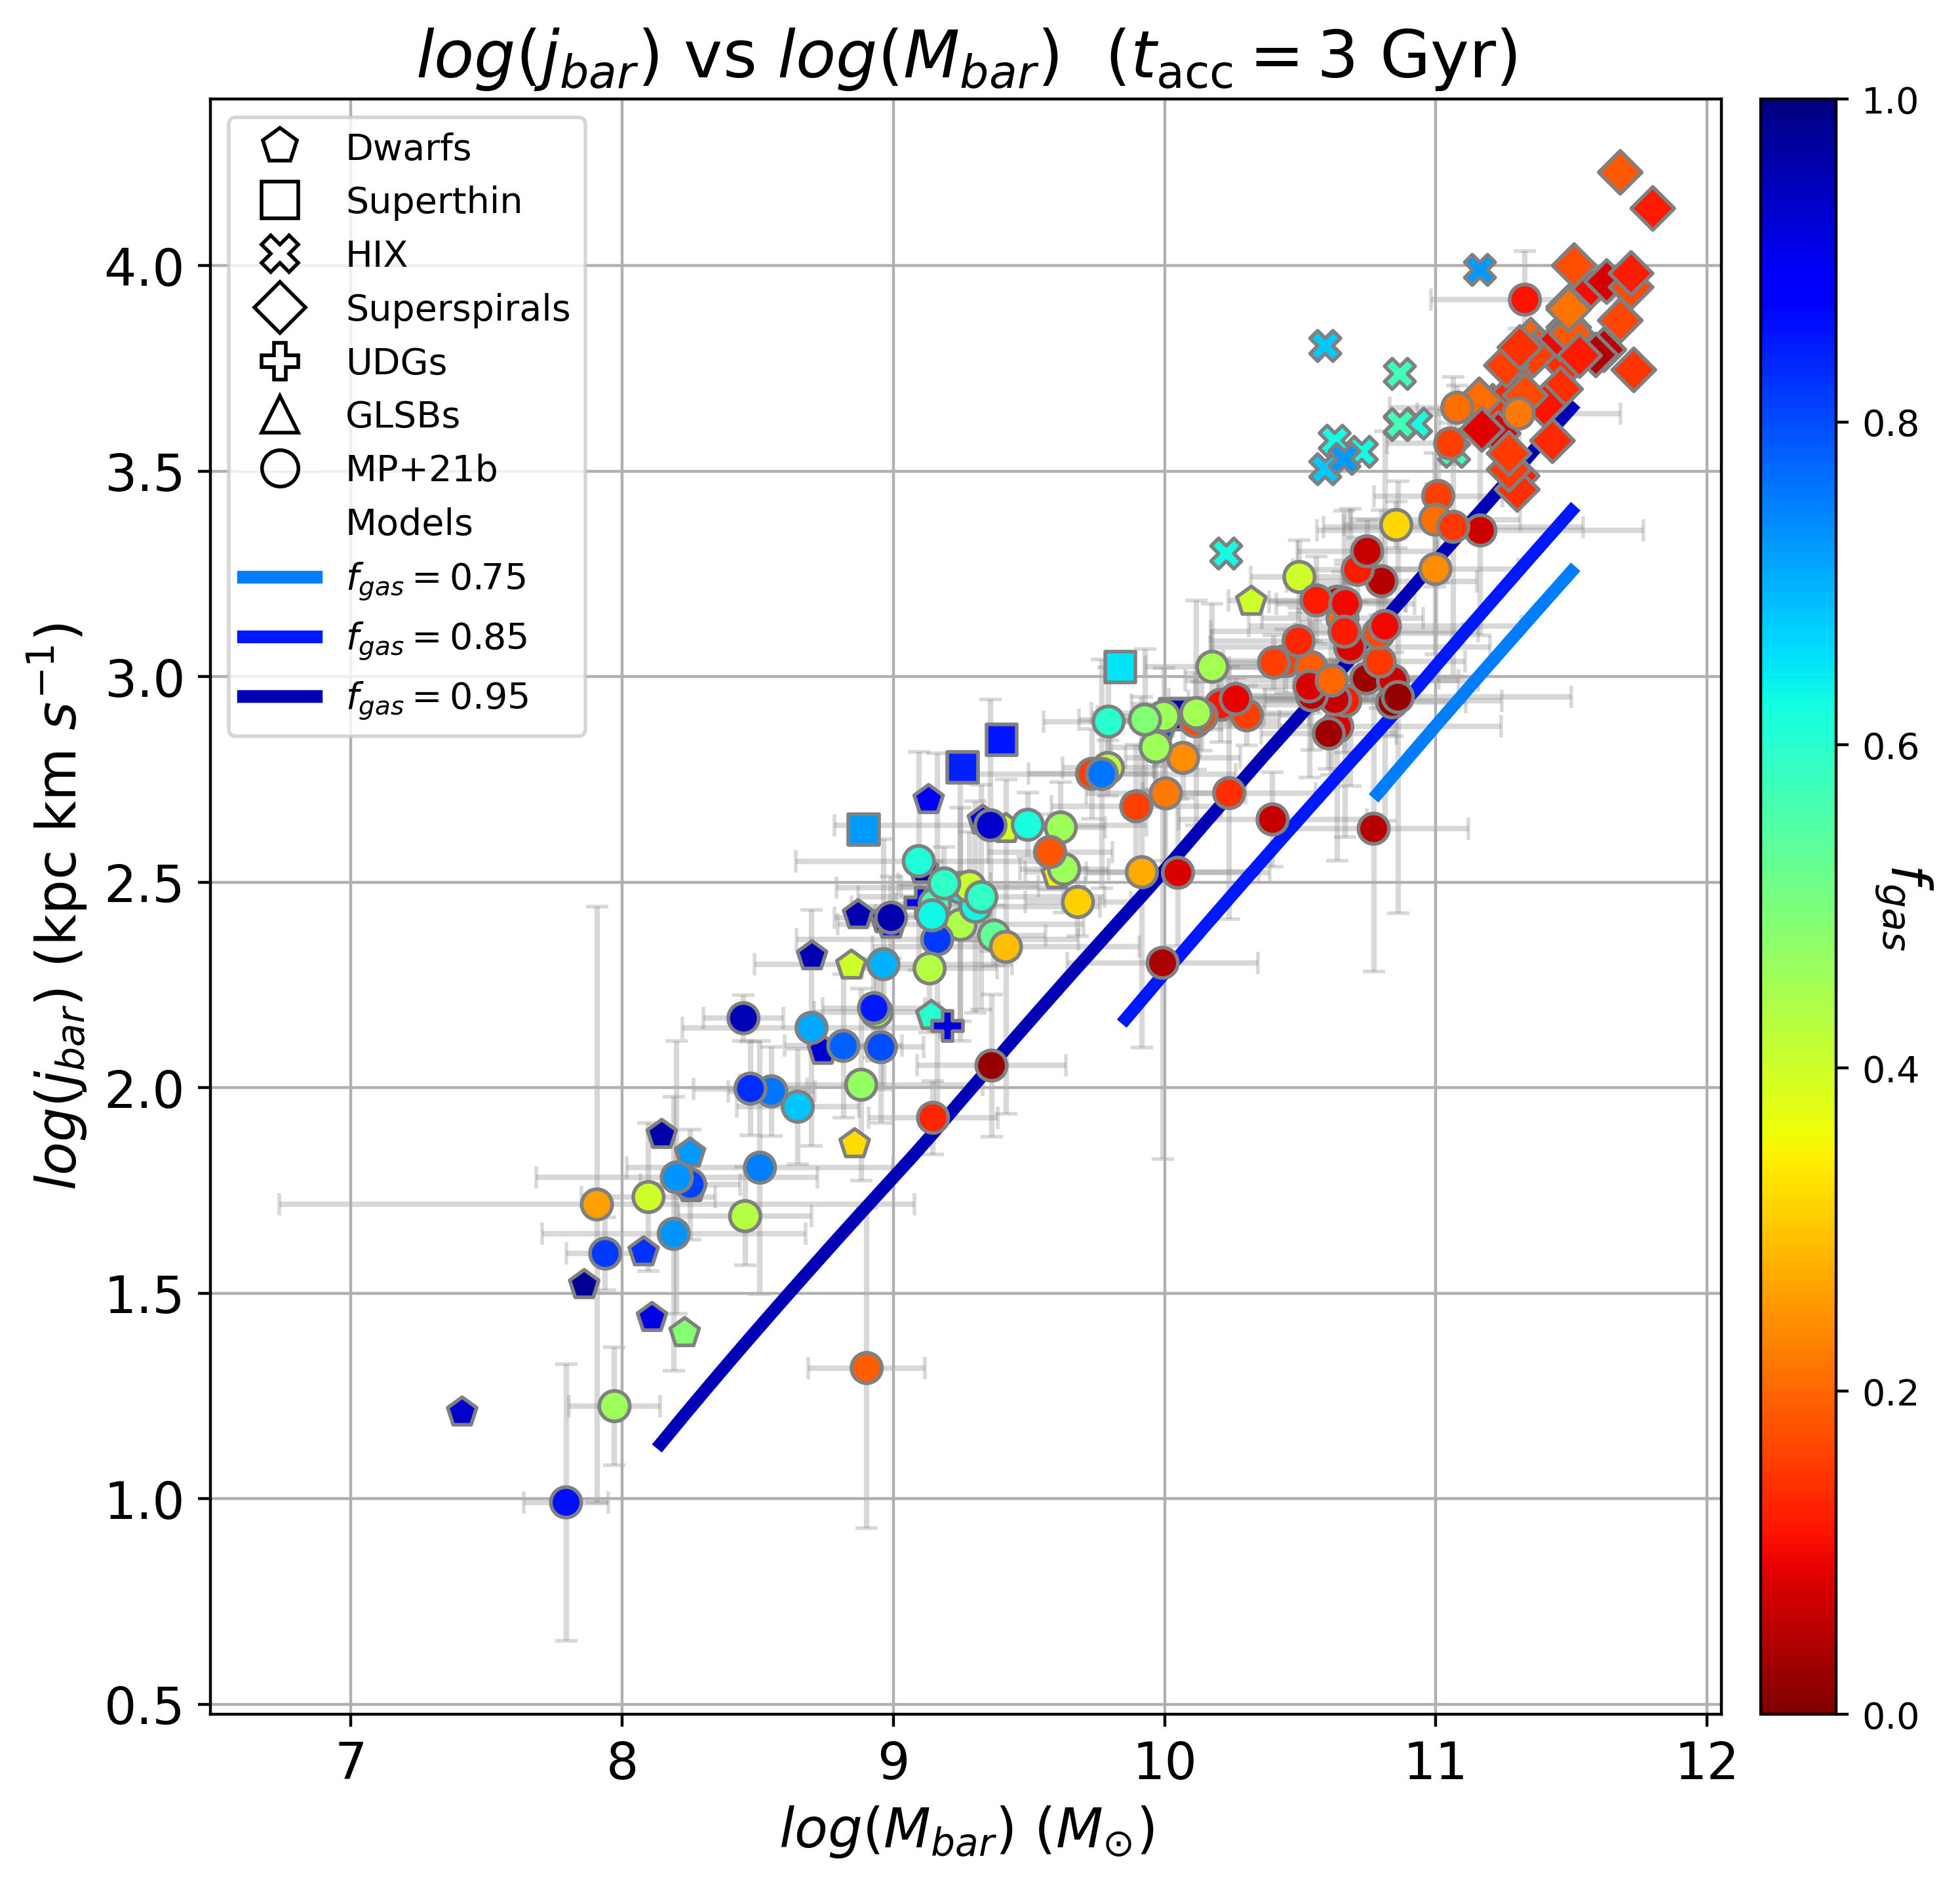

Execution time: 0.8861 seconds


In [ ]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 0, :].min(),f_gas_array_10_50_cutoff_ksl[i, 0, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 0, :], log_j_bar_array_10_50[i, 0, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 3$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).pdf')

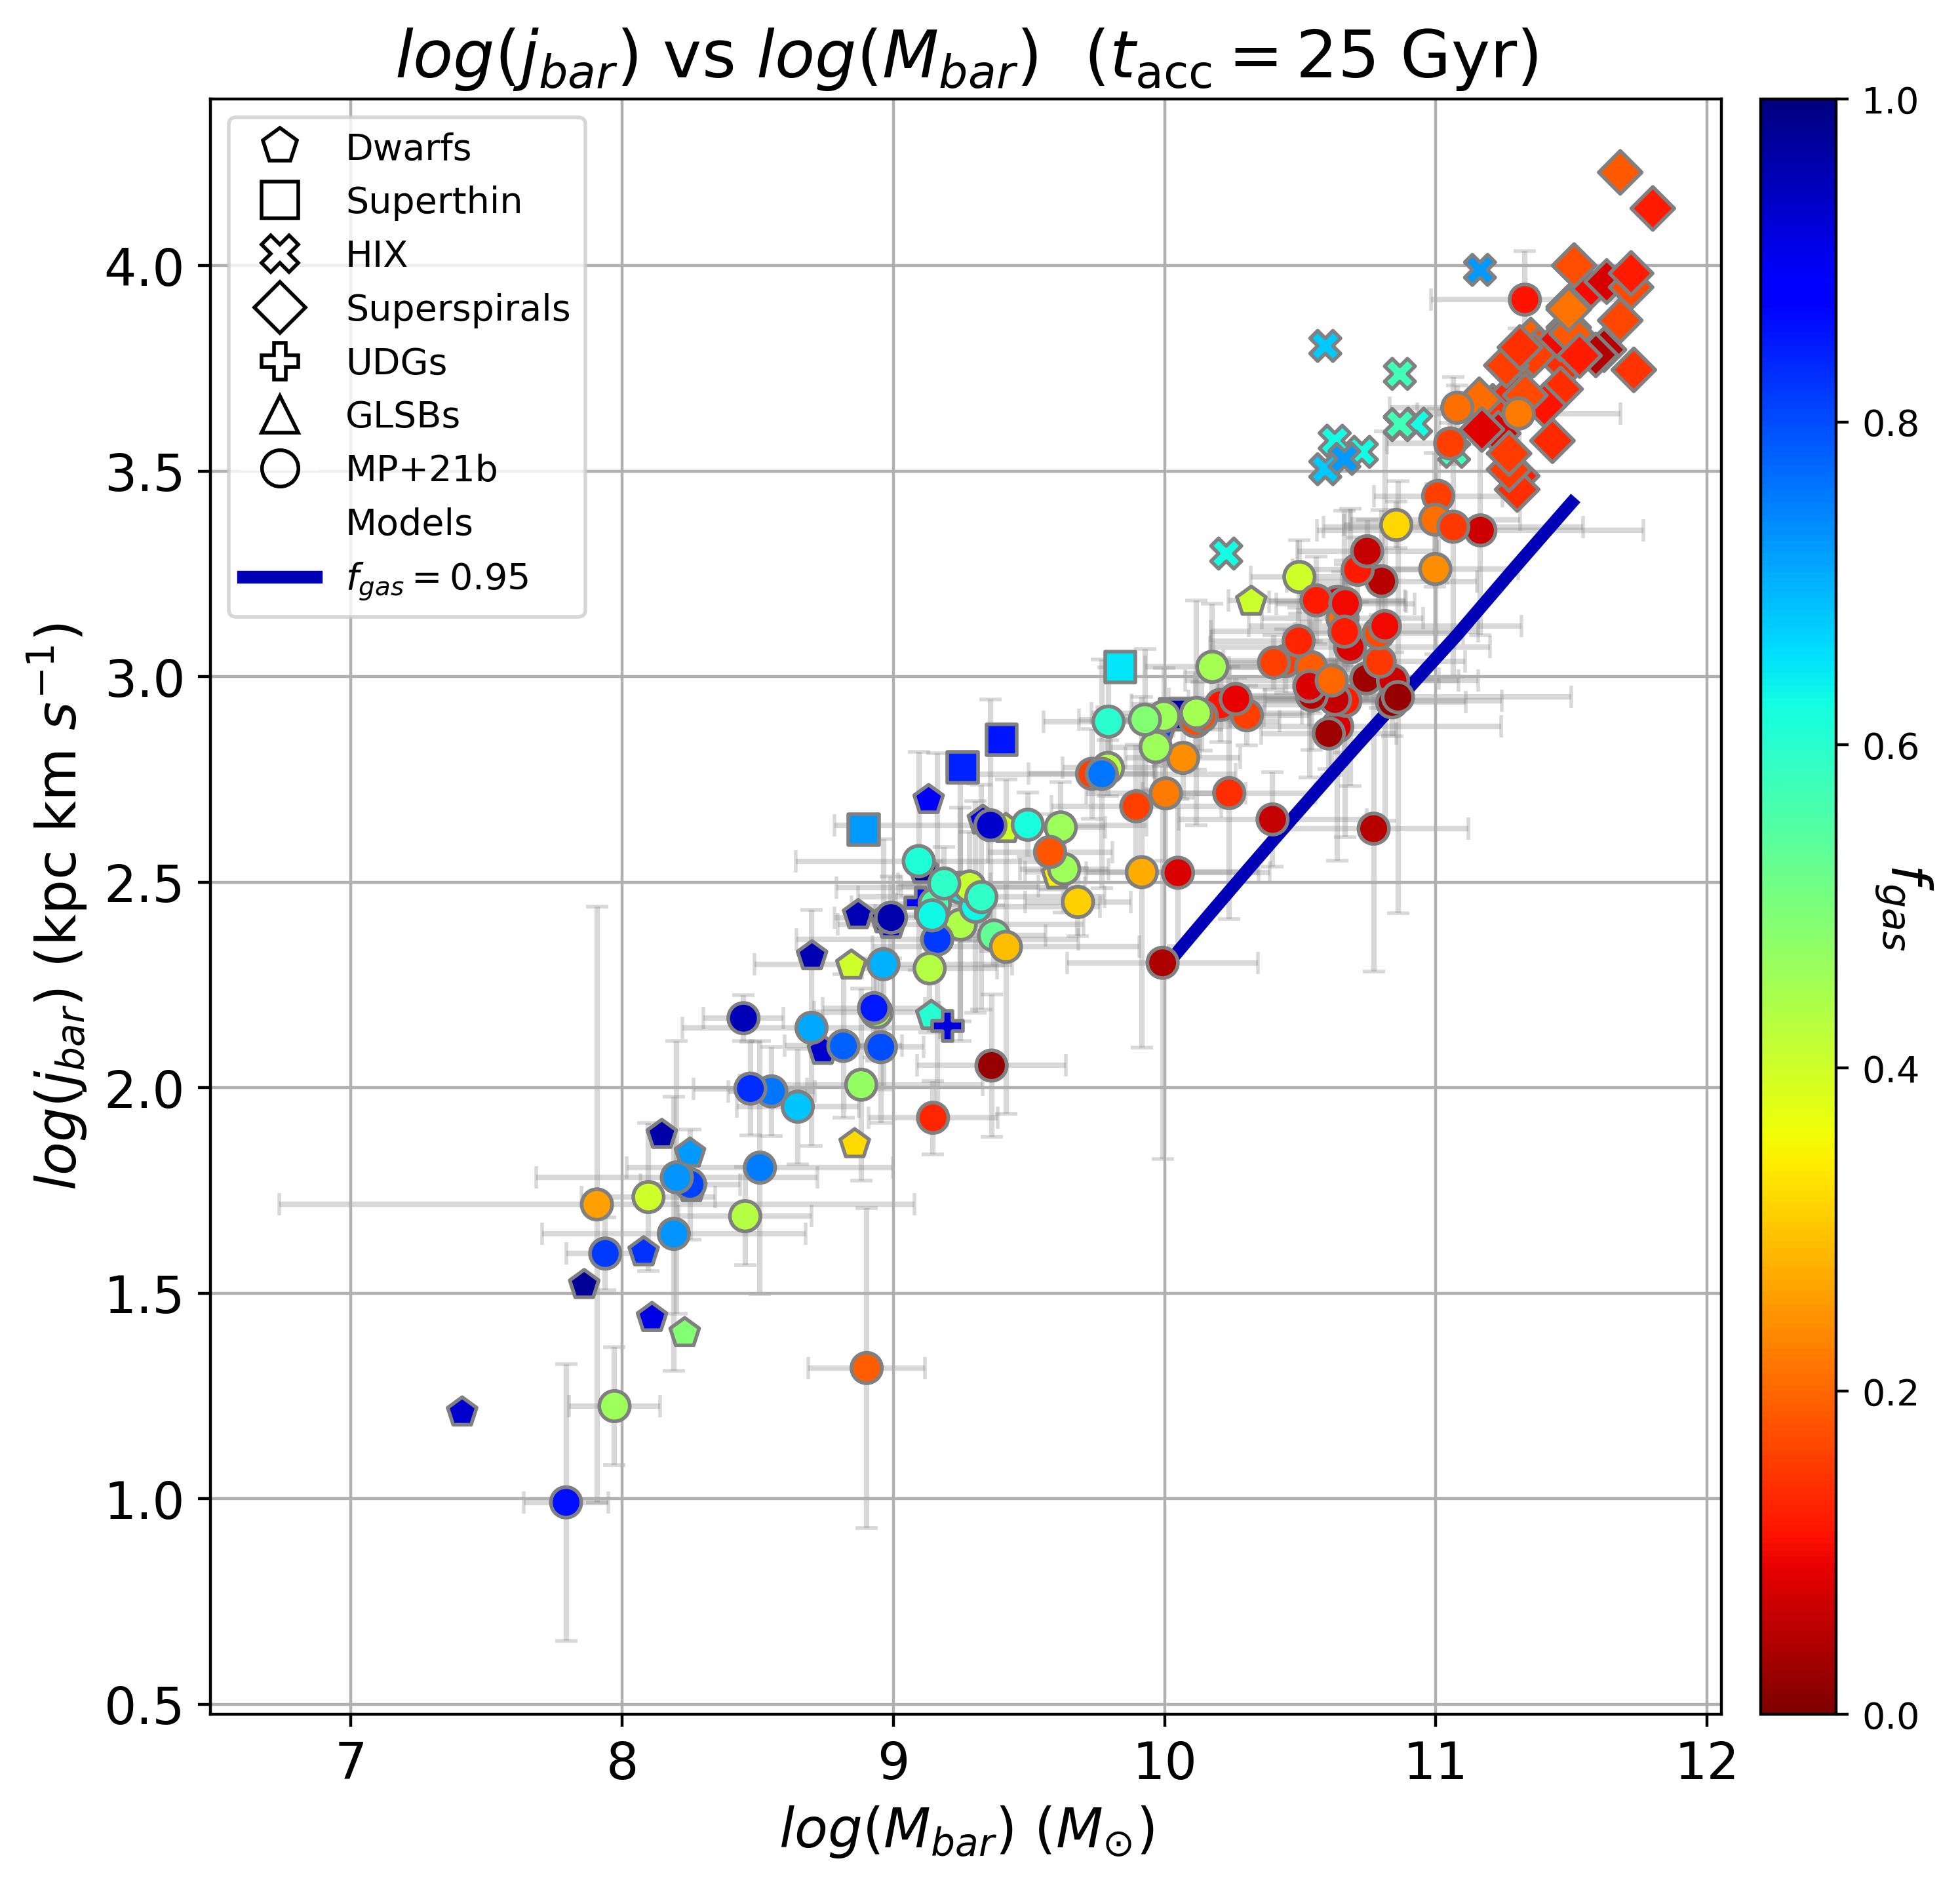

Execution time: 0.8468 seconds


In [ ]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 1, :].min(),f_gas_array_10_50_cutoff_ksl[i, 1, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 1, :], log_j_bar_array_10_50[i, 1, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).pdf')

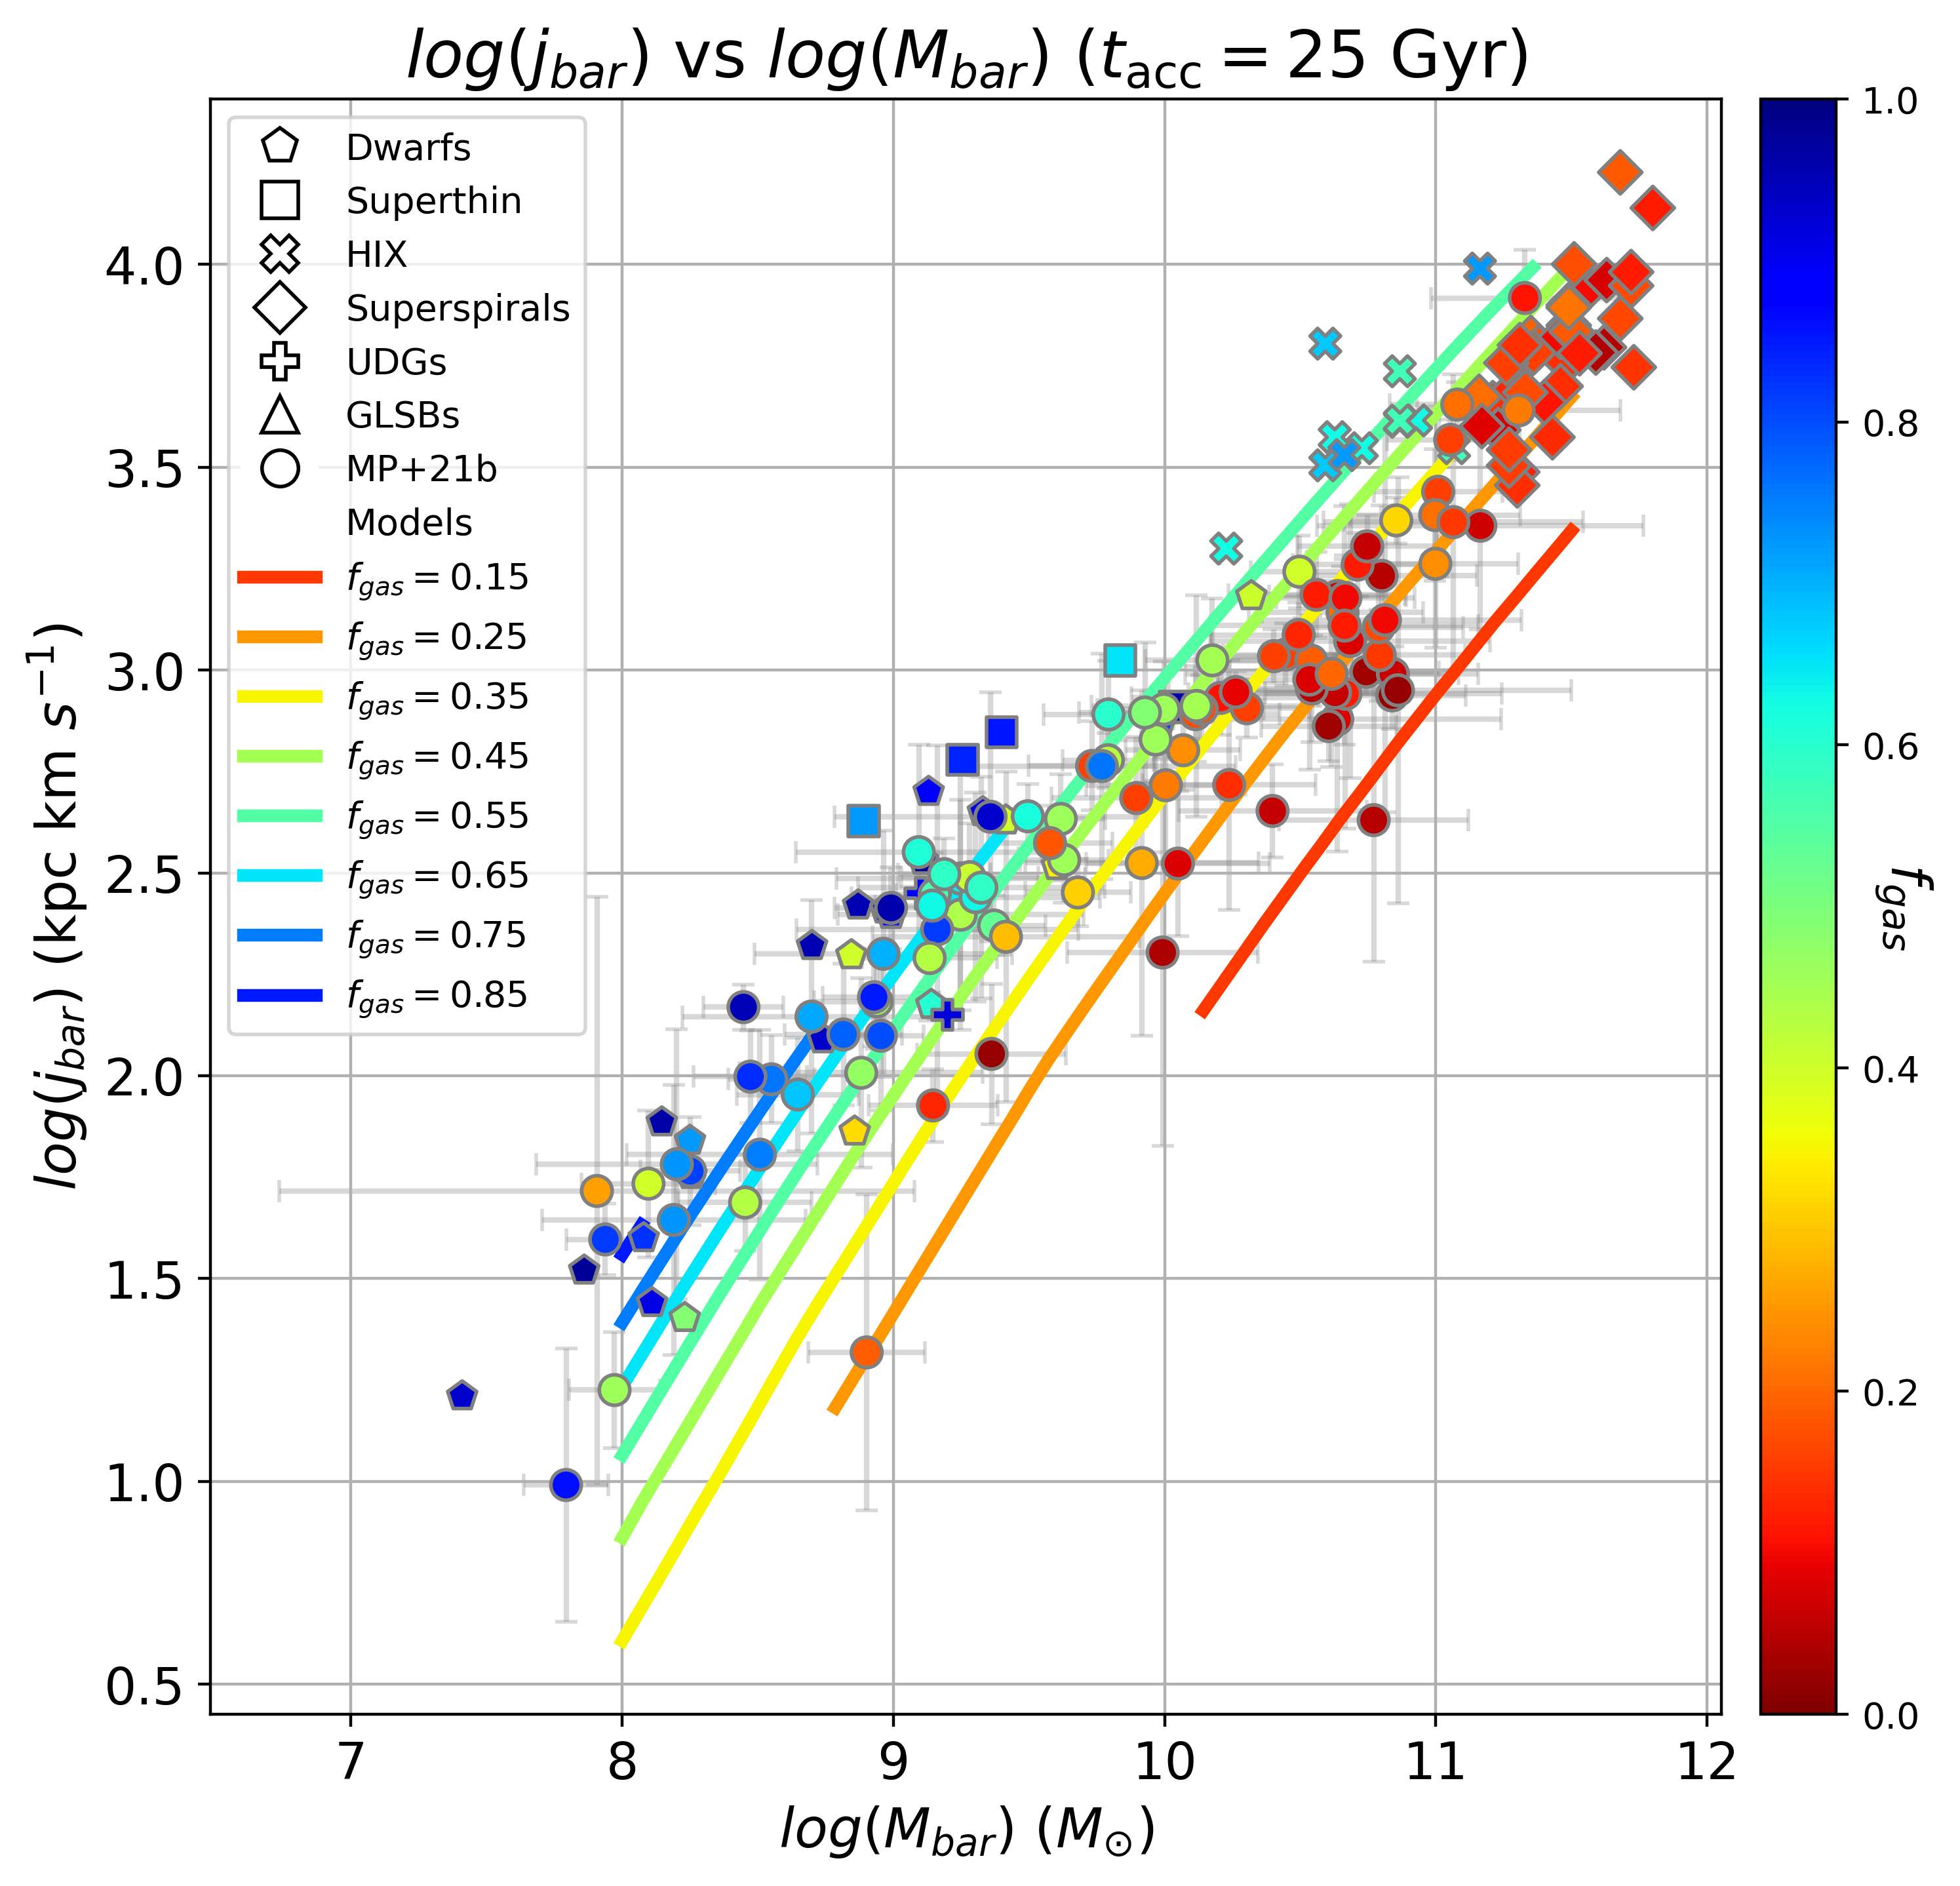

Execution time: 0.9637 seconds


In [ ]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 2, :].min(),f_gas_array_10_50_cutoff_ksl[i, 2, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 2, :], log_j_bar_array_10_50[i, 2, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$ ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).pdf')

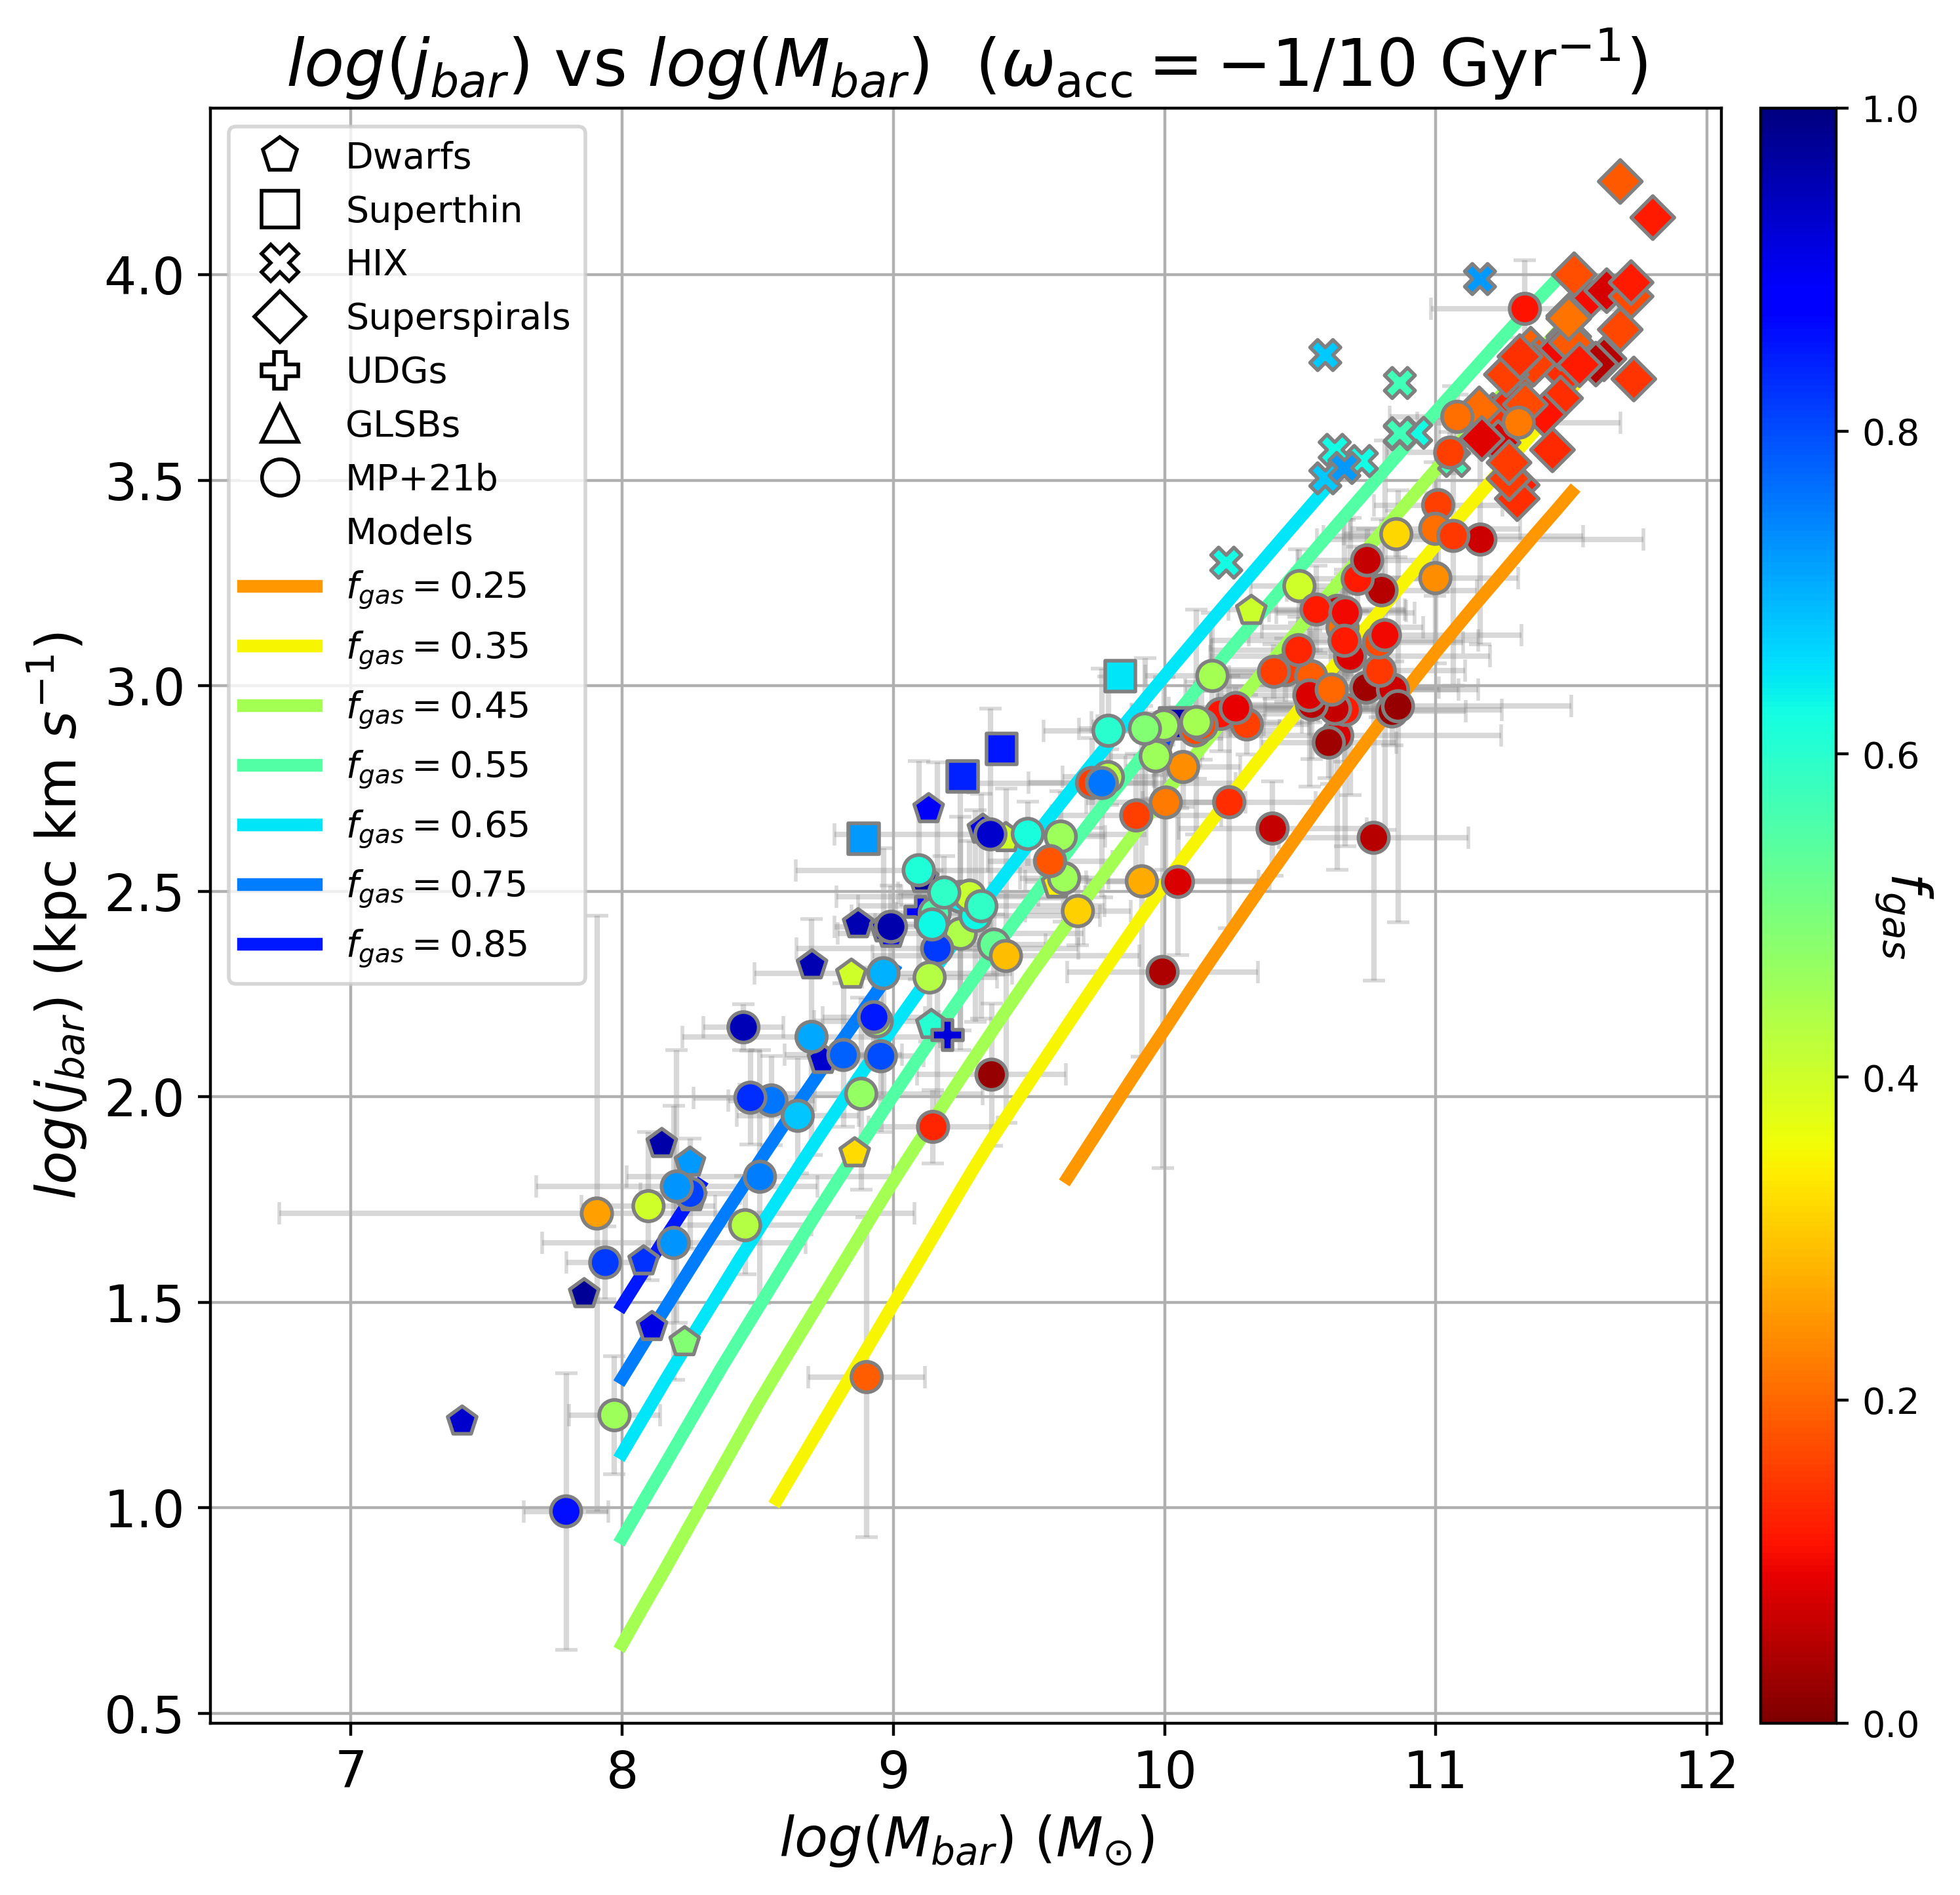

Execution time: 0.9518 seconds


In [ ]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 3, :].min(),f_gas_array_10_50_cutoff_ksl[i, 3, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 3, :], log_j_bar_array_10_50[i, 3, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($\omega_{\mathrm{acc}} = -1/10$ Gyr$^{-1}$)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).pdf')

## Save comparison profiles for IO vs NIO figure

In [29]:
# Compute and save two NIO profiles for the comparison figure:
# logM=10, a=2, b=2 → omega=2, t_acc=0.5 Gyr
# Two j_acc values: j_max and j_max/10

logM_comp = 10.0
a_comp, b_comp = 2.0, 2.0
M_bar_comp = 10.0**logM_comp

j_max_comp = j_maxer(M_bar_comp)
j_high = j_max_comp       # high j_acc
j_low = j_max_comp / 10.0  # low j_acc

print(f"logM = {logM_comp}, M_bar = {M_bar_comp:.2e}")
print(f"j_max = {j_max_comp:.2f} kpc km/s")
print(f"j_high = {j_high:.2f}, j_low = {j_low:.2f} kpc km/s")
print(f"omega = {omega_Mdep(logM_comp, a_comp, b_comp):.2f} Gyr^-1")

# Compute profiles
profile_high = compute_radial_profiles_nio(logM_comp, j_high, a_comp, b_comp)
profile_low  = compute_radial_profiles_nio(logM_comp, j_low,  a_comp, b_comp)

# Add C (normalization constant) to each profile for analytical M_dot plotting
omega_comp = float(omega_Mdep(logM_comp, a_comp, b_comp))
t_acc_comp = 1.0 / omega_comp
C_comp = float(C_def_jax(M_bar_comp, t_acc_comp))
print(f"t_acc = {t_acc_comp:.4f} Gyr, C = {C_comp:.4e} Msun/Gyr")

# Save
out_dir = '../outputs/model_radial_profiles/nio/'
os.makedirs(out_dir, exist_ok=True)

for label, prof, j_val in [('high_jacc', profile_high, j_high),
                            ('low_jacc',  profile_low,  j_low)]:
    prof['C'] = C_comp
    prof['j_acc_value'] = j_val
    prof['M_bar'] = M_bar_comp
    fname = os.path.join(out_dir, f'comparison_nio_{label}.npz')
    save_radial_profiles_nio(prof, fname)
    print(f"Saved {fname}")
    print(f"  f_gas(t0) = {prof['f_gas_t'][-1]:.4f}, j_bar(t0) = {prof['j_bar_t'][-1]:.2f} kpc km/s")

logM = 10.0, M_bar = 1.00e+10
j_max = 1122.02 kpc km/s
j_high = 1122.02, j_low = 112.20 kpc km/s
omega = 2.00 Gyr^-1
t_acc = 0.5000 Gyr, C = 2.0000e+10 Msun/Gyr
Saved ../outputs/model_radial_profiles/nio/comparison_nio_high_jacc.npz
  f_gas(t0) = 0.4706, j_bar(t0) = 1122.11 kpc km/s
Saved ../outputs/model_radial_profiles/nio/comparison_nio_low_jacc.npz
  f_gas(t0) = 0.0546, j_bar(t0) = 112.34 kpc km/s
Execution time: 0.0626 seconds
